## Quantum Test - MaxCUT K2000 v1

In [3]:
from pathlib import Path
import time
import math

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm import tqdm
except ImportError:
    tqdm = None

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [5]:
K2000_PATH = Path("WK2000_1.rud")

OUTPUT_DIR = Path("qefem_v1_k2000_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


K2000_INSTANCE = "K2000"

K2000_N_EXPECTED = 2000
K2000_M_EXPECTED = 1_999_000
K2000_BEST_KNOWN = 33337

DTYPE = torch.float32

K2000_TMAX = 1.16
K2000_TMIN = 6e-05

K2000_BETA_MIN = 1.0 / K2000_TMAX
K2000_BETA_MAX = 1.0 / K2000_TMIN


N_STEPS = 1000
REPLICAS = 128

SEED = 4
LOG_EVERY = 50

In [6]:
R_INIT = 1e-2
THETA_CENTER = math.pi / 2
THETA_NOISE = 1e-3
GAMMA_ZERO = 0.0
GAMMA_MAX = 1.0
GAMMA_MIN = 0.0
GAMMA_SCHEDULE_KIND = "linear"
ADAM_LR = 0.01
RMS_LR = 0.03
RMS_ALPHA = 0.56
RMS_MOMENTUM = 0.63
RMS_WEIGHT_DECAY = 0.013
RMS_EPS = 1e-8
RMS_CENTERED = False

In [5]:
# ----------------------------
# Saved vanilla baselines from vanilla_k2000.md
# Do NOT rerun vanilla in this notebook.
# ----------------------------
VANILLA_ADAM_CUT = 29906.0
VANILLA_ADAM_GAP = K2000_BEST_KNOWN - VANILLA_ADAM_CUT
VANILLA_ADAM_ACCURACY = 100.0 * VANILLA_ADAM_CUT / K2000_BEST_KNOWN
VANILLA_ADAM_RUNTIME = 4.196436166763306

VANILLA_RMSPROP_CUT = 32954.0
VANILLA_RMSPROP_GAP = K2000_BEST_KNOWN - VANILLA_RMSPROP_CUT
VANILLA_RMSPROP_ACCURACY = 100.0 * VANILLA_RMSPROP_CUT / K2000_BEST_KNOWN
VANILLA_RMSPROP_RUNTIME = 4.064090013504028

In [6]:
# ----------------------------
# Print setup
# ----------------------------
print("\nPaths:")
print("K2000_PATH:", K2000_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

print("\nExists?")
print("K2000 file:", K2000_PATH.exists())

print("\nK2000 constants:")
print("Instance:", K2000_INSTANCE)
print("Expected N:", K2000_N_EXPECTED)
print("Expected M:", K2000_M_EXPECTED)
print("Best-known cut:", K2000_BEST_KNOWN)

print("\nBeta schedule:")
print("TMAX:", K2000_TMAX)
print("TMIN:", K2000_TMIN)
print("beta_min:", K2000_BETA_MIN)
print("beta_max:", K2000_BETA_MAX)

print("\nQEFEM settings:")
print("N_STEPS:", N_STEPS)
print("REPLICAS:", REPLICAS)
print("SEED:", SEED)
print("LOG_EVERY:", LOG_EVERY)
print("R_INIT:", R_INIT)
print("THETA_CENTER:", THETA_CENTER)
print("THETA_NOISE:", THETA_NOISE)
print("GAMMA anneal:", GAMMA_MAX, "->", GAMMA_MIN)

print("\nOptimizer settings:")
print("Adam lr:", ADAM_LR)
print("RMSprop lr:", RMS_LR)
print("RMSprop alpha:", RMS_ALPHA)
print("RMSprop momentum:", RMS_MOMENTUM)
print("RMSprop weight_decay:", RMS_WEIGHT_DECAY)

print("\nSaved vanilla baselines:")
print(f"Vanilla Adam    : cut={VANILLA_ADAM_CUT:.0f}, gap={VANILLA_ADAM_GAP:.0f}, acc={VANILLA_ADAM_ACCURACY:.4f}%, time={VANILLA_ADAM_RUNTIME:.4f}s")
print(f"Vanilla RMSprop : cut={VANILLA_RMSPROP_CUT:.0f}, gap={VANILLA_RMSPROP_GAP:.0f}, acc={VANILLA_RMSPROP_ACCURACY:.4f}%, time={VANILLA_RMSPROP_RUNTIME:.4f}s")


Paths:
K2000_PATH: /Users/ronit/Desktop/QeFEM/main/maxcut_results/WK2000_1.rud
OUTPUT_DIR: /Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs

Exists?
K2000 file: True

K2000 constants:
Instance: K2000
Expected N: 2000
Expected M: 1999000
Best-known cut: 33337

Beta schedule:
TMAX: 1.16
TMIN: 6e-05
beta_min: 0.8620689655172414
beta_max: 16666.666666666668

QEFEM settings:
N_STEPS: 1000
REPLICAS: 128
SEED: 4
LOG_EVERY: 50
R_INIT: 0.01
THETA_CENTER: 1.5707963267948966
THETA_NOISE: 0.001
GAMMA anneal: 1.0 -> 0.0

Optimizer settings:
Adam lr: 0.01
RMSprop lr: 0.03
RMSprop alpha: 0.56
RMSprop momentum: 0.63
RMSprop weight_decay: 0.013

Saved vanilla baselines:
Vanilla Adam    : cut=29906, gap=3431, acc=89.7081%, time=4.1964s
Vanilla RMSprop : cut=32954, gap=383, acc=98.8511%, time=4.0641s


### Data inspection

In [7]:
if not K2000_PATH.exists():
    raise FileNotFoundError(
        f"Could not find K2000 file:\n{K2000_PATH.resolve()}\n\n"
        "Place WK2000_1.rud in the same directory as this notebook."
    )


# ----------------------------
# Read header and preview lines
# ----------------------------
NUM_PREVIEW_EDGES = 5

with K2000_PATH.open("r") as f:
    header_line = f.readline().strip()
    preview_edges = [f.readline().strip() for _ in range(NUM_PREVIEW_EDGES)]

print("Header line:")
print(header_line)

print(f"\nFirst {NUM_PREVIEW_EDGES} edge lines:")
for line in preview_edges:
    print(line)


# ----------------------------
# Parse header
# ----------------------------
header_parts = header_line.split()

if len(header_parts) != 2:
    raise ValueError(
        f"Bad header format: {header_line!r}. "
        "Expected exactly two integers: N M"
    )

N_header = int(header_parts[0])
M_header = int(header_parts[1])

print("\nParsed header:")
print("N_header =", N_header)
print("M_header =", M_header)


# ----------------------------
# Header sanity checks
# ----------------------------
assert N_header == K2000_N_EXPECTED, (
    f"Expected N={K2000_N_EXPECTED}, got N={N_header}"
)

assert M_header == K2000_M_EXPECTED, (
    f"Expected M={K2000_M_EXPECTED}, got M={M_header}"
)

Header line:
2000 1999000

First 5 edge lines:
1 2000 -1
1 1999 -1
1 1998 -1
1 1997 -1
1 1996 1

Parsed header:
N_header = 2000
M_header = 1999000


In [8]:
# ----------------------------
# Inspect preview edge format
# ----------------------------
print("\nPreview edge parsing:")

for idx, line in enumerate(preview_edges, start=1):
    parts = line.split()

    if len(parts) != 3:
        raise ValueError(
            f"Bad edge line in preview at preview line {idx}: {line!r}. "
            "Expected format: i j w"
        )

    i, j, w = map(int, parts)

    print(f"edge {idx}: i={i}, j={j}, w={w}")

    if not (1 <= i <= N_header):
        raise ValueError(f"Node i out of range in preview: i={i}")

    if not (1 <= j <= N_header):
        raise ValueError(f"Node j out of range in preview: j={j}")

    if w not in (-1, 1):
        raise ValueError(f"Unexpected K2000 weight in preview: w={w}")


print("\nPreview edge sanity passed.")


Preview edge parsing:
edge 1: i=1, j=2000, w=-1
edge 2: i=1, j=1999, w=-1
edge 3: i=1, j=1998, w=-1
edge 4: i=1, j=1997, w=-1
edge 5: i=1, j=1996, w=1

Preview edge sanity passed.


#### Load Data

In [9]:
start_load_time = time.time()

with K2000_PATH.open("r") as f:
    # ----------------------------
    # Header: N M
    # ----------------------------
    header = f.readline().strip().split()

    if len(header) != 2:
        raise ValueError(
            f"Bad header format: {header}. Expected exactly: N M"
        )

    N = int(header[0])
    M = int(header[1])

    print("Parsed header:")
    print("N =", N)
    print("M =", M)

    assert N == K2000_N_EXPECTED, (
        f"Expected N={K2000_N_EXPECTED}, got N={N}"
    )

    assert M == K2000_M_EXPECTED, (
        f"Expected M={K2000_M_EXPECTED}, got M={M}"
    )

    # ----------------------------
    # Allocate dense adjacency on CPU first
    # ----------------------------
    W_cpu = torch.zeros(
        (N, N),
        dtype=DTYPE,
        device="cpu",
    )

    # ----------------------------
    # Counters
    # ----------------------------
    m_loaded = 0
    positive_edges = 0
    negative_edges = 0
    zero_edges = 0
    self_edges = 0

    # ----------------------------
    # Read edges
    # ----------------------------
    for line_no, line in enumerate(f, start=2):
        line = line.strip()

        if not line:
            continue

        parts = line.split()

        if len(parts) != 3:
            raise ValueError(
                f"Bad edge line {line_no}: {line!r}. "
                "Expected format: i j w"
            )

        i, j, w = map(int, parts)

        # Convert 1-indexed file labels to 0-indexed tensor indices
        i -= 1
        j -= 1

        if not (0 <= i < N):
            raise IndexError(f"Line {line_no}: i out of range: {i}")

        if not (0 <= j < N):
            raise IndexError(f"Line {line_no}: j out of range: {j}")

        if w not in (-1, 1):
            raise ValueError(
                f"Line {line_no}: unexpected weight {w}. "
                "Expected -1 or +1."
            )

        if i == j:
            self_edges += 1

        if w == 1:
            positive_edges += 1
        elif w == -1:
            negative_edges += 1
        else:
            zero_edges += 1

        # Symmetric undirected adjacency
        W_cpu[i, j] = float(w)
        W_cpu[j, i] = float(w)

        m_loaded += 1

# ----------------------------
# Move W to target device
# ----------------------------
W = W_cpu.to(device=device, dtype=DTYPE)

if W.device.type == "mps":
    torch.mps.synchronize()

load_time_sec = time.time() - start_load_time

Parsed header:
N = 2000
M = 1999000


In [11]:
print("Time taken to load weight matrix :", load_time_sec,"s")

Time taken to load weight matrix : 14.339623928070068 s


In [12]:
# ----------------------------
# Sanity checks
# ----------------------------
diag_zero = bool(torch.allclose(
    torch.diag(W),
    torch.zeros(N, dtype=DTYPE, device=W.device),
))

symmetric = bool(torch.allclose(W, W.T))

nonzero_directed_entries = int(torch.count_nonzero(W).detach().cpu().item())
expected_directed_entries = N * (N - 1)

W_sum = float(W.sum().detach().cpu().item())
W_min = float(W.min().detach().cpu().item())
W_max = float(W.max().detach().cpu().item())

assert m_loaded == K2000_M_EXPECTED, (
    f"Expected {K2000_M_EXPECTED} loaded edges, got {m_loaded}"
)

assert positive_edges + negative_edges == K2000_M_EXPECTED, (
    "positive_edges + negative_edges does not match expected edge count."
)

assert zero_edges == 0, (
    f"Expected zero_edges=0, got {zero_edges}"
)

assert self_edges == 0, (
    f"Expected no self edges, got {self_edges}"
)

assert symmetric is True, "W is not symmetric."

assert diag_zero is True, "W diagonal is not zero."

assert nonzero_directed_entries == expected_directed_entries, (
    f"Expected {expected_directed_entries} directed nonzero entries, "
    f"got {nonzero_directed_entries}"
)

assert W_min == -1.0, (
    f"Expected W_min=-1.0, got {W_min}"
)

assert W_max == 1.0, (
    f"Expected W_max=1.0, got {W_max}"
)

In [13]:
# ----------------------------
# Store info dictionary for later cells
# ----------------------------
k2000_info = {
    "path": str(K2000_PATH),
    "n": N,
    "m_header": M,
    "m_loaded": m_loaded,
    "positive_edges": positive_edges,
    "negative_edges": negative_edges,
    "zero_edges": zero_edges,
    "self_edges": self_edges,
    "nonzero_directed_entries": nonzero_directed_entries,
    "expected_directed_entries": expected_directed_entries,
    "symmetric": symmetric,
    "diag_zero": diag_zero,
    "W_sum": W_sum,
    "W_min": W_min,
    "W_max": W_max,
    "device": str(W.device),
    "dtype": str(W.dtype),
    "load_time_sec": load_time_sec,
}

positive_fraction = positive_edges / m_loaded
negative_fraction = negative_edges / m_loaded

In [14]:
# ----------------------------
# Print metadata
# ----------------------------
print("\nLoaded K2000 successfully.")
print("-" * 80)
print("W.shape:", tuple(W.shape))
print("W dtype:", W.dtype)
print("W device:", W.device)
print("Load time sec:", load_time_sec)

print("\nGraph stats:")
print("Loaded undirected edges:", m_loaded)
print("Positive edges:", positive_edges, f"({100.0 * positive_fraction:.4f}%)")
print("Negative edges:", negative_edges, f"({100.0 * negative_fraction:.4f}%)")
print("Self edges:", self_edges)
print("Directed nonzero entries:", nonzero_directed_entries)
print("Expected directed entries:", expected_directed_entries)

print("\nMatrix stats:")
print("W_sum:", W_sum)
print("W_min:", W_min)
print("W_max:", W_max)
print("Symmetric:", symmetric)
print("Diagonal zero:", diag_zero)

print("\nBest-known K2000 cut:", K2000_BEST_KNOWN)
print("-" * 80)


Loaded K2000 successfully.
--------------------------------------------------------------------------------
W.shape: (2000, 2000)
W dtype: torch.float32
W device: mps:0
Load time sec: 14.339623928070068

Graph stats:
Loaded undirected edges: 1999000
Positive edges: 998980 (49.9740%)
Negative edges: 1000020 (50.0260%)
Self edges: 0
Directed nonzero entries: 3998000
Expected directed entries: 3998000

Matrix stats:
W_sum: -2080.0
W_min: -1.0
W_max: 1.0
Symmetric: True
Diagonal zero: True

Best-known K2000 cut: 33337
--------------------------------------------------------------------------------


### Build Discrete Cut function

In [15]:
def discrete_cut(W, spins):

    single_input = False

    if spins.dim() == 1:
        spins = spins.unsqueeze(0)
        single_input = True

    spins = spins.to(device=W.device, dtype=W.dtype)

    quad = torch.einsum(
        "ri,ij,rj->r",
        spins,
        W,
        spins,
    )

    cut = 0.25 * (W.sum() - quad)

    if single_input:
        return cut.squeeze(0)

    return cut

### Bloch parameterization

In [16]:
def raw_R_from_init_value(R_init, device=device, dtype=DTYPE):
    """
    Convert desired initial R into raw_R such that sigmoid(raw_R) = R_init.
    """

    if not (0.0 < R_init < 1.0):
        raise ValueError("R_init must be strictly between 0 and 1.")

    R_init_tensor = torch.tensor(
        R_init,
        device=device,
        dtype=dtype,
    )

    return torch.logit(R_init_tensor)


def bloch_from_raw(raw_R, theta):
    """
    Convert trainable raw_R and theta into Bloch variables.
    """

    R = torch.sigmoid(raw_R)

    rx = R * torch.sin(theta)
    rz = R * torch.cos(theta)

    return R, rx, rz

### Quantum Entropy

In [17]:
def quantum_entropy_from_R(R, eps=1e-12):

    single_input = False

    if R.dim() == 1:
        R = R.unsqueeze(0)
        single_input = True

    R = R.clamp(eps, 1.0 - eps)

    lambda_plus = 0.5 * (1.0 + R)
    lambda_minus = 0.5 * (1.0 - R)

    entropy_per_spin = -(
        lambda_plus * torch.log(lambda_plus)
        + lambda_minus * torch.log(lambda_minus)
    )

    entropy = entropy_per_spin.sum(dim=1)

    if single_input:
        return entropy.squeeze(0)

    return entropy

### Expected cut

In [18]:
def quantum_expected_cut(W, rz):

    single_input = False

    if rz.dim() == 1:
        rz = rz.unsqueeze(0)
        single_input = True

    rz = rz.to(device=W.device, dtype=W.dtype)

    quad = torch.einsum(
        "ri,ij,rj->r",
        rz,
        W,
        rz,
    )

    expected_cut = 0.25 * (W.sum() - quad)

    if single_input:
        return expected_cut.squeeze(0)

    return expected_cut

### Transverse driver

In [19]:
def transverse_driver_energy(rx, gamma):
    """
    Transverse-field driver energy.

    Args:
        rx    : [N] or [REPLICAS, N]
        gamma : scalar float or tensor

    Returns:
        driver energy scalar if [N], else [REPLICAS]
    """

    single_input = False

    if rx.dim() == 1:
        rx = rx.unsqueeze(0)
        single_input = True

    gamma = torch.as_tensor(
        gamma,
        device=rx.device,
        dtype=rx.dtype,
    )

    driver_energy = -gamma * rx.sum(dim=1)

    if single_input:
        return driver_energy.squeeze(0)

    return driver_energy

### Full QeFEM energy

In [20]:
def qefem_free_energy_maxcut(W, raw_R, theta, beta, gamma):

    beta = torch.as_tensor(
        beta,
        device=W.device,
        dtype=W.dtype,
    )

    gamma = torch.as_tensor(
        gamma,
        device=W.device,
        dtype=W.dtype,
    )

    R, rx, rz = bloch_from_raw(
        raw_R,
        theta,
    )

    expected_cut = quantum_expected_cut(
        W,
        rz,
    )

    entropy = quantum_entropy_from_R(
        R,
    )

    driver_energy = transverse_driver_energy(
        rx,
        gamma,
    )

    internal_energy_cut = -expected_cut

    F = internal_energy_cut + driver_energy - entropy / beta

    aux = {
        "R": R,
        "rx": rx,
        "rz": rz,

        "expected_cut": expected_cut,
        "entropy": entropy,
        "driver_energy": driver_energy,
        "internal_energy_cut": internal_energy_cut,

        "free_energy": F,
        "beta": beta,
        "gamma": gamma,
    }

    return F, aux

### Annealing Schedules : $\beta$ & $\Gamma$

In [25]:
# ----------------------------
# Temperature and beta schedule
# ----------------------------
T_schedule = torch.linspace(
    K2000_TMAX,
    K2000_TMIN,
    N_STEPS,
    device=W.device,
    dtype=W.dtype,
)

beta_schedule = 1.0 / T_schedule


# ----------------------------
# Gamma schedules
# ----------------------------
gamma_zero_schedule = torch.zeros(
    N_STEPS,
    device=W.device,
    dtype=W.dtype,
)

gamma_anneal_schedule = torch.linspace(
    GAMMA_MAX,
    GAMMA_MIN,
    N_STEPS,
    device=W.device,
    dtype=W.dtype,
)


# ----------------------------
# Print previews
# ----------------------------
print("Temperature schedule:")
print("shape :", T_schedule.shape)
print("first :", float(T_schedule[0].detach().cpu()))
print("middle:", float(T_schedule[len(T_schedule)//2].detach().cpu()))
print("last  :", float(T_schedule[-1].detach().cpu()))

print("\nBeta schedule:")
print("shape :", beta_schedule.shape)
print("first :", float(beta_schedule[0].detach().cpu()))
print("middle:", float(beta_schedule[len(beta_schedule)//2].detach().cpu()))
print("last  :", float(beta_schedule[-1].detach().cpu()))

print("\nGamma zero schedule:")
print("shape :", gamma_zero_schedule.shape)
print("first :", float(gamma_zero_schedule[0].detach().cpu()))
print("middle:", float(gamma_zero_schedule[len(gamma_zero_schedule)//2].detach().cpu()))
print("last  :", float(gamma_zero_schedule[-1].detach().cpu()))

print("\nGamma anneal schedule:")
print("shape :", gamma_anneal_schedule.shape)
print("first :", float(gamma_anneal_schedule[0].detach().cpu()))
print("middle:", float(gamma_anneal_schedule[len(gamma_anneal_schedule)//2].detach().cpu()))
print("last  :", float(gamma_anneal_schedule[-1].detach().cpu()))


# ----------------------------
# Assertions
# ----------------------------
assert T_schedule.shape == torch.Size([N_STEPS])
assert beta_schedule.shape == torch.Size([N_STEPS])
assert gamma_zero_schedule.shape == torch.Size([N_STEPS])
assert gamma_anneal_schedule.shape == torch.Size([N_STEPS])

assert torch.all(T_schedule > 0), (
    "Temperature must stay positive."
)

assert torch.all(beta_schedule > 0), (
    "Beta must stay positive."
)

assert T_schedule[0] > T_schedule[-1], (
    "Temperature should decrease."
)

assert beta_schedule[0] < beta_schedule[-1], (
    "Beta should increase."
)

assert abs(float(beta_schedule[0].detach().cpu()) - K2000_BETA_MIN) < 1e-5, (
    "beta_schedule first value does not match K2000_BETA_MIN."
)

assert abs(float(beta_schedule[-1].detach().cpu()) - K2000_BETA_MAX) < 5e-2, (
    "beta_schedule last value does not match K2000_BETA_MAX closely enough."
)

assert torch.allclose(
    gamma_zero_schedule,
    torch.zeros_like(gamma_zero_schedule),
), (
    "gamma_zero_schedule should be all zeros."
)

assert abs(float(gamma_anneal_schedule[0].detach().cpu()) - GAMMA_MAX) < 1e-6, (
    "gamma_anneal_schedule should start at GAMMA_MAX."
)

assert abs(float(gamma_anneal_schedule[-1].detach().cpu()) - GAMMA_MIN) < 1e-6, (
    "gamma_anneal_schedule should end at GAMMA_MIN."
)

Temperature schedule:
shape : torch.Size([1000])
first : 1.159999966621399
middle: 0.5794494152069092
last  : 5.999999848427251e-05

Beta schedule:
shape : torch.Size([1000])
first : 0.8620690107345581
middle: 1.725776195526123
last  : 16666.66796875

Gamma zero schedule:
shape : torch.Size([1000])
first : 0.0
middle: 0.0
last  : 0.0

Gamma anneal schedule:
shape : torch.Size([1000])
first : 1.0
middle: 0.49949949979782104
last  : 0.0


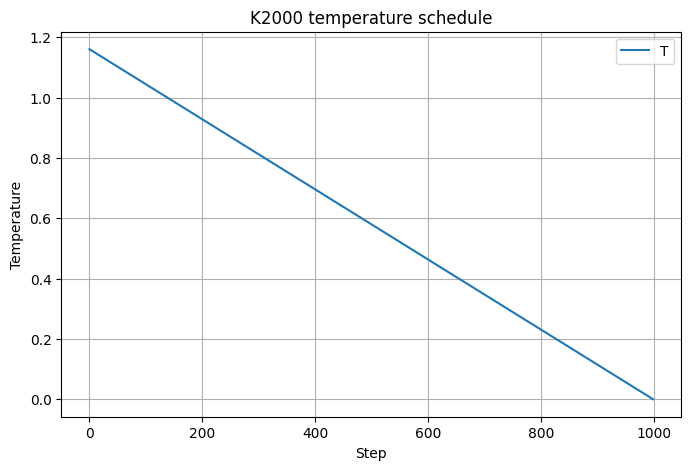

In [26]:
# ----------------------------
# Plot schedules
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(torch.arange(N_STEPS).detach().cpu(), T_schedule.detach().cpu(), label="T")
plt.xlabel("Step")
plt.ylabel("Temperature")
plt.title("K2000 temperature schedule")
plt.legend()
plt.grid(True)
plt.show()

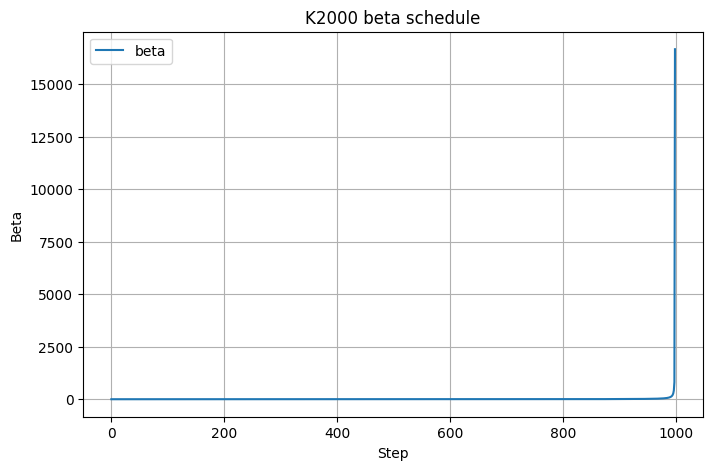

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(torch.arange(N_STEPS).detach().cpu(), beta_schedule.detach().cpu(), label="beta")
plt.xlabel("Step")
plt.ylabel("Beta")
plt.title("K2000 beta schedule")
plt.legend()
plt.grid(True)
plt.show()

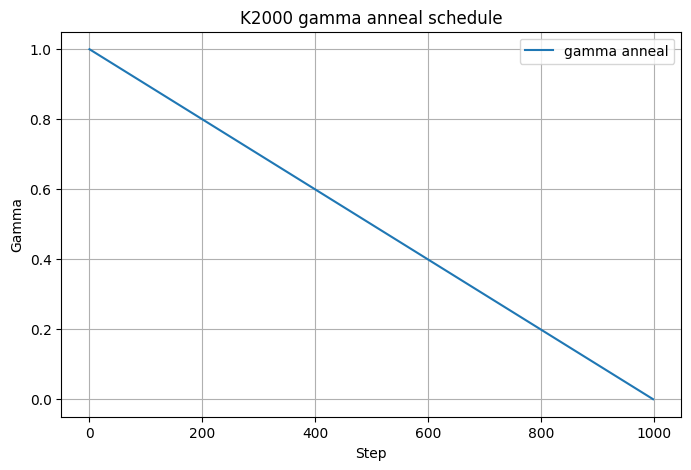

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(torch.arange(N_STEPS).detach().cpu(), gamma_anneal_schedule.detach().cpu(), label="gamma anneal")
plt.xlabel("Step")
plt.ylabel("Gamma")
plt.title("K2000 gamma anneal schedule")
plt.legend()
plt.grid(True)
plt.show()

### Initialize

In [29]:
torch.manual_seed(SEED)

raw_R_init_value = raw_R_from_init_value(
    R_INIT,
    device=W.device,
    dtype=W.dtype,
)

raw_R_zero = raw_R_init_value + 1e-3 * torch.randn(
    REPLICAS,
    N,
    device=W.device,
    dtype=W.dtype,
)

theta_zero = THETA_CENTER + THETA_NOISE * torch.randn(
    REPLICAS,
    N,
    device=W.device,
    dtype=W.dtype,
)

raw_R_zero.requires_grad_(True)
theta_zero.requires_grad_(True)

tensor([[1.5702, 1.5692, 1.5713,  ..., 1.5713, 1.5723, 1.5698],
        [1.5703, 1.5697, 1.5707,  ..., 1.5699, 1.5694, 1.5701],
        [1.5694, 1.5700, 1.5695,  ..., 1.5712, 1.5694, 1.5716],
        ...,
        [1.5693, 1.5701, 1.5709,  ..., 1.5706, 1.5710, 1.5701],
        [1.5720, 1.5701, 1.5702,  ..., 1.5720, 1.5712, 1.5714],
        [1.5702, 1.5704, 1.5701,  ..., 1.5702, 1.5709, 1.5697]],
       device='mps:0', requires_grad=True)

In [30]:
optimizer_zero = torch.optim.Adam(
    [raw_R_zero, theta_zero],
    lr=ADAM_LR,
)

In [31]:
# ----------------------------
# Initial Bloch diagnostics
# ----------------------------
with torch.no_grad():
    R_zero_init, rx_zero_init, rz_zero_init = bloch_from_raw(
        raw_R_zero,
        theta_zero,
    )

    initial_expected_cut_zero = quantum_expected_cut(
        W,
        rz_zero_init,
    )

    initial_entropy_zero = quantum_entropy_from_R(
        R_zero_init,
    )

    initial_driver_zero = transverse_driver_energy(
        rx_zero_init,
        gamma=0.0,
    )

    initial_F_zero, initial_aux_zero = qefem_free_energy_maxcut(
        W=W,
        raw_R=raw_R_zero,
        theta=theta_zero,
        beta=beta_schedule[0],
        gamma=gamma_zero_schedule[0],
    )

    initial_spins_zero = torch.where(
        rz_zero_init >= 0,
        torch.ones_like(rz_zero_init),
        -torch.ones_like(rz_zero_init),
    )

    initial_hard_cuts_zero = discrete_cut(
        W,
        initial_spins_zero,
    )

In [33]:
# ----------------------------
# Print initialization diagnostics
# ----------------------------
print("Initialized QEFEM variables for gamma=0 Adam sanity run.")
print("-" * 80)

print("Shapes:")
print("raw_R_zero:", raw_R_zero.shape)
print("theta_zero:", theta_zero.shape)

print("\nTrainability:")
print("raw_R_zero requires_grad:", raw_R_zero.requires_grad)
print("theta_zero requires_grad:", theta_zero.requires_grad)

Initialized QEFEM variables for gamma=0 Adam sanity run.
--------------------------------------------------------------------------------
Shapes:
raw_R_zero: torch.Size([128, 2000])
theta_zero: torch.Size([128, 2000])

Trainability:
raw_R_zero requires_grad: True
theta_zero requires_grad: True


In [34]:
print("Optimizer:")
print(optimizer_zero)

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [35]:
print("Initial R stats:")
print("R mean:", float(R_zero_init.mean().detach().cpu()))
print("R min :", float(R_zero_init.min().detach().cpu()))
print("R max :", float(R_zero_init.max().detach().cpu()))

print("\nInitial component stats:")
print("rx mean     :", float(rx_zero_init.mean().detach().cpu()))
print("rx abs mean :", float(rx_zero_init.abs().mean().detach().cpu()))
print("rz mean     :", float(rz_zero_init.mean().detach().cpu()))
print("rz abs mean :", float(rz_zero_init.abs().mean().detach().cpu()))

print("\nInitial objective stats:")
print("Expected cut mean :", float(initial_expected_cut_zero.mean().detach().cpu()))
print("Expected cut max  :", float(initial_expected_cut_zero.max().detach().cpu()))
print("Hard cut mean     :", float(initial_hard_cuts_zero.mean().detach().cpu()))
print("Hard cut max      :", float(initial_hard_cuts_zero.max().detach().cpu()))
print("Entropy mean      :", float(initial_entropy_zero.mean().detach().cpu()))
print("Driver mean       :", float(initial_driver_zero.mean().detach().cpu()))
print("Free energy mean  :", float(initial_F_zero.mean().detach().cpu()))

print("\nReferences:")
print("Best-known cut       :", K2000_BEST_KNOWN)
print("Vanilla Adam cut     :", VANILLA_ADAM_CUT)
print("Vanilla RMSprop cut  :", VANILLA_RMSPROP_CUT)

Initial R stats:
R mean: 0.009999998845160007
R min : 0.009952389635145664
R max : 0.010043242946267128

Initial component stats:
rx mean     : 0.00999999325722456
rx abs mean : 0.00999999325722456
rz mean     : -4.878411452580167e-09
rz abs mean : 7.979097063071094e-06

Initial objective stats:
Expected cut mean : -520.0
Expected cut max  : -520.0
Hard cut mean     : -600.296875
Hard cut max      : 932.0
Entropy mean      : 1386.1943359375
Driver mean       : 0.0
Free energy mean  : -1087.9853515625

References:
Best-known cut       : 33337
Vanilla Adam cut     : 29906.0
Vanilla RMSprop cut  : 32954.0


In [37]:
# ----------------------------
# Assertions
# ----------------------------
assert raw_R_zero.shape == torch.Size([REPLICAS, N])
assert theta_zero.shape == torch.Size([REPLICAS, N])

assert raw_R_zero.requires_grad is True
assert theta_zero.requires_grad is True

assert torch.all(R_zero_init > 0), (
    "R must be positive."
)

assert torch.all(R_zero_init < 1), (
    "R must be less than 1."
)

assert rx_zero_init.abs().mean() > rz_zero_init.abs().mean(), (
    "Initial state should be mostly transverse: |rx| should exceed |rz|."
)

assert torch.allclose(
    initial_driver_zero,
    torch.zeros_like(initial_driver_zero),
    atol=1e-6,
    rtol=1e-6,
), (
    "Gamma=0 initialization should have zero driver energy."
)

assert initial_F_zero.shape == torch.Size([REPLICAS]), (
    "Initial free energy should return one value per replica."
)

### $\Gamma = 0$ ---> Vanilla Sanity run

In [38]:
history_zero = []

best_cut_zero = -float("inf")
best_step_zero = None
best_replica_zero = None
best_spins_zero = None

start_time_zero = time.time()

print("=" * 80)
print("Starting K2000 QEFEM gamma=0 Adam sanity run")
print("=" * 80)
print("Instance:", K2000_INSTANCE)
print("N:", N)
print("REPLICAS:", REPLICAS)
print("N_STEPS:", N_STEPS)
print("Optimizer: Adam")
print("LR:", ADAM_LR)
print("Seed:", SEED)
print("Beta:", float(beta_schedule[0].detach().cpu()), "->", float(beta_schedule[-1].detach().cpu()))
print("Gamma: 0.0 fixed")
print("Best-known cut:", K2000_BEST_KNOWN)
print("Vanilla Adam cut:", VANILLA_ADAM_CUT)
print("Vanilla RMSprop cut:", VANILLA_RMSPROP_CUT)
print("-" * 80)

if W.device.type == "mps":
    torch.mps.synchronize()


# ============================================================
# Optimization loop
# ============================================================

for step in range(N_STEPS):
    beta_t = beta_schedule[step]
    gamma_t = gamma_zero_schedule[step]

    optimizer_zero.zero_grad()

    F_zero, aux_zero = qefem_free_energy_maxcut(
        W=W,
        raw_R=raw_R_zero,
        theta=theta_zero,
        beta=beta_t,
        gamma=gamma_t,
    )

    if not torch.isfinite(F_zero).all():
        raise FloatingPointError(
            f"Non-finite F_zero at step {step}. The free energy goblin has arrived."
        )

    loss_zero = F_zero.mean()

    if not torch.isfinite(loss_zero):
        raise FloatingPointError(
            f"Non-finite loss_zero at step {step}."
        )

    loss_zero.backward()

    if raw_R_zero.grad is None:
        raise RuntimeError(f"raw_R_zero.grad is None at step {step}")

    if theta_zero.grad is None:
        raise RuntimeError(f"theta_zero.grad is None at step {step}")

    if not torch.isfinite(raw_R_zero.grad).all():
        raise FloatingPointError(f"Non-finite raw_R_zero.grad at step {step}")

    if not torch.isfinite(theta_zero.grad).all():
        raise FloatingPointError(f"Non-finite theta_zero.grad at step {step}")

    grad_norm_raw_R = raw_R_zero.grad.detach().norm().item()
    grad_norm_theta = theta_zero.grad.detach().norm().item()

    optimizer_zero.step()

    if not torch.isfinite(raw_R_zero).all():
        raise FloatingPointError(f"Non-finite raw_R_zero after optimizer step {step}")

    if not torch.isfinite(theta_zero).all():
        raise FloatingPointError(f"Non-finite theta_zero after optimizer step {step}")


    # ----------------------------
    # Logging + hard readout
    # ----------------------------
    should_log = (
        step == 0
        or step == N_STEPS - 1
        or (step + 1) % LOG_EVERY == 0
    )

    if should_log:
        if W.device.type == "mps":
            torch.mps.synchronize()

        elapsed = time.time() - start_time_zero

        with torch.no_grad():
            R_now, rx_now, rz_now = bloch_from_raw(
                raw_R_zero,
                theta_zero,
            )

            spins_now = torch.where(
                rz_now >= 0,
                torch.ones_like(rz_now),
                -torch.ones_like(rz_now),
            )

            hard_cuts_now = discrete_cut(
                W,
                spins_now,
            )

            step_best_cut_tensor, step_best_replica_tensor = torch.max(
                hard_cuts_now,
                dim=0,
            )

            step_best_cut = float(step_best_cut_tensor.detach().cpu())
            step_best_replica = int(step_best_replica_tensor.detach().cpu())

            if step_best_cut > best_cut_zero:
                best_cut_zero = step_best_cut
                best_step_zero = step + 1
                best_replica_zero = step_best_replica
                best_spins_zero = spins_now[step_best_replica].detach().cpu().clone()

            row = {
                "step": step + 1,
                "beta": float(beta_t.detach().cpu()),
                "gamma": float(gamma_t.detach().cpu()),

                "loss_mean": float(loss_zero.detach().cpu()),
                "free_energy_mean": float(F_zero.mean().detach().cpu()),
                "free_energy_min": float(F_zero.min().detach().cpu()),

                "expected_cut_mean": float(aux_zero["expected_cut"].mean().detach().cpu()),
                "expected_cut_max": float(aux_zero["expected_cut"].max().detach().cpu()),

                "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                "hard_cut_max": step_best_cut,
                "best_cut_so_far": best_cut_zero,
                "gap_so_far": float(K2000_BEST_KNOWN - best_cut_zero),
                "accuracy_so_far_percent": float(100.0 * best_cut_zero / K2000_BEST_KNOWN),

                "entropy_mean": float(aux_zero["entropy"].mean().detach().cpu()),
                "driver_energy_mean": float(aux_zero["driver_energy"].mean().detach().cpu()),

                "R_mean": float(R_now.mean().detach().cpu()),
                "R_min": float(R_now.min().detach().cpu()),
                "R_max": float(R_now.max().detach().cpu()),

                "rx_mean": float(rx_now.mean().detach().cpu()),
                "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),

                "rz_mean": float(rz_now.mean().detach().cpu()),
                "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),

                "grad_norm_raw_R": grad_norm_raw_R,
                "grad_norm_theta": grad_norm_theta,

                "best_replica_current": step_best_replica,
                "best_replica_so_far": best_replica_zero,

                "elapsed_sec": elapsed,
            }

            history_zero.append(row)

            print(
                f"step {step + 1:5d}/{N_STEPS} | "
                f"beta={row['beta']:10.4f} | "
                f"F={row['free_energy_mean']:12.4f} | "
                f"Ecut_max={row['expected_cut_max']:10.1f} | "
                f"Hcut_max={row['hard_cut_max']:10.1f} | "
                f"best={row['best_cut_so_far']:10.1f} | "
                f"acc={row['accuracy_so_far_percent']:8.4f}% | "
                f"S={row['entropy_mean']:9.2f} | "
                f"|rx|={row['rx_abs_mean']:.4f} | "
                f"|rz|={row['rz_abs_mean']:.4f} | "
                f"time={elapsed:8.2f}s"
            )

Starting K2000 QEFEM gamma=0 Adam sanity run
Instance: K2000
N: 2000
REPLICAS: 128
N_STEPS: 1000
Optimizer: Adam
LR: 0.01
Seed: 4
Beta: 0.8620690107345581 -> 16666.66796875
Gamma: 0.0 fixed
Best-known cut: 33337
Vanilla Adam cut: 29906.0
Vanilla RMSprop cut: 32954.0
--------------------------------------------------------------------------------
step     1/1000 | beta=    0.8621 | F=  -1087.9854 | Ecut_max=    -520.0 | Hcut_max=    3998.0 | best=    3998.0 | acc= 11.9927% | S=  1386.19 | |rx|=0.0099 | |rz|=0.0000 | time=    0.05s
step    50/1000 | beta=    0.9065 | F=  -1009.9478 | Ecut_max=    -519.2 | Hcut_max=   28321.0 | best=   28321.0 | acc= 84.9537% | S=  1386.21 | |rx|=0.0080 | |rz|=0.0050 | time=    0.49s
step   100/1000 | beta=    0.9569 | F=   -945.9689 | Ecut_max=    -501.5 | Hcut_max=   28792.0 | best=   28792.0 | acc= 86.3665% | S=  1385.74 | |rx|=0.0040 | |rz|=0.0229 | time=    0.88s
step   150/1000 | beta=    1.0132 | F=  -1006.4848 | Ecut_max=    -350.0 | Hcut_max=   2

In [39]:
if W.device.type == "mps":
    torch.mps.synchronize()

runtime_zero = time.time() - start_time_zero

history_zero_df = pd.DataFrame(history_zero)

gap_zero = K2000_BEST_KNOWN - best_cut_zero
accuracy_zero = 100.0 * best_cut_zero / K2000_BEST_KNOWN

In [40]:
# ----------------------------
# Final print
# ----------------------------
print("\n" + "=" * 80)
print("K2000 QEFEM gamma=0 Adam sanity run complete")
print("=" * 80)
print("Best cut:", best_cut_zero)
print("Best-known:", K2000_BEST_KNOWN)
print("Gap:", gap_zero)
print("Accuracy %:", accuracy_zero)
print("Best step:", best_step_zero)
print("Best replica:", best_replica_zero)
print("Runtime seconds:", runtime_zero)

print("\nBaselines:")
print("Vanilla Adam cut:", VANILLA_ADAM_CUT)
print("Vanilla Adam gap:", VANILLA_ADAM_GAP)
print("Vanilla Adam accuracy %:", VANILLA_ADAM_ACCURACY)

print("\nVanilla RMSprop cut:", VANILLA_RMSPROP_CUT)
print("Vanilla RMSprop gap:", VANILLA_RMSPROP_GAP)
print("Vanilla RMSprop accuracy %:", VANILLA_RMSPROP_ACCURACY)

print("\nDelta vs vanilla Adam:")
print("QEFEM gamma=0 cut - vanilla Adam cut:", best_cut_zero - VANILLA_ADAM_CUT)
print("QEFEM gamma=0 accuracy - vanilla Adam accuracy:", accuracy_zero - VANILLA_ADAM_ACCURACY)

print("\nDelta vs vanilla RMSprop:")
print("QEFEM gamma=0 cut - vanilla RMSprop cut:", best_cut_zero - VANILLA_RMSPROP_CUT)
print("QEFEM gamma=0 accuracy - vanilla RMSprop accuracy:", accuracy_zero - VANILLA_RMSPROP_ACCURACY)


K2000 QEFEM gamma=0 Adam sanity run complete
Best cut: 30657.0
Best-known: 33337
Gap: 2680.0
Accuracy %: 91.9608843027267
Best step: 1000
Best replica: 108
Runtime seconds: 14.497133016586304

Baselines:
Vanilla Adam cut: 29906.0
Vanilla Adam gap: 3431.0
Vanilla Adam accuracy %: 89.7081321054684

Vanilla RMSprop cut: 32954.0
Vanilla RMSprop gap: 383.0
Vanilla RMSprop accuracy %: 98.85112637609863

Delta vs vanilla Adam:
QEFEM gamma=0 cut - vanilla Adam cut: 751.0
QEFEM gamma=0 accuracy - vanilla Adam accuracy: 2.252752197258303

Delta vs vanilla RMSprop:
QEFEM gamma=0 cut - vanilla RMSprop cut: -2297.0
QEFEM gamma=0 accuracy - vanilla RMSprop accuracy: -6.890242073371937


In [41]:
# ----------------------------
# Display history
# ----------------------------
print("Gamma=0 history shape:", history_zero_df.shape)

print("\nFirst logged rows:")
display(history_zero_df.head())

print("\nFinal logged rows:")
display(history_zero_df.tail())


# ----------------------------
# Save history
# ----------------------------
history_zero_path = OUTPUT_DIR / "K2000_qefem_gamma0_adam_history.csv"
history_zero_df.to_csv(history_zero_path, index=False)

print("\nSaved gamma=0 history to:")
print(history_zero_path.resolve())


# ----------------------------
# Build summary row
# ----------------------------
qefem_gamma0_summary = {
    "instance": K2000_INSTANCE,
    "mode": "qefem_gamma0_adam",

    "N": N,
    "M": M,
    "replicas": REPLICAS,
    "n_steps": N_STEPS,
    "seed": SEED,

    "optimizer": "Adam",
    "lr": ADAM_LR,

    "Tmax": K2000_TMAX,
    "Tmin": K2000_TMIN,
    "beta_min": float(beta_schedule[0].detach().cpu()),
    "beta_max": float(beta_schedule[-1].detach().cpu()),

    "gamma_max": 0.0,
    "gamma_min": 0.0,

    "R_init": R_INIT,
    "theta_center": THETA_CENTER,
    "theta_noise": THETA_NOISE,

    "best_cut": best_cut_zero,
    "best_known": K2000_BEST_KNOWN,
    "gap": gap_zero,
    "accuracy_percent": accuracy_zero,
    "best_step": best_step_zero,
    "best_replica": best_replica_zero,
    "runtime_sec": runtime_zero,

    "vanilla_adam_cut": VANILLA_ADAM_CUT,
    "vanilla_adam_gap": VANILLA_ADAM_GAP,
    "vanilla_adam_accuracy_percent": VANILLA_ADAM_ACCURACY,
    "vanilla_adam_runtime_sec": VANILLA_ADAM_RUNTIME,

    "vanilla_rmsprop_cut": VANILLA_RMSPROP_CUT,
    "vanilla_rmsprop_gap": VANILLA_RMSPROP_GAP,
    "vanilla_rmsprop_accuracy_percent": VANILLA_RMSPROP_ACCURACY,
    "vanilla_rmsprop_runtime_sec": VANILLA_RMSPROP_RUNTIME,

    "delta_cut_vs_vanilla_adam": best_cut_zero - VANILLA_ADAM_CUT,
    "delta_accuracy_vs_vanilla_adam": accuracy_zero - VANILLA_ADAM_ACCURACY,

    "delta_cut_vs_vanilla_rmsprop": best_cut_zero - VANILLA_RMSPROP_CUT,
    "delta_accuracy_vs_vanilla_rmsprop": accuracy_zero - VANILLA_RMSPROP_ACCURACY,
}

Gamma=0 history shape: (21, 27)

First logged rows:


,step,beta,gamma,loss_mean,free_energy_mean,free_energy_min,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,...,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta,best_replica_current,best_replica_so_far,elapsed_sec
0,1,0.862069,0.0,-1087.985352,-1087.985352,-1087.985352,-520.000000,-520.000000,1264.695312,3998.0,...,0.009945,0.009902,0.009902,2.585143e-07,0.000050,0.000454,0.000009,23,23,0.051802
1,50,0.906531,0.0,-1009.947754,-1009.947754,-1009.978455,-519.183350,-519.151672,27331.570312,28321.0,...,0.013025,0.008000,0.008000,4.318845e-06,0.005027,0.003576,0.006233,5,5,0.487327
2,100,0.956891,0.0,-945.968872,-945.968872,-946.714172,-502.203186,-501.450378,27692.632812,28792.0,...,0.033036,0.004027,0.004027,1.416745e-05,0.022934,0.081758,0.014411,5,5,0.882550
3,150,1.013175,0.0,-1006.484802,-1006.484802,-1013.306396,-356.930969,-350.049042,27895.695312,28958.0,...,0.096935,-0.000241,0.000459,4.079957e-05,0.069769,0.705923,0.004230,5,5,1.259080
4,200,1.076495,0.0,-2288.197754,-2288.197754,-2351.783936,1045.282715,1109.353394,28032.289062,29062.0,...,0.286081,0.000022,0.000077,9.850529e-05,0.218322,5.511357,0.001891,5,5,1.657599



Final logged rows:


,step,beta,gamma,loss_mean,free_energy_mean,free_energy_min,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,...,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta,best_replica_current,best_replica_so_far,elapsed_sec
16,800,4.305146,0.0,-28662.746094,-28662.746094,-29716.201172,28641.746094,29695.109375,29462.226562,30534.0,...,0.998055,-0.000311,0.004001,-0.000902,0.982018,1.747208,0.698730,108,108,6.251886
17,850,5.739701,0.0,-28797.800781,-28797.800781,-29845.427734,28783.601562,29831.160156,29508.992188,30592.0,...,0.998338,-0.000384,0.003548,-0.000775,0.984141,1.557356,0.621522,108,108,6.627740
18,900,8.608070,0.0,-28912.439453,-28912.439453,-29952.060547,28903.839844,29943.419922,29550.296875,30618.0,...,0.998575,-0.000618,0.003364,-0.000503,0.985752,1.398881,0.588498,108,108,7.006170
19,950,17.207260,0.0,-29011.792969,-29011.792969,-30041.050781,29007.863281,30037.095703,29587.781250,30645.0,...,0.998802,-0.000510,0.003038,-0.000428,0.987216,1.266071,0.548126,108,108,7.384621
20,1000,16666.667969,0.0,-29096.607422,-29096.607422,-30110.818359,29096.603516,30110.814453,29620.960938,30657.0,...,0.999022,-0.000364,0.002576,-0.000460,0.988569,1.152680,0.503586,108,108,7.763576



Saved gamma=0 history to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_qefem_gamma0_adam_history.csv


In [42]:
qefem_gamma0_summary_df = pd.DataFrame([qefem_gamma0_summary])

summary_zero_path = OUTPUT_DIR / "K2000_qefem_gamma0_adam_summary.csv"
qefem_gamma0_summary_df.to_csv(summary_zero_path, index=False)

print("\nGamma=0 summary:")
display(qefem_gamma0_summary_df)

print("\nSaved gamma=0 summary to:")
print(summary_zero_path.resolve())


# ----------------------------
# Compact baseline comparison
# ----------------------------
gamma0_comparison_df = pd.DataFrame(
    [
        {
            "method": "vanilla_Adam",
            "cut": VANILLA_ADAM_CUT,
            "best_known": K2000_BEST_KNOWN,
            "gap": VANILLA_ADAM_GAP,
            "accuracy_percent": VANILLA_ADAM_ACCURACY,
            "runtime_sec": VANILLA_ADAM_RUNTIME,
        },
        {
            "method": "vanilla_RMSprop",
            "cut": VANILLA_RMSPROP_CUT,
            "best_known": K2000_BEST_KNOWN,
            "gap": VANILLA_RMSPROP_GAP,
            "accuracy_percent": VANILLA_RMSPROP_ACCURACY,
            "runtime_sec": VANILLA_RMSPROP_RUNTIME,
        },
        {
            "method": "QEFEM_gamma0_Adam",
            "cut": best_cut_zero,
            "best_known": K2000_BEST_KNOWN,
            "gap": gap_zero,
            "accuracy_percent": accuracy_zero,
            "runtime_sec": runtime_zero,
        },
    ]
)

gamma0_comparison_path = OUTPUT_DIR / "K2000_gamma0_vs_vanilla_comparison.csv"
gamma0_comparison_df.to_csv(gamma0_comparison_path, index=False)

print("\nGamma=0 vs vanilla comparison:")
display(gamma0_comparison_df)

print("\nSaved comparison to:")
print(gamma0_comparison_path.resolve())


Gamma=0 summary:


,instance,mode,N,M,replicas,n_steps,seed,optimizer,lr,Tmax,...,vanilla_adam_accuracy_percent,vanilla_adam_runtime_sec,vanilla_rmsprop_cut,vanilla_rmsprop_gap,vanilla_rmsprop_accuracy_percent,vanilla_rmsprop_runtime_sec,delta_cut_vs_vanilla_adam,delta_accuracy_vs_vanilla_adam,delta_cut_vs_vanilla_rmsprop,delta_accuracy_vs_vanilla_rmsprop
0,K2000,qefem_gamma0_adam,2000,1999000,128,1000,4,Adam,0.01,1.16,...,89.708132,4.196436,32954.0,383.0,98.851126,4.06409,751.0,2.252752,-2297.0,-6.890242



Saved gamma=0 summary to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_qefem_gamma0_adam_summary.csv

Gamma=0 vs vanilla comparison:


,method,cut,best_known,gap,accuracy_percent,runtime_sec
0,vanilla_Adam,29906.0,33337,3431.0,89.708132,4.196436
1,vanilla_RMSprop,32954.0,33337,383.0,98.851126,4.064090
2,QEFEM_gamma0_Adam,30657.0,33337,2680.0,91.960884,14.497133



Saved comparison to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_gamma0_vs_vanilla_comparison.csv


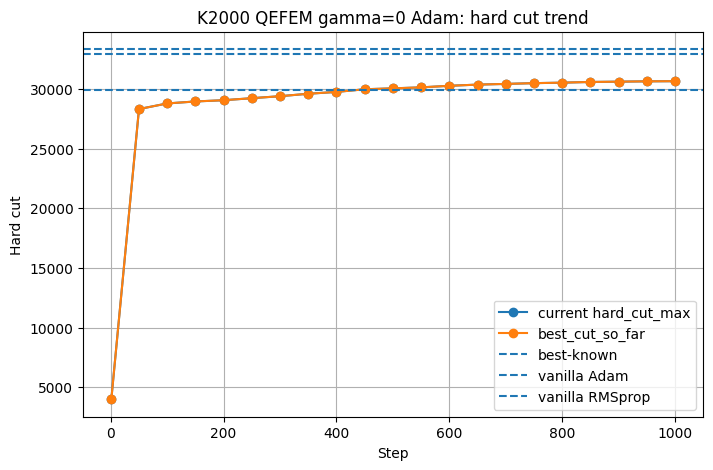

In [43]:
# ----------------------------
# Plot: hard cut trend
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_zero_df["step"],
    history_zero_df["hard_cut_max"],
    marker="o",
    label="current hard_cut_max",
)
plt.plot(
    history_zero_df["step"],
    history_zero_df["best_cut_so_far"],
    marker="o",
    label="best_cut_so_far",
)
plt.axhline(K2000_BEST_KNOWN, linestyle="--", label="best-known")
plt.axhline(VANILLA_ADAM_CUT, linestyle="--", label="vanilla Adam")
plt.axhline(VANILLA_RMSPROP_CUT, linestyle="--", label="vanilla RMSprop")
plt.xlabel("Step")
plt.ylabel("Hard cut")
plt.title("K2000 QEFEM gamma=0 Adam: hard cut trend")
plt.legend()
plt.grid(True)
plt.show()

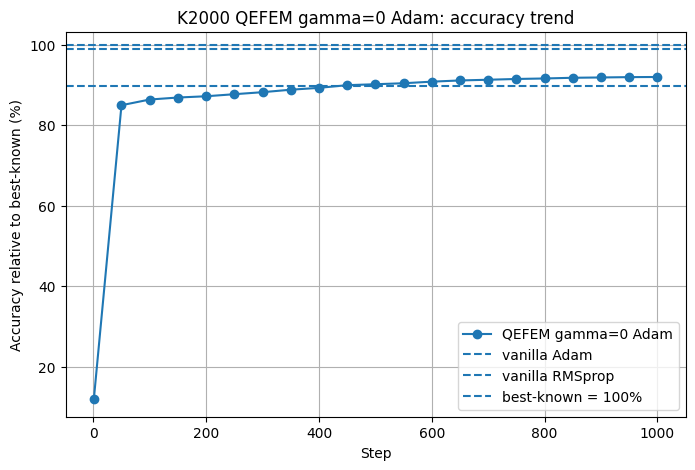

In [44]:
# ----------------------------
# Plot: accuracy trend
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_zero_df["step"],
    history_zero_df["accuracy_so_far_percent"],
    marker="o",
    label="QEFEM gamma=0 Adam",
)
plt.axhline(VANILLA_ADAM_ACCURACY, linestyle="--", label="vanilla Adam")
plt.axhline(VANILLA_RMSPROP_ACCURACY, linestyle="--", label="vanilla RMSprop")
plt.axhline(100.0, linestyle="--", label="best-known = 100%")
plt.xlabel("Step")
plt.ylabel("Accuracy relative to best-known (%)")
plt.title("K2000 QEFEM gamma=0 Adam: accuracy trend")
plt.legend()
plt.grid(True)
plt.show()


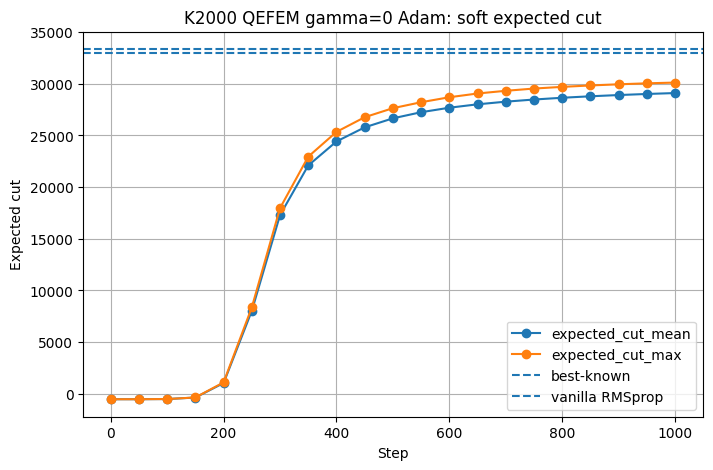

In [45]:
# ----------------------------
# Plot: soft expected cut
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_zero_df["step"],
    history_zero_df["expected_cut_mean"],
    marker="o",
    label="expected_cut_mean",
)
plt.plot(
    history_zero_df["step"],
    history_zero_df["expected_cut_max"],
    marker="o",
    label="expected_cut_max",
)
plt.axhline(K2000_BEST_KNOWN, linestyle="--", label="best-known")
plt.axhline(VANILLA_RMSPROP_CUT, linestyle="--", label="vanilla RMSprop")
plt.xlabel("Step")
plt.ylabel("Expected cut")
plt.title("K2000 QEFEM gamma=0 Adam: soft expected cut")
plt.legend()
plt.grid(True)
plt.show()




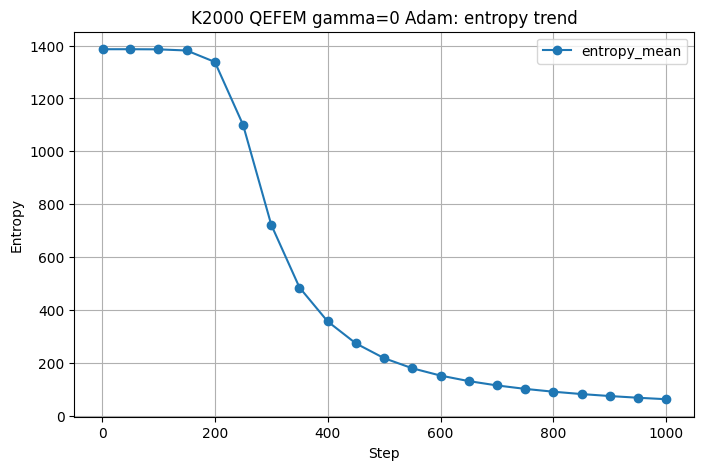

In [46]:
# ----------------------------
# Plot: entropy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_zero_df["step"],
    history_zero_df["entropy_mean"],
    marker="o",
    label="entropy_mean",
)
plt.xlabel("Step")
plt.ylabel("Entropy")
plt.title("K2000 QEFEM gamma=0 Adam: entropy trend")
plt.legend()
plt.grid(True)
plt.show()



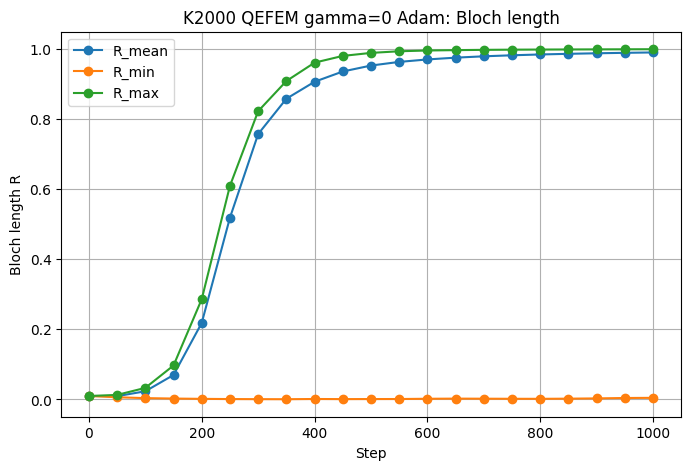

In [47]:
# ----------------------------
# Plot: Bloch length
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["R_mean"], marker="o", label="R_mean")
plt.plot(history_zero_df["step"], history_zero_df["R_min"], marker="o", label="R_min")
plt.plot(history_zero_df["step"], history_zero_df["R_max"], marker="o", label="R_max")
plt.xlabel("Step")
plt.ylabel("Bloch length R")
plt.title("K2000 QEFEM gamma=0 Adam: Bloch length")
plt.legend()
plt.grid(True)
plt.show()



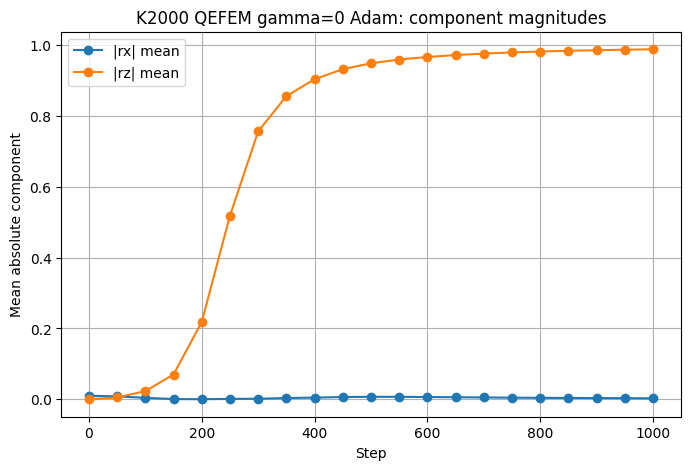

In [48]:
# ----------------------------
# Plot: rx/rz magnitudes
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_zero_df["step"],
    history_zero_df["rx_abs_mean"],
    marker="o",
    label="|rx| mean",
)
plt.plot(
    history_zero_df["step"],
    history_zero_df["rz_abs_mean"],
    marker="o",
    label="|rz| mean",
)
plt.xlabel("Step")
plt.ylabel("Mean absolute component")
plt.title("K2000 QEFEM gamma=0 Adam: component magnitudes")
plt.legend()
plt.grid(True)
plt.show()




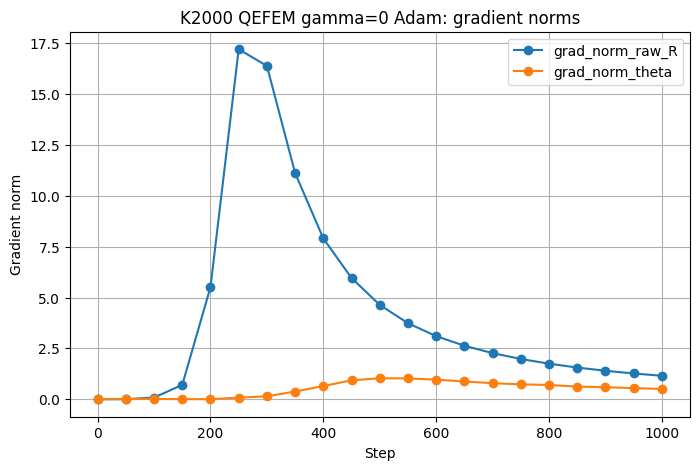

In [49]:
# ----------------------------
# Plot: gradient norms
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_zero_df["step"],
    history_zero_df["grad_norm_raw_R"],
    marker="o",
    label="grad_norm_raw_R",
)
plt.plot(
    history_zero_df["step"],
    history_zero_df["grad_norm_theta"],
    marker="o",
    label="grad_norm_theta",
)
plt.xlabel("Step")
plt.ylabel("Gradient norm")
plt.title("K2000 QEFEM gamma=0 Adam: gradient norms")
plt.legend()
plt.grid(True)
plt.show()




In [50]:
# ----------------------------
# Final interpretation
# ----------------------------
print("\n" + "=" * 80)
print("K2000 GAMMA=0 SANITY VERDICT")
print("=" * 80)

print(f"QEFEM gamma=0 Adam cut : {best_cut_zero:.0f}")
print(f"Vanilla Adam cut       : {VANILLA_ADAM_CUT:.0f}")
print(f"Vanilla RMSprop cut    : {VANILLA_RMSPROP_CUT:.0f}")
print(f"Best-known cut         : {K2000_BEST_KNOWN}")

print()
print(f"Delta vs vanilla Adam    : {best_cut_zero - VANILLA_ADAM_CUT:.0f}")
print(f"Delta vs vanilla RMSprop : {best_cut_zero - VANILLA_RMSPROP_CUT:.0f}")

print()
print(f"QEFEM gamma=0 accuracy : {accuracy_zero:.4f}%")
print(f"Vanilla Adam accuracy  : {VANILLA_ADAM_ACCURACY:.4f}%")
print(f"Vanilla RMS accuracy   : {VANILLA_RMSPROP_ACCURACY:.4f}%")

print()


K2000 GAMMA=0 SANITY VERDICT
QEFEM gamma=0 Adam cut : 30657
Vanilla Adam cut       : 29906
Vanilla RMSprop cut    : 32954
Best-known cut         : 33337

Delta vs vanilla Adam    : 751
Delta vs vanilla RMSprop : -2297

QEFEM gamma=0 accuracy : 91.9609%
Vanilla Adam accuracy  : 89.7081%
Vanilla RMS accuracy   : 98.8511%



In [52]:
if best_cut_zero >= VANILLA_ADAM_CUT:
    print("Verdict: gamma=0 QEFEM beats or matches vanilla Adam. Sanity pass.")
else:
    print("Verdict: gamma=0 QEFEM is below vanilla Adam. Not fatal, but inspect rx/rz and entropy.")

if best_cut_zero >= VANILLA_RMSPROP_CUT:
    print("Extra: gamma=0 also beats vanilla RMSprop. That would be spicy.")
else:
    print("Extra: gamma=0 does not beat vanilla RMSprop. That is acceptable; RMSprop is the real strong baseline.")

print("=" * 80)

Verdict: gamma=0 QEFEM beats or matches vanilla Adam. Sanity pass.
Extra: gamma=0 does not beat vanilla RMSprop. That is acceptable; RMSprop is the real strong baseline.


### Preparing for K2000 run

In [53]:
# ----------------------------
# Fresh seed
# ----------------------------
torch.manual_seed(SEED)


# ----------------------------
# raw_R initialization
# ----------------------------
raw_R_init_value = raw_R_from_init_value(
    R_INIT,
    device=W.device,
    dtype=W.dtype,
)

raw_R_anneal = raw_R_init_value + 1e-3 * torch.randn(
    REPLICAS,
    N,
    device=W.device,
    dtype=W.dtype,
)


# ----------------------------
# theta initialization
# ----------------------------
theta_anneal = THETA_CENTER + THETA_NOISE * torch.randn(
    REPLICAS,
    N,
    device=W.device,
    dtype=W.dtype,
)


# ----------------------------
# Make trainable
# ----------------------------
raw_R_anneal.requires_grad_(True)
theta_anneal.requires_grad_(True)


# ----------------------------
# Adam optimizer for gamma anneal run
# ----------------------------
optimizer_anneal = torch.optim.Adam(
    [raw_R_anneal, theta_anneal],
    lr=ADAM_LR,
)


# ----------------------------
# Initial Bloch diagnostics
# ----------------------------
with torch.no_grad():
    R_anneal_init, rx_anneal_init, rz_anneal_init = bloch_from_raw(
        raw_R_anneal,
        theta_anneal,
    )

    initial_expected_cut_anneal = quantum_expected_cut(
        W,
        rz_anneal_init,
    )

    initial_entropy_anneal = quantum_entropy_from_R(
        R_anneal_init,
    )

    initial_driver_anneal = transverse_driver_energy(
        rx_anneal_init,
        gamma=gamma_anneal_schedule[0],
    )

    initial_F_anneal, initial_aux_anneal = qefem_free_energy_maxcut(
        W=W,
        raw_R=raw_R_anneal,
        theta=theta_anneal,
        beta=beta_schedule[0],
        gamma=gamma_anneal_schedule[0],
    )

    initial_spins_anneal = torch.where(
        rz_anneal_init >= 0,
        torch.ones_like(rz_anneal_init),
        -torch.ones_like(rz_anneal_init),
    )

    initial_hard_cuts_anneal = discrete_cut(
        W,
        initial_spins_anneal,
    )


# ----------------------------
# Compare with gamma=0 initialization if available
# ----------------------------
if "initial_F_zero" in globals():
    initial_F_shift_vs_gamma0 = float(
        (
            initial_F_anneal.mean().detach().cpu()
            - initial_F_zero.mean().detach().cpu()
        )
    )
else:
    initial_F_shift_vs_gamma0 = None



In [54]:
# ----------------------------
# Print initialization diagnostics
# ----------------------------
print("Initialized QEFEM variables for Adam gamma anneal run.")
print("-" * 80)

print("Shapes:")
print("raw_R_anneal:", raw_R_anneal.shape)
print("theta_anneal:", theta_anneal.shape)

print("\nTrainability:")
print("raw_R_anneal requires_grad:", raw_R_anneal.requires_grad)
print("theta_anneal requires_grad:", theta_anneal.requires_grad)

Initialized QEFEM variables for Adam gamma anneal run.
--------------------------------------------------------------------------------
Shapes:
raw_R_anneal: torch.Size([128, 2000])
theta_anneal: torch.Size([128, 2000])

Trainability:
raw_R_anneal requires_grad: True
theta_anneal requires_grad: True


In [56]:
print("\nOptimizer:")
print(optimizer_anneal)

print("\nGamma schedule:")
print("gamma first :", float(gamma_anneal_schedule[0].detach().cpu()))
print("gamma middle:", float(gamma_anneal_schedule[len(gamma_anneal_schedule)//2].detach().cpu()))
print("gamma last  :", float(gamma_anneal_schedule[-1].detach().cpu()))


Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)

Gamma schedule:
gamma first : 1.0
gamma middle: 0.49949949979782104
gamma last  : 0.0


In [57]:
print("\nInitial R stats:")
print("R mean:", float(R_anneal_init.mean().detach().cpu()))
print("R min :", float(R_anneal_init.min().detach().cpu()))
print("R max :", float(R_anneal_init.max().detach().cpu()))

print("\nInitial component stats:")
print("rx mean     :", float(rx_anneal_init.mean().detach().cpu()))
print("rx abs mean :", float(rx_anneal_init.abs().mean().detach().cpu()))
print("rz mean     :", float(rz_anneal_init.mean().detach().cpu()))
print("rz abs mean :", float(rz_anneal_init.abs().mean().detach().cpu()))

print("\nInitial objective stats:")
print("Expected cut mean :", float(initial_expected_cut_anneal.mean().detach().cpu()))
print("Expected cut max  :", float(initial_expected_cut_anneal.max().detach().cpu()))
print("Hard cut mean     :", float(initial_hard_cuts_anneal.mean().detach().cpu()))
print("Hard cut max      :", float(initial_hard_cuts_anneal.max().detach().cpu()))
print("Entropy mean      :", float(initial_entropy_anneal.mean().detach().cpu()))
print("Driver mean       :", float(initial_driver_anneal.mean().detach().cpu()))
print("Free energy mean  :", float(initial_F_anneal.mean().detach().cpu()))

if initial_F_shift_vs_gamma0 is not None:
    print("\nInitial F shift vs gamma=0 initialization:")
    print("F_anneal_mean - F_zero_mean:", initial_F_shift_vs_gamma0)

print("\nReferences:")
print("Best-known cut       :", K2000_BEST_KNOWN)
print("Vanilla Adam cut     :", VANILLA_ADAM_CUT)
print("Vanilla RMSprop cut  :", VANILLA_RMSPROP_CUT)

if "best_cut_zero" in globals():
    print("QEFEM gamma=0 cut    :", best_cut_zero)


# ----------------------------
# Assertions
# ----------------------------
assert raw_R_anneal.shape == torch.Size([REPLICAS, N])
assert theta_anneal.shape == torch.Size([REPLICAS, N])

assert raw_R_anneal.requires_grad is True
assert theta_anneal.requires_grad is True

assert torch.all(R_anneal_init > 0), (
    "R must be positive."
)

assert torch.all(R_anneal_init < 1), (
    "R must be less than 1."
)

assert rx_anneal_init.abs().mean() > rz_anneal_init.abs().mean(), (
    "Initial state should be mostly transverse: |rx| should exceed |rz|."
)

assert initial_driver_anneal.mean() < 0, (
    "With gamma=1 and positive initial rx, driver energy should be negative."
)

assert initial_F_anneal.shape == torch.Size([REPLICAS]), (
    "Initial free energy should return one value per replica."
)

if "initial_F_zero" in globals():
    assert initial_F_anneal.mean() < initial_F_zero.mean(), (
        "Gamma=1 initial free energy should be lower than gamma=0 due to transverse driver."
    )


Initial R stats:
R mean: 0.009999998845160007
R min : 0.009952389635145664
R max : 0.010043242946267128

Initial component stats:
rx mean     : 0.00999999325722456
rx abs mean : 0.00999999325722456
rz mean     : -4.878411452580167e-09
rz abs mean : 7.979097063071094e-06

Initial objective stats:
Expected cut mean : -520.0
Expected cut max  : -520.0
Hard cut mean     : -600.296875
Hard cut max      : 932.0
Entropy mean      : 1386.1943359375
Driver mean       : -19.999984741210938
Free energy mean  : -1107.9853515625

Initial F shift vs gamma=0 initialization:
F_anneal_mean - F_zero_mean: -20.0

References:
Best-known cut       : 33337
Vanilla Adam cut     : 29906.0
Vanilla RMSprop cut  : 32954.0
QEFEM gamma=0 cut    : 30657.0


### K2000 gamma anneal

In [58]:
history_anneal = []

best_cut_anneal = -float("inf")
best_step_anneal = None
best_replica_anneal = None
best_spins_anneal = None

start_time_anneal = time.time()

print("=" * 80)
print("Starting K2000 QEFEM Adam gamma anneal run")
print("=" * 80)
print("Instance:", K2000_INSTANCE)
print("N:", N)
print("REPLICAS:", REPLICAS)
print("N_STEPS:", N_STEPS)
print("Optimizer: Adam")
print("LR:", ADAM_LR)
print("Seed:", SEED)
print("Beta:", float(beta_schedule[0].detach().cpu()), "->", float(beta_schedule[-1].detach().cpu()))
print("Gamma:", float(gamma_anneal_schedule[0].detach().cpu()), "->", float(gamma_anneal_schedule[-1].detach().cpu()))
print("Best-known cut:", K2000_BEST_KNOWN)
print("Vanilla Adam cut:", VANILLA_ADAM_CUT)
print("Vanilla RMSprop cut:", VANILLA_RMSPROP_CUT)

if "best_cut_zero" in globals():
    print("QEFEM gamma=0 Adam cut:", best_cut_zero)

print("-" * 80)

if W.device.type == "mps":
    torch.mps.synchronize()


# ============================================================
# Optimization loop
# ============================================================

for step in range(N_STEPS):
    beta_t = beta_schedule[step]
    gamma_t = gamma_anneal_schedule[step]

    optimizer_anneal.zero_grad()

    F_anneal, aux_anneal = qefem_free_energy_maxcut(
        W=W,
        raw_R=raw_R_anneal,
        theta=theta_anneal,
        beta=beta_t,
        gamma=gamma_t,
    )

    if not torch.isfinite(F_anneal).all():
        raise FloatingPointError(
            f"Non-finite F_anneal at step {step}. The quantum gremlin has become non-Hermitian."
        )

    loss_anneal = F_anneal.mean()

    if not torch.isfinite(loss_anneal):
        raise FloatingPointError(
            f"Non-finite loss_anneal at step {step}."
        )

    loss_anneal.backward()

    if raw_R_anneal.grad is None:
        raise RuntimeError(f"raw_R_anneal.grad is None at step {step}")

    if theta_anneal.grad is None:
        raise RuntimeError(f"theta_anneal.grad is None at step {step}")

    if not torch.isfinite(raw_R_anneal.grad).all():
        raise FloatingPointError(f"Non-finite raw_R_anneal.grad at step {step}")

    if not torch.isfinite(theta_anneal.grad).all():
        raise FloatingPointError(f"Non-finite theta_anneal.grad at step {step}")

    grad_norm_raw_R = raw_R_anneal.grad.detach().norm().item()
    grad_norm_theta = theta_anneal.grad.detach().norm().item()

    optimizer_anneal.step()

    if not torch.isfinite(raw_R_anneal).all():
        raise FloatingPointError(f"Non-finite raw_R_anneal after optimizer step {step}")

    if not torch.isfinite(theta_anneal).all():
        raise FloatingPointError(f"Non-finite theta_anneal after optimizer step {step}")


    # ----------------------------
    # Logging + hard readout
    # ----------------------------
    should_log = (
        step == 0
        or step == N_STEPS - 1
        or (step + 1) % LOG_EVERY == 0
    )

    if should_log:
        if W.device.type == "mps":
            torch.mps.synchronize()

        elapsed = time.time() - start_time_anneal

        with torch.no_grad():
            R_now, rx_now, rz_now = bloch_from_raw(
                raw_R_anneal,
                theta_anneal,
            )

            spins_now = torch.where(
                rz_now >= 0,
                torch.ones_like(rz_now),
                -torch.ones_like(rz_now),
            )

            hard_cuts_now = discrete_cut(
                W,
                spins_now,
            )

            step_best_cut_tensor, step_best_replica_tensor = torch.max(
                hard_cuts_now,
                dim=0,
            )

            step_best_cut = float(step_best_cut_tensor.detach().cpu())
            step_best_replica = int(step_best_replica_tensor.detach().cpu())

            if step_best_cut > best_cut_anneal:
                best_cut_anneal = step_best_cut
                best_step_anneal = step + 1
                best_replica_anneal = step_best_replica
                best_spins_anneal = spins_now[step_best_replica].detach().cpu().clone()

            row = {
                "step": step + 1,
                "beta": float(beta_t.detach().cpu()),
                "gamma": float(gamma_t.detach().cpu()),

                "loss_mean": float(loss_anneal.detach().cpu()),
                "free_energy_mean": float(F_anneal.mean().detach().cpu()),
                "free_energy_min": float(F_anneal.min().detach().cpu()),

                "expected_cut_mean": float(aux_anneal["expected_cut"].mean().detach().cpu()),
                "expected_cut_max": float(aux_anneal["expected_cut"].max().detach().cpu()),

                "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                "hard_cut_max": step_best_cut,
                "best_cut_so_far": best_cut_anneal,
                "gap_so_far": float(K2000_BEST_KNOWN - best_cut_anneal),
                "accuracy_so_far_percent": float(100.0 * best_cut_anneal / K2000_BEST_KNOWN),

                "entropy_mean": float(aux_anneal["entropy"].mean().detach().cpu()),
                "driver_energy_mean": float(aux_anneal["driver_energy"].mean().detach().cpu()),

                "R_mean": float(R_now.mean().detach().cpu()),
                "R_min": float(R_now.min().detach().cpu()),
                "R_max": float(R_now.max().detach().cpu()),

                "rx_mean": float(rx_now.mean().detach().cpu()),
                "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),

                "rz_mean": float(rz_now.mean().detach().cpu()),
                "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),

                "grad_norm_raw_R": grad_norm_raw_R,
                "grad_norm_theta": grad_norm_theta,

                "best_replica_current": step_best_replica,
                "best_replica_so_far": best_replica_anneal,

                "elapsed_sec": elapsed,
            }

            history_anneal.append(row)

            print(
                f"step {step + 1:5d}/{N_STEPS} | "
                f"beta={row['beta']:10.4f} | "
                f"gamma={row['gamma']:7.4f} | "
                f"F={row['free_energy_mean']:12.4f} | "
                f"Ecut_max={row['expected_cut_max']:10.1f} | "
                f"Hcut_max={row['hard_cut_max']:10.1f} | "
                f"best={row['best_cut_so_far']:10.1f} | "
                f"acc={row['accuracy_so_far_percent']:8.4f}% | "
                f"S={row['entropy_mean']:9.2f} | "
                f"|rx|={row['rx_abs_mean']:.4f} | "
                f"|rz|={row['rz_abs_mean']:.4f} | "
                f"time={elapsed:8.2f}s"
            )


Starting K2000 QEFEM Adam gamma anneal run
Instance: K2000
N: 2000
REPLICAS: 128
N_STEPS: 1000
Optimizer: Adam
LR: 0.01
Seed: 4
Beta: 0.8620690107345581 -> 16666.66796875
Gamma: 1.0 -> 0.0
Best-known cut: 33337
Vanilla Adam cut: 29906.0
Vanilla RMSprop cut: 32954.0
QEFEM gamma=0 Adam cut: 30657.0
--------------------------------------------------------------------------------
step     1/1000 | beta=    0.8621 | gamma= 1.0000 | F=  -1107.9854 | Ecut_max=    -520.0 | Hcut_max=   -5069.0 | best=   -5069.0 | acc=-15.2053% | S=  1386.19 | |rx|=0.0101 | |rz|=0.0001 | time=    0.05s
step    50/1000 | beta=    0.9065 | gamma= 0.9510 | F=  -1040.5203 | Ecut_max=    -520.0 | Hcut_max=    1742.0 | best=    1742.0 | acc=  5.2254% | S=  1386.02 | |rx|=0.0168 | |rz|=0.0000 | time=    0.72s
step   100/1000 | beta=    0.9569 | gamma= 0.9009 | F=   -983.1061 | Ecut_max=    -519.6 | Hcut_max=   30499.0 | best=   30499.0 | acc= 91.4869% | S=  1385.35 | |rx|=0.0309 | |rz|=0.0028 | time=    1.84s
step   15

In [59]:
if W.device.type == "mps":
    torch.mps.synchronize()

runtime_anneal = time.time() - start_time_anneal

history_anneal_df = pd.DataFrame(history_anneal)

gap_anneal = K2000_BEST_KNOWN - best_cut_anneal
accuracy_anneal = 100.0 * best_cut_anneal / K2000_BEST_KNOWN


In [60]:
# ----------------------------
# Final print
# ----------------------------
print("\n" + "=" * 80)
print("K2000 QEFEM Adam gamma anneal run complete")
print("=" * 80)
print("Best cut:", best_cut_anneal)
print("Best-known:", K2000_BEST_KNOWN)
print("Gap:", gap_anneal)
print("Accuracy %:", accuracy_anneal)
print("Best step:", best_step_anneal)
print("Best replica:", best_replica_anneal)
print("Runtime seconds:", runtime_anneal)

print("\nBaselines:")
print("Vanilla Adam cut:", VANILLA_ADAM_CUT)
print("Vanilla Adam gap:", VANILLA_ADAM_GAP)
print("Vanilla Adam accuracy %:", VANILLA_ADAM_ACCURACY)

print("\nVanilla RMSprop cut:", VANILLA_RMSPROP_CUT)
print("Vanilla RMSprop gap:", VANILLA_RMSPROP_GAP)
print("Vanilla RMSprop accuracy %:", VANILLA_RMSPROP_ACCURACY)

if "best_cut_zero" in globals():
    print("\nQEFEM gamma=0 Adam:")
    print("Gamma=0 cut:", best_cut_zero)
    print("Gamma=0 gap:", gap_zero)
    print("Gamma=0 accuracy %:", accuracy_zero)

print("\nDelta vs vanilla Adam:")
print("QEFEM Adam anneal cut - vanilla Adam cut:", best_cut_anneal - VANILLA_ADAM_CUT)
print("QEFEM Adam anneal accuracy - vanilla Adam accuracy:", accuracy_anneal - VANILLA_ADAM_ACCURACY)

print("\nDelta vs vanilla RMSprop:")
print("QEFEM Adam anneal cut - vanilla RMSprop cut:", best_cut_anneal - VANILLA_RMSPROP_CUT)
print("QEFEM Adam anneal accuracy - vanilla RMSprop accuracy:", accuracy_anneal - VANILLA_RMSPROP_ACCURACY)

if "best_cut_zero" in globals():
    print("\nDelta vs QEFEM gamma=0 Adam:")
    print("QEFEM Adam anneal cut - gamma=0 cut:", best_cut_anneal - best_cut_zero)
    print("QEFEM Adam anneal accuracy - gamma=0 accuracy:", accuracy_anneal - accuracy_zero)


K2000 QEFEM Adam gamma anneal run complete
Best cut: 32981.0
Best-known: 33337
Gap: 356.0
Accuracy %: 98.93211746707863
Best step: 600
Best replica: 47
Runtime seconds: 21.430938243865967

Baselines:
Vanilla Adam cut: 29906.0
Vanilla Adam gap: 3431.0
Vanilla Adam accuracy %: 89.7081321054684

Vanilla RMSprop cut: 32954.0
Vanilla RMSprop gap: 383.0
Vanilla RMSprop accuracy %: 98.85112637609863

QEFEM gamma=0 Adam:
Gamma=0 cut: 30657.0
Gamma=0 gap: 2680.0
Gamma=0 accuracy %: 91.9608843027267

Delta vs vanilla Adam:
QEFEM Adam anneal cut - vanilla Adam cut: 3075.0
QEFEM Adam anneal accuracy - vanilla Adam accuracy: 9.223985361610232

Delta vs vanilla RMSprop:
QEFEM Adam anneal cut - vanilla RMSprop cut: 27.0
QEFEM Adam anneal accuracy - vanilla RMSprop accuracy: 0.08099109097999246

Delta vs QEFEM gamma=0 Adam:
QEFEM Adam anneal cut - gamma=0 cut: 2324.0
QEFEM Adam anneal accuracy - gamma=0 accuracy: 6.971233164351929


### Inference and Diagnostics

In [61]:
# ----------------------------
# Display history
# ----------------------------
print("Adam anneal history shape:", history_anneal_df.shape)

print("\nFirst logged rows:")
display(history_anneal_df.head())

print("\nFinal logged rows:")
display(history_anneal_df.tail())


# ----------------------------
# Save history
# ----------------------------
history_anneal_path = OUTPUT_DIR / "K2000_qefem_adam_gamma_anneal_history.csv"
history_anneal_df.to_csv(history_anneal_path, index=False)

print("\nSaved Adam gamma-anneal history to:")
print(history_anneal_path.resolve())


# ----------------------------
# Build summary row
# ----------------------------
qefem_adam_anneal_summary = {
    "instance": K2000_INSTANCE,
    "mode": "qefem_adam_gamma_anneal",

    "N": N,
    "M": M,
    "replicas": REPLICAS,
    "n_steps": N_STEPS,
    "seed": SEED,

    "optimizer": "Adam",
    "lr": ADAM_LR,

    "Tmax": K2000_TMAX,
    "Tmin": K2000_TMIN,
    "beta_min": float(beta_schedule[0].detach().cpu()),
    "beta_max": float(beta_schedule[-1].detach().cpu()),

    "gamma_max": GAMMA_MAX,
    "gamma_min": GAMMA_MIN,

    "R_init": R_INIT,
    "theta_center": THETA_CENTER,
    "theta_noise": THETA_NOISE,

    "best_cut": best_cut_anneal,
    "best_known": K2000_BEST_KNOWN,
    "gap": gap_anneal,
    "accuracy_percent": accuracy_anneal,
    "best_step": best_step_anneal,
    "best_replica": best_replica_anneal,
    "runtime_sec": runtime_anneal,

    "vanilla_adam_cut": VANILLA_ADAM_CUT,
    "vanilla_adam_gap": VANILLA_ADAM_GAP,
    "vanilla_adam_accuracy_percent": VANILLA_ADAM_ACCURACY,
    "vanilla_adam_runtime_sec": VANILLA_ADAM_RUNTIME,

    "vanilla_rmsprop_cut": VANILLA_RMSPROP_CUT,
    "vanilla_rmsprop_gap": VANILLA_RMSPROP_GAP,
    "vanilla_rmsprop_accuracy_percent": VANILLA_RMSPROP_ACCURACY,
    "vanilla_rmsprop_runtime_sec": VANILLA_RMSPROP_RUNTIME,

    "delta_cut_vs_vanilla_adam": best_cut_anneal - VANILLA_ADAM_CUT,
    "delta_accuracy_vs_vanilla_adam": accuracy_anneal - VANILLA_ADAM_ACCURACY,

    "delta_cut_vs_vanilla_rmsprop": best_cut_anneal - VANILLA_RMSPROP_CUT,
    "delta_accuracy_vs_vanilla_rmsprop": accuracy_anneal - VANILLA_RMSPROP_ACCURACY,
}

if "best_cut_zero" in globals():
    qefem_adam_anneal_summary["gamma0_cut"] = best_cut_zero
    qefem_adam_anneal_summary["gamma0_gap"] = gap_zero
    qefem_adam_anneal_summary["gamma0_accuracy_percent"] = accuracy_zero
    qefem_adam_anneal_summary["delta_cut_vs_gamma0"] = best_cut_anneal - best_cut_zero
    qefem_adam_anneal_summary["delta_accuracy_vs_gamma0"] = accuracy_anneal - accuracy_zero

qefem_adam_anneal_summary_df = pd.DataFrame([qefem_adam_anneal_summary])

summary_anneal_path = OUTPUT_DIR / "K2000_qefem_adam_gamma_anneal_summary.csv"
qefem_adam_anneal_summary_df.to_csv(summary_anneal_path, index=False)

print("\nAdam gamma-anneal summary:")
display(qefem_adam_anneal_summary_df)

print("\nSaved Adam gamma-anneal summary to:")
print(summary_anneal_path.resolve())

Adam anneal history shape: (21, 27)

First logged rows:


,step,beta,gamma,loss_mean,free_energy_mean,free_energy_min,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,...,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta,best_replica_current,best_replica_so_far,elapsed_sec
0,1,0.862069,1.000000,-1107.985352,-1107.985352,-1107.986328,-520.000000,-520.000000,-6730.140625,-5069.0,...,0.010143,0.010099,0.010099,2.035583e-07,0.000070,0.038679,0.000041,45,45,0.054061
1,50,0.906531,0.950951,-1040.520264,-1040.520264,-1040.521973,-520.000000,-520.000000,454.742188,1742.0,...,0.016871,0.016799,0.016799,-1.145457e-08,0.000004,0.060225,0.000024,2,2,0.724249
2,100,0.956891,0.900901,-983.106079,-983.106079,-983.148560,-519.721924,-519.581665,29713.914062,30499.0,...,0.031218,0.030932,0.030932,-1.952586e-05,0.002769,0.102790,0.004701,18,18,1.840702
3,150,1.013175,0.850851,-1045.717407,-1045.717407,-1050.003174,-372.975159,-367.104156,31983.117188,32520.0,...,0.086044,0.032198,0.032198,-3.548487e-04,0.062011,0.698281,0.057033,36,36,2.964858
4,200,1.076495,0.800801,-2443.167969,-2443.167969,-2480.700928,1148.656494,1188.162720,32299.867188,32758.0,...,0.267823,0.031671,0.031671,-1.134330e-03,0.215518,5.828937,0.025853,47,47,4.061702



Final logged rows:


,step,beta,gamma,loss_mean,free_energy_mean,free_energy_min,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,...,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta,best_replica_current,best_replica_so_far,elapsed_sec
16,800,4.305146,0.20020,-31603.894531,-31603.894531,-32075.738281,31579.558594,32051.652344,32497.953125,32981.0,...,0.995789,0.010058,0.010058,-0.004021,0.984861,1.949396,0.055569,47,47,17.035894
17,850,5.739701,0.15015,-31700.759766,-31700.759766,-32173.429688,31684.707031,32157.517578,32498.320312,32981.0,...,0.996436,0.007572,0.007573,-0.004060,0.986647,1.739271,0.045308,47,47,18.152188
18,900,8.608070,0.10010,-31781.373047,-31781.373047,-32254.767578,31771.996094,32245.460938,32498.578125,32981.0,...,0.996931,0.005092,0.005092,-0.004097,0.988110,1.563744,0.049909,47,47,19.242449
19,950,17.207260,0.05005,-31849.500000,-31849.500000,-32323.498047,31845.421875,32319.437500,32498.789062,32981.0,...,0.997321,0.002545,0.002550,-0.004119,0.989367,1.415278,0.042880,47,47,20.329827
20,1000,16666.667969,0.00000,-31907.691406,-31907.691406,-32382.308594,31907.687500,32382.304688,32498.835938,32981.0,...,0.997636,0.000008,0.000195,-0.004103,0.990408,1.288246,0.041919,47,47,21.406895



Saved Adam gamma-anneal history to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_qefem_adam_gamma_anneal_history.csv

Adam gamma-anneal summary:


,instance,mode,N,M,replicas,n_steps,seed,optimizer,lr,Tmax,...,vanilla_rmsprop_runtime_sec,delta_cut_vs_vanilla_adam,delta_accuracy_vs_vanilla_adam,delta_cut_vs_vanilla_rmsprop,delta_accuracy_vs_vanilla_rmsprop,gamma0_cut,gamma0_gap,gamma0_accuracy_percent,delta_cut_vs_gamma0,delta_accuracy_vs_gamma0
0,K2000,qefem_adam_gamma_anneal,2000,1999000,128,1000,4,Adam,0.01,1.16,...,4.06409,3075.0,9.223985,27.0,0.080991,30657.0,2680.0,91.960884,2324.0,6.971233



Saved Adam gamma-anneal summary to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_qefem_adam_gamma_anneal_summary.csv


In [62]:
# ----------------------------
# Compact comparison table
# ----------------------------
comparison_rows = [
    {
        "method": "vanilla_Adam",
        "cut": VANILLA_ADAM_CUT,
        "best_known": K2000_BEST_KNOWN,
        "gap": VANILLA_ADAM_GAP,
        "accuracy_percent": VANILLA_ADAM_ACCURACY,
        "runtime_sec": VANILLA_ADAM_RUNTIME,
    },
    {
        "method": "vanilla_RMSprop",
        "cut": VANILLA_RMSPROP_CUT,
        "best_known": K2000_BEST_KNOWN,
        "gap": VANILLA_RMSPROP_GAP,
        "accuracy_percent": VANILLA_RMSPROP_ACCURACY,
        "runtime_sec": VANILLA_RMSPROP_RUNTIME,
    },
]

if "best_cut_zero" in globals():
    comparison_rows.append(
        {
            "method": "QEFEM_gamma0_Adam",
            "cut": best_cut_zero,
            "best_known": K2000_BEST_KNOWN,
            "gap": gap_zero,
            "accuracy_percent": accuracy_zero,
            "runtime_sec": runtime_zero,
        }
    )

comparison_rows.append(
    {
        "method": "QEFEM_Adam_gamma_anneal",
        "cut": best_cut_anneal,
        "best_known": K2000_BEST_KNOWN,
        "gap": gap_anneal,
        "accuracy_percent": accuracy_anneal,
        "runtime_sec": runtime_anneal,
    }
)

adam_anneal_comparison_df = pd.DataFrame(comparison_rows)

adam_anneal_comparison_path = OUTPUT_DIR / "K2000_adam_anneal_vs_baselines_comparison.csv"
adam_anneal_comparison_df.to_csv(adam_anneal_comparison_path, index=False)

print("\nAdam anneal vs baselines comparison:")
display(adam_anneal_comparison_df)

print("\nSaved comparison to:")
print(adam_anneal_comparison_path.resolve())




Adam anneal vs baselines comparison:


,method,cut,best_known,gap,accuracy_percent,runtime_sec
0,vanilla_Adam,29906.0,33337,3431.0,89.708132,4.196436
1,vanilla_RMSprop,32954.0,33337,383.0,98.851126,4.064090
2,QEFEM_gamma0_Adam,30657.0,33337,2680.0,91.960884,14.497133
3,QEFEM_Adam_gamma_anneal,32981.0,33337,356.0,98.932117,21.430938



Saved comparison to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_adam_anneal_vs_baselines_comparison.csv


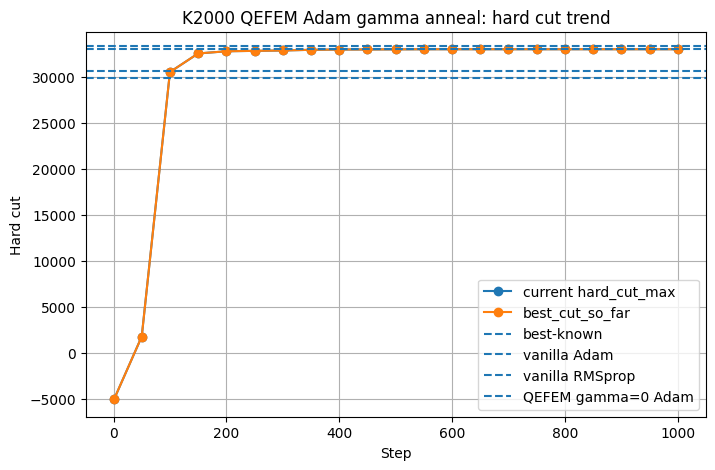

In [63]:
# ----------------------------
# Plot: hard cut trend
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["hard_cut_max"],
    marker="o",
    label="current hard_cut_max",
)
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["best_cut_so_far"],
    marker="o",
    label="best_cut_so_far",
)
plt.axhline(K2000_BEST_KNOWN, linestyle="--", label="best-known")
plt.axhline(VANILLA_ADAM_CUT, linestyle="--", label="vanilla Adam")
plt.axhline(VANILLA_RMSPROP_CUT, linestyle="--", label="vanilla RMSprop")

if "best_cut_zero" in globals():
    plt.axhline(best_cut_zero, linestyle="--", label="QEFEM gamma=0 Adam")

plt.xlabel("Step")
plt.ylabel("Hard cut")
plt.title("K2000 QEFEM Adam gamma anneal: hard cut trend")
plt.legend()
plt.grid(True)
plt.show()




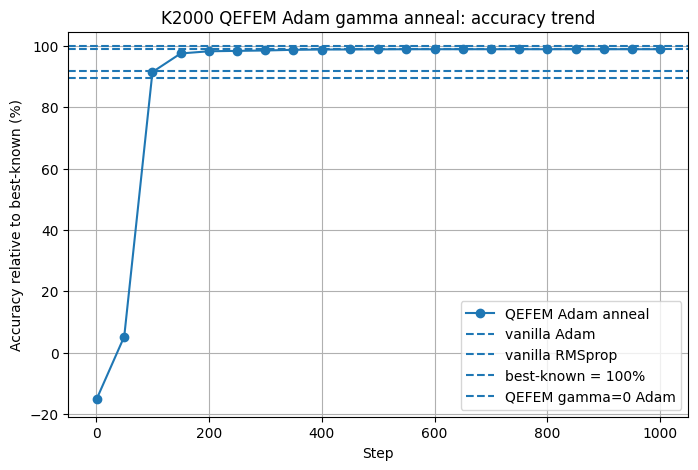

In [64]:
# ----------------------------
# Plot: accuracy trend
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["accuracy_so_far_percent"],
    marker="o",
    label="QEFEM Adam anneal",
)
plt.axhline(VANILLA_ADAM_ACCURACY, linestyle="--", label="vanilla Adam")
plt.axhline(VANILLA_RMSPROP_ACCURACY, linestyle="--", label="vanilla RMSprop")
plt.axhline(100.0, linestyle="--", label="best-known = 100%")

if "accuracy_zero" in globals():
    plt.axhline(accuracy_zero, linestyle="--", label="QEFEM gamma=0 Adam")

plt.xlabel("Step")
plt.ylabel("Accuracy relative to best-known (%)")
plt.title("K2000 QEFEM Adam gamma anneal: accuracy trend")
plt.legend()
plt.grid(True)
plt.show()




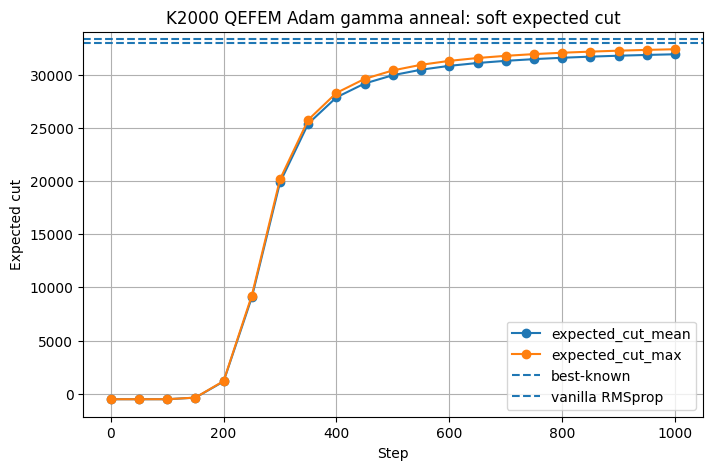

In [65]:
# ----------------------------
# Plot: soft expected cut
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["expected_cut_mean"],
    marker="o",
    label="expected_cut_mean",
)
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["expected_cut_max"],
    marker="o",
    label="expected_cut_max",
)
plt.axhline(K2000_BEST_KNOWN, linestyle="--", label="best-known")
plt.axhline(VANILLA_RMSPROP_CUT, linestyle="--", label="vanilla RMSprop")
plt.xlabel("Step")
plt.ylabel("Expected cut")
plt.title("K2000 QEFEM Adam gamma anneal: soft expected cut")
plt.legend()
plt.grid(True)
plt.show()




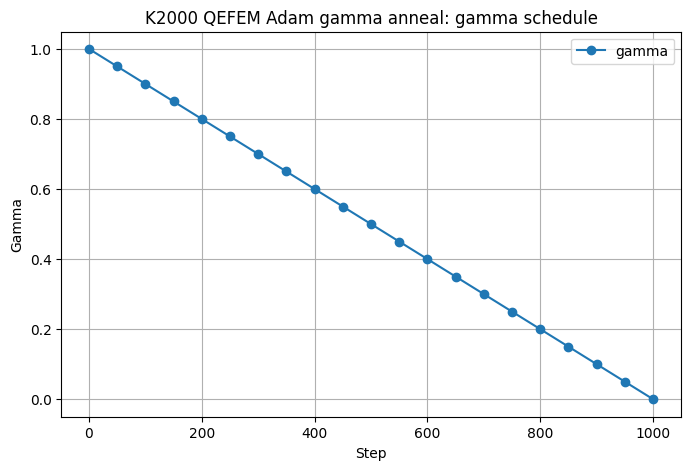

In [66]:
# ----------------------------
# Plot: gamma schedule
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["gamma"],
    marker="o",
    label="gamma",
)
plt.xlabel("Step")
plt.ylabel("Gamma")
plt.title("K2000 QEFEM Adam gamma anneal: gamma schedule")
plt.legend()
plt.grid(True)
plt.show()




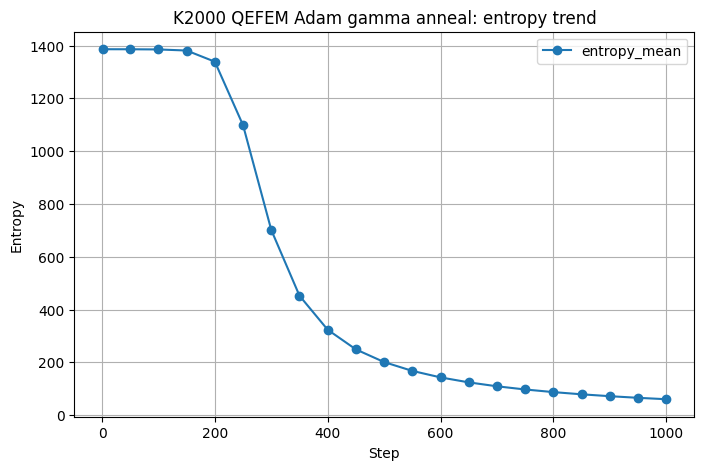

In [67]:
# ----------------------------
# Plot: entropy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["entropy_mean"],
    marker="o",
    label="entropy_mean",
)
plt.xlabel("Step")
plt.ylabel("Entropy")
plt.title("K2000 QEFEM Adam gamma anneal: entropy trend")
plt.legend()
plt.grid(True)
plt.show()




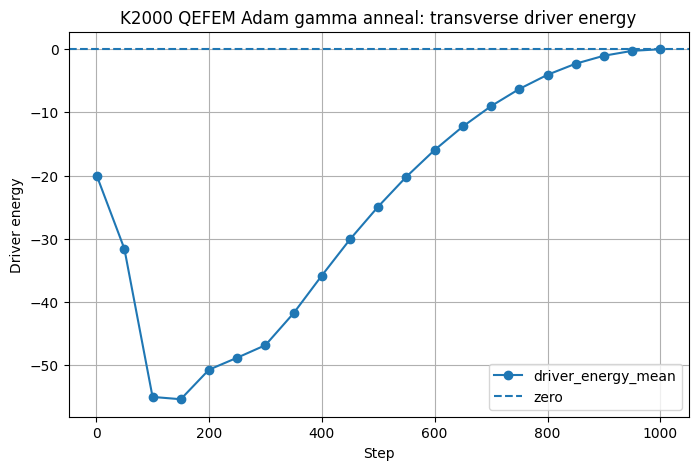

In [68]:
# ----------------------------
# Plot: driver energy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["driver_energy_mean"],
    marker="o",
    label="driver_energy_mean",
)
plt.axhline(0.0, linestyle="--", label="zero")
plt.xlabel("Step")
plt.ylabel("Driver energy")
plt.title("K2000 QEFEM Adam gamma anneal: transverse driver energy")
plt.legend()
plt.grid(True)
plt.show()




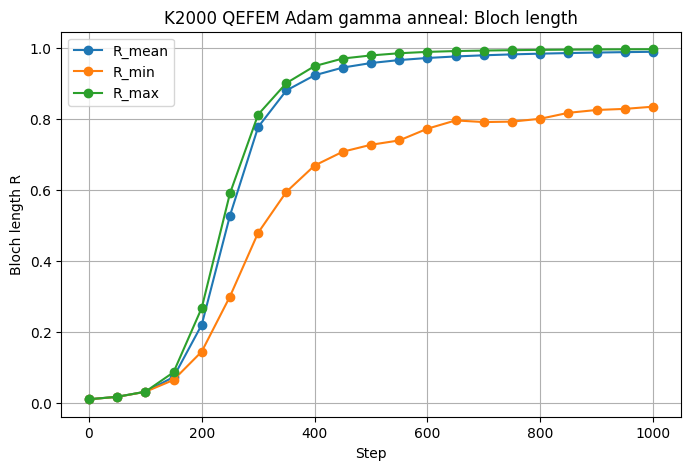

In [69]:
# ----------------------------
# Plot: Bloch length
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_anneal_df["step"], history_anneal_df["R_mean"], marker="o", label="R_mean")
plt.plot(history_anneal_df["step"], history_anneal_df["R_min"], marker="o", label="R_min")
plt.plot(history_anneal_df["step"], history_anneal_df["R_max"], marker="o", label="R_max")
plt.xlabel("Step")
plt.ylabel("Bloch length R")
plt.title("K2000 QEFEM Adam gamma anneal: Bloch length")
plt.legend()
plt.grid(True)
plt.show()




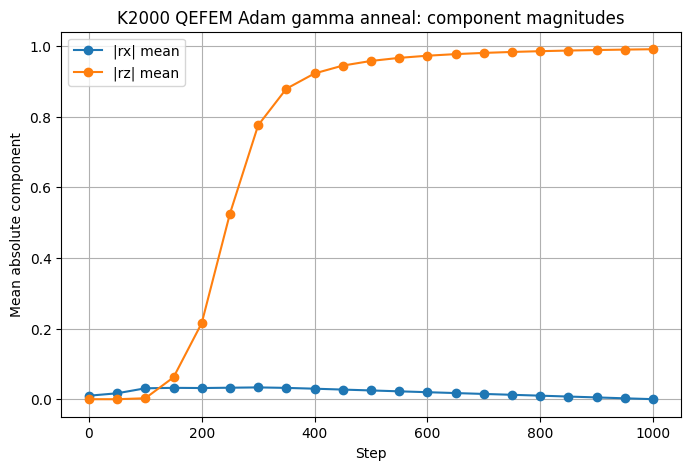

In [70]:
# ----------------------------
# Plot: rx/rz magnitudes
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["rx_abs_mean"],
    marker="o",
    label="|rx| mean",
)
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["rz_abs_mean"],
    marker="o",
    label="|rz| mean",
)
plt.xlabel("Step")
plt.ylabel("Mean absolute component")
plt.title("K2000 QEFEM Adam gamma anneal: component magnitudes")
plt.legend()
plt.grid(True)
plt.show()




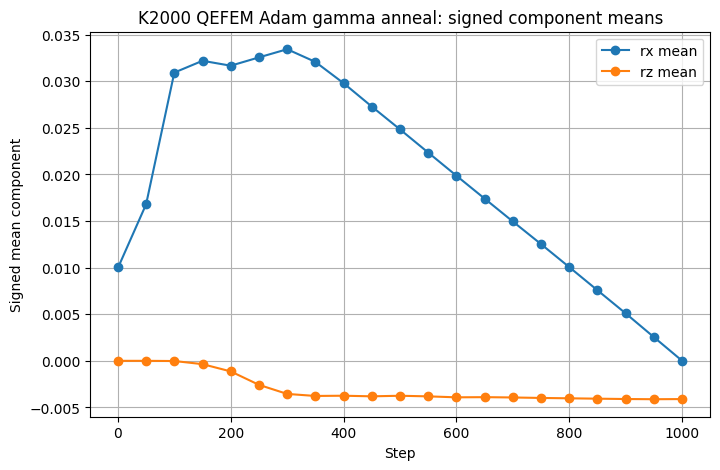

In [71]:
# ----------------------------
# Plot: signed rx/rz means
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["rx_mean"],
    marker="o",
    label="rx mean",
)
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["rz_mean"],
    marker="o",
    label="rz mean",
)
plt.xlabel("Step")
plt.ylabel("Signed mean component")
plt.title("K2000 QEFEM Adam gamma anneal: signed component means")
plt.legend()
plt.grid(True)
plt.show()




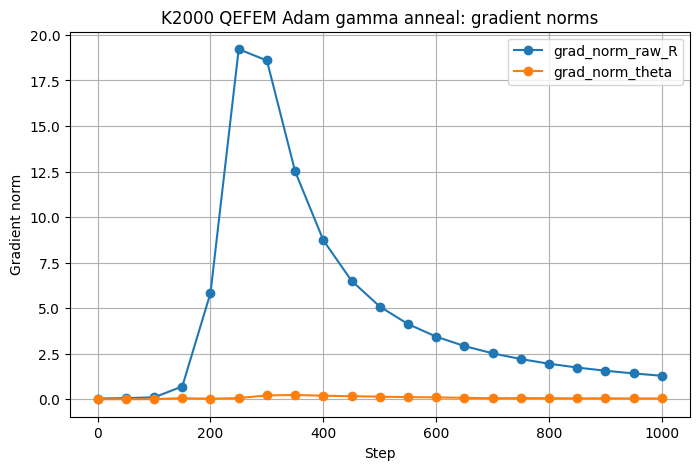

In [72]:
# ----------------------------
# Plot: gradient norms
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["grad_norm_raw_R"],
    marker="o",
    label="grad_norm_raw_R",
)
plt.plot(
    history_anneal_df["step"],
    history_anneal_df["grad_norm_theta"],
    marker="o",
    label="grad_norm_theta",
)
plt.xlabel("Step")
plt.ylabel("Gradient norm")
plt.title("K2000 QEFEM Adam gamma anneal: gradient norms")
plt.legend()
plt.grid(True)
plt.show()




In [74]:
# ----------------------------
# Final interpretation
# ----------------------------
print("\n" + "=" * 80)
print("K2000 ADAM GAMMA-ANNEAL VERDICT")
print("=" * 80)

print(f"QEFEM Adam anneal cut : {best_cut_anneal:.0f}")
if "best_cut_zero" in globals():
    print(f"QEFEM gamma=0 cut    : {best_cut_zero:.0f}")
print(f"Vanilla Adam cut      : {VANILLA_ADAM_CUT:.0f}")
print(f"Vanilla RMSprop cut   : {VANILLA_RMSPROP_CUT:.0f}")
print(f"Best-known cut        : {K2000_BEST_KNOWN}")

print()
print(f"Delta vs vanilla Adam    : {best_cut_anneal - VANILLA_ADAM_CUT:.0f}")
print(f"Delta vs vanilla RMSprop : {best_cut_anneal - VANILLA_RMSPROP_CUT:.0f}")

if "best_cut_zero" in globals():
    print(f"Delta vs gamma=0 Adam    : {best_cut_anneal - best_cut_zero:.0f}")

print()
print(f"QEFEM Adam anneal accuracy : {accuracy_anneal:.4f}%")
print(f"Vanilla Adam accuracy      : {VANILLA_ADAM_ACCURACY:.4f}%")
print(f"Vanilla RMS accuracy       : {VANILLA_RMSPROP_ACCURACY:.4f}%")

if "accuracy_zero" in globals():
    print(f"QEFEM gamma=0 accuracy     : {accuracy_zero:.4f}%")

print()


K2000 ADAM GAMMA-ANNEAL VERDICT
QEFEM Adam anneal cut : 32981
QEFEM gamma=0 cut    : 30657
Vanilla Adam cut      : 29906
Vanilla RMSprop cut   : 32954
Best-known cut        : 33337

Delta vs vanilla Adam    : 3075
Delta vs vanilla RMSprop : 27
Delta vs gamma=0 Adam    : 2324

QEFEM Adam anneal accuracy : 98.9321%
Vanilla Adam accuracy      : 89.7081%
Vanilla RMS accuracy       : 98.8511%
QEFEM gamma=0 accuracy     : 91.9609%



In [75]:
if best_cut_anneal >= VANILLA_ADAM_CUT:
    print("Verdict: QEFEM Adam anneal beats or matches vanilla Adam. First quantum-driver sanity pass.")
else:
    print("Verdict: QEFEM Adam anneal is below vanilla Adam. Inspect rx/rz and schedule behavior.")

if "best_cut_zero" in globals():
    if best_cut_anneal >= best_cut_zero:
        print("Driver check: annealed gamma improves over gamma=0. Good sign.")
    else:
        print("Driver check: annealed gamma does not improve over gamma=0. Not fatal, but suspicious.")

if best_cut_anneal >= VANILLA_RMSPROP_CUT:
    print("RMSprop target: Adam-anneal already beats vanilla RMSprop. That would be a serious result.")
else:
    print("RMSprop target: Adam-anneal does not beat vanilla RMSprop. Next run is QEFEM RMSprop anneal.")

print("=" * 80)

Verdict: QEFEM Adam anneal beats or matches vanilla Adam. First quantum-driver sanity pass.
Driver check: annealed gamma improves over gamma=0. Good sign.
RMSprop target: Adam-anneal already beats vanilla RMSprop. That would be a serious result.


### Quantum RMS prop

In [76]:
# ----------------------------
# Fresh seed
# ----------------------------
torch.manual_seed(SEED)


# ----------------------------
# raw_R initialization
# ----------------------------
raw_R_init_value = raw_R_from_init_value(
    R_INIT,
    device=W.device,
    dtype=W.dtype,
)

raw_R_rms = raw_R_init_value + 1e-3 * torch.randn(
    REPLICAS,
    N,
    device=W.device,
    dtype=W.dtype,
)


# ----------------------------
# theta initialization
# ----------------------------
theta_rms = THETA_CENTER + THETA_NOISE * torch.randn(
    REPLICAS,
    N,
    device=W.device,
    dtype=W.dtype,
)


# ----------------------------
# Make trainable
# ----------------------------
raw_R_rms.requires_grad_(True)
theta_rms.requires_grad_(True)


# ----------------------------
# RMSprop optimizer for gamma anneal run
# ----------------------------
optimizer_rms = torch.optim.RMSprop(
    [raw_R_rms, theta_rms],
    lr=RMS_LR,
    alpha=RMS_ALPHA,
    eps=RMS_EPS,
    weight_decay=RMS_WEIGHT_DECAY,
    momentum=RMS_MOMENTUM,
    centered=RMS_CENTERED,
)


# ----------------------------
# Initial Bloch diagnostics
# ----------------------------
with torch.no_grad():
    R_rms_init, rx_rms_init, rz_rms_init = bloch_from_raw(
        raw_R_rms,
        theta_rms,
    )

    initial_expected_cut_rms = quantum_expected_cut(
        W,
        rz_rms_init,
    )

    initial_entropy_rms = quantum_entropy_from_R(
        R_rms_init,
    )

    initial_driver_rms = transverse_driver_energy(
        rx_rms_init,
        gamma=gamma_anneal_schedule[0],
    )

    initial_F_rms, initial_aux_rms = qefem_free_energy_maxcut(
        W=W,
        raw_R=raw_R_rms,
        theta=theta_rms,
        beta=beta_schedule[0],
        gamma=gamma_anneal_schedule[0],
    )

    initial_spins_rms = torch.where(
        rz_rms_init >= 0,
        torch.ones_like(rz_rms_init),
        -torch.ones_like(rz_rms_init),
    )

    initial_hard_cuts_rms = discrete_cut(
        W,
        initial_spins_rms,
    )


# ----------------------------
# Compare with previous initializations if available
# ----------------------------
if "initial_F_zero" in globals():
    initial_F_rms_shift_vs_gamma0 = float(
        (
            initial_F_rms.mean().detach().cpu()
            - initial_F_zero.mean().detach().cpu()
        )
    )
else:
    initial_F_rms_shift_vs_gamma0 = None

if "initial_F_anneal" in globals():
    initial_F_rms_shift_vs_adam_anneal = float(
        (
            initial_F_rms.mean().detach().cpu()
            - initial_F_anneal.mean().detach().cpu()
        )
    )
else:
    initial_F_rms_shift_vs_adam_anneal = None

In [77]:
# ----------------------------
# Print initialization diagnostics
# ----------------------------
print("Initialized QEFEM variables for RMSprop gamma anneal run.")
print("-" * 80)

print("Shapes:")
print("raw_R_rms:", raw_R_rms.shape)
print("theta_rms:", theta_rms.shape)

print("\nTrainability:")
print("raw_R_rms requires_grad:", raw_R_rms.requires_grad)
print("theta_rms requires_grad:", theta_rms.requires_grad)

print("\nOptimizer:")
print(optimizer_rms)

print("\nRMSprop settings:")
print("lr:", RMS_LR)
print("alpha:", RMS_ALPHA)
print("momentum:", RMS_MOMENTUM)
print("weight_decay:", RMS_WEIGHT_DECAY)
print("eps:", RMS_EPS)
print("centered:", RMS_CENTERED)

print("\nGamma schedule:")
print("gamma first :", float(gamma_anneal_schedule[0].detach().cpu()))
print("gamma middle:", float(gamma_anneal_schedule[len(gamma_anneal_schedule)//2].detach().cpu()))
print("gamma last  :", float(gamma_anneal_schedule[-1].detach().cpu()))

print("\nInitial R stats:")
print("R mean:", float(R_rms_init.mean().detach().cpu()))
print("R min :", float(R_rms_init.min().detach().cpu()))
print("R max :", float(R_rms_init.max().detach().cpu()))

print("\nInitial component stats:")
print("rx mean     :", float(rx_rms_init.mean().detach().cpu()))
print("rx abs mean :", float(rx_rms_init.abs().mean().detach().cpu()))
print("rz mean     :", float(rz_rms_init.mean().detach().cpu()))
print("rz abs mean :", float(rz_rms_init.abs().mean().detach().cpu()))

print("\nInitial objective stats:")
print("Expected cut mean :", float(initial_expected_cut_rms.mean().detach().cpu()))
print("Expected cut max  :", float(initial_expected_cut_rms.max().detach().cpu()))
print("Hard cut mean     :", float(initial_hard_cuts_rms.mean().detach().cpu()))
print("Hard cut max      :", float(initial_hard_cuts_rms.max().detach().cpu()))
print("Entropy mean      :", float(initial_entropy_rms.mean().detach().cpu()))
print("Driver mean       :", float(initial_driver_rms.mean().detach().cpu()))
print("Free energy mean  :", float(initial_F_rms.mean().detach().cpu()))

if initial_F_rms_shift_vs_gamma0 is not None:
    print("\nInitial F shift vs gamma=0 initialization:")
    print("F_rms_mean - F_zero_mean:", initial_F_rms_shift_vs_gamma0)

if initial_F_rms_shift_vs_adam_anneal is not None:
    print("\nInitial F shift vs Adam anneal initialization:")
    print("F_rms_mean - F_adam_anneal_mean:", initial_F_rms_shift_vs_adam_anneal)

print("\nReferences:")
print("Best-known cut          :", K2000_BEST_KNOWN)
print("Vanilla Adam cut        :", VANILLA_ADAM_CUT)
print("Vanilla RMSprop cut     :", VANILLA_RMSPROP_CUT)

if "best_cut_zero" in globals():
    print("QEFEM gamma=0 Adam cut :", best_cut_zero)

if "best_cut_anneal" in globals():
    print("QEFEM Adam anneal cut  :", best_cut_anneal)


# ----------------------------
# Assertions
# ----------------------------
assert raw_R_rms.shape == torch.Size([REPLICAS, N])
assert theta_rms.shape == torch.Size([REPLICAS, N])

assert raw_R_rms.requires_grad is True
assert theta_rms.requires_grad is True

assert torch.all(R_rms_init > 0), (
    "R must be positive."
)

assert torch.all(R_rms_init < 1), (
    "R must be less than 1."
)

assert rx_rms_init.abs().mean() > rz_rms_init.abs().mean(), (
    "Initial state should be mostly transverse: |rx| should exceed |rz|."
)

assert initial_driver_rms.mean() < 0, (
    "With gamma=1 and positive initial rx, driver energy should be negative."
)

assert initial_F_rms.shape == torch.Size([REPLICAS]), (
    "Initial free energy should return one value per replica."
)

if "initial_F_zero" in globals():
    assert initial_F_rms.mean() < initial_F_zero.mean(), (
        "Gamma=1 initial free energy should be lower than gamma=0 due to transverse driver."
    )

Initialized QEFEM variables for RMSprop gamma anneal run.
--------------------------------------------------------------------------------
Shapes:
raw_R_rms: torch.Size([128, 2000])
theta_rms: torch.Size([128, 2000])

Trainability:
raw_R_rms requires_grad: True
theta_rms requires_grad: True

Optimizer:
RMSprop (
Parameter Group 0
    alpha: 0.56
    capturable: False
    centered: False
    differentiable: False
    eps: 1e-08
    foreach: None
    lr: 0.03
    maximize: False
    momentum: 0.63
    weight_decay: 0.013
)

RMSprop settings:
lr: 0.03
alpha: 0.56
momentum: 0.63
weight_decay: 0.013
eps: 1e-08
centered: False

Gamma schedule:
gamma first : 1.0
gamma middle: 0.49949949979782104
gamma last  : 0.0

Initial R stats:
R mean: 0.009999998845160007
R min : 0.009952389635145664
R max : 0.010043242946267128

Initial component stats:
rx mean     : 0.00999999325722456
rx abs mean : 0.00999999325722456
rz mean     : -4.878411452580167e-09
rz abs mean : 7.979097063071094e-06

Initial obj

In [78]:
history_rms = []

best_cut_rms = -float("inf")
best_step_rms = None
best_replica_rms = None
best_spins_rms = None

start_time_rms = time.time()

print("=" * 80)
print("Starting K2000 QEFEM RMSprop gamma anneal run")
print("=" * 80)
print("Instance:", K2000_INSTANCE)
print("N:", N)
print("REPLICAS:", REPLICAS)
print("N_STEPS:", N_STEPS)
print("Optimizer: RMSprop")
print("LR:", RMS_LR)
print("alpha:", RMS_ALPHA)
print("momentum:", RMS_MOMENTUM)
print("weight_decay:", RMS_WEIGHT_DECAY)
print("eps:", RMS_EPS)
print("centered:", RMS_CENTERED)
print("Seed:", SEED)
print("Beta:", float(beta_schedule[0].detach().cpu()), "->", float(beta_schedule[-1].detach().cpu()))
print("Gamma:", float(gamma_anneal_schedule[0].detach().cpu()), "->", float(gamma_anneal_schedule[-1].detach().cpu()))
print("Best-known cut:", K2000_BEST_KNOWN)
print("Vanilla Adam cut:", VANILLA_ADAM_CUT)
print("Vanilla RMSprop cut:", VANILLA_RMSPROP_CUT)

if "best_cut_zero" in globals():
    print("QEFEM gamma=0 Adam cut:", best_cut_zero)

if "best_cut_anneal" in globals():
    print("QEFEM Adam anneal cut:", best_cut_anneal)

print("-" * 80)

if W.device.type == "mps":
    torch.mps.synchronize()


# ============================================================
# Optimization loop
# ============================================================

for step in range(N_STEPS):
    beta_t = beta_schedule[step]
    gamma_t = gamma_anneal_schedule[step]

    optimizer_rms.zero_grad()

    F_rms, aux_rms = qefem_free_energy_maxcut(
        W=W,
        raw_R=raw_R_rms,
        theta=theta_rms,
        beta=beta_t,
        gamma=gamma_t,
    )

    if not torch.isfinite(F_rms).all():
        raise FloatingPointError(
            f"Non-finite F_rms at step {step}. RMSprop has offended mathematics."
        )

    loss_rms = F_rms.mean()

    if not torch.isfinite(loss_rms):
        raise FloatingPointError(
            f"Non-finite loss_rms at step {step}."
        )

    loss_rms.backward()

    if raw_R_rms.grad is None:
        raise RuntimeError(f"raw_R_rms.grad is None at step {step}")

    if theta_rms.grad is None:
        raise RuntimeError(f"theta_rms.grad is None at step {step}")

    if not torch.isfinite(raw_R_rms.grad).all():
        raise FloatingPointError(f"Non-finite raw_R_rms.grad at step {step}")

    if not torch.isfinite(theta_rms.grad).all():
        raise FloatingPointError(f"Non-finite theta_rms.grad at step {step}")

    grad_norm_raw_R = raw_R_rms.grad.detach().norm().item()
    grad_norm_theta = theta_rms.grad.detach().norm().item()

    optimizer_rms.step()

    if not torch.isfinite(raw_R_rms).all():
        raise FloatingPointError(f"Non-finite raw_R_rms after optimizer step {step}")

    if not torch.isfinite(theta_rms).all():
        raise FloatingPointError(f"Non-finite theta_rms after optimizer step {step}")


    # ----------------------------
    # Logging + hard readout
    # ----------------------------
    should_log = (
        step == 0
        or step == N_STEPS - 1
        or (step + 1) % LOG_EVERY == 0
    )

    if should_log:
        if W.device.type == "mps":
            torch.mps.synchronize()

        elapsed = time.time() - start_time_rms

        with torch.no_grad():
            R_now, rx_now, rz_now = bloch_from_raw(
                raw_R_rms,
                theta_rms,
            )

            spins_now = torch.where(
                rz_now >= 0,
                torch.ones_like(rz_now),
                -torch.ones_like(rz_now),
            )

            hard_cuts_now = discrete_cut(
                W,
                spins_now,
            )

            step_best_cut_tensor, step_best_replica_tensor = torch.max(
                hard_cuts_now,
                dim=0,
            )

            step_best_cut = float(step_best_cut_tensor.detach().cpu())
            step_best_replica = int(step_best_replica_tensor.detach().cpu())

            if step_best_cut > best_cut_rms:
                best_cut_rms = step_best_cut
                best_step_rms = step + 1
                best_replica_rms = step_best_replica
                best_spins_rms = spins_now[step_best_replica].detach().cpu().clone()

            row = {
                "step": step + 1,
                "beta": float(beta_t.detach().cpu()),
                "gamma": float(gamma_t.detach().cpu()),

                "loss_mean": float(loss_rms.detach().cpu()),
                "free_energy_mean": float(F_rms.mean().detach().cpu()),
                "free_energy_min": float(F_rms.min().detach().cpu()),

                "expected_cut_mean": float(aux_rms["expected_cut"].mean().detach().cpu()),
                "expected_cut_max": float(aux_rms["expected_cut"].max().detach().cpu()),

                "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                "hard_cut_max": step_best_cut,
                "best_cut_so_far": best_cut_rms,
                "gap_so_far": float(K2000_BEST_KNOWN - best_cut_rms),
                "accuracy_so_far_percent": float(100.0 * best_cut_rms / K2000_BEST_KNOWN),

                "entropy_mean": float(aux_rms["entropy"].mean().detach().cpu()),
                "driver_energy_mean": float(aux_rms["driver_energy"].mean().detach().cpu()),

                "R_mean": float(R_now.mean().detach().cpu()),
                "R_min": float(R_now.min().detach().cpu()),
                "R_max": float(R_now.max().detach().cpu()),

                "rx_mean": float(rx_now.mean().detach().cpu()),
                "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),

                "rz_mean": float(rz_now.mean().detach().cpu()),
                "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),

                "grad_norm_raw_R": grad_norm_raw_R,
                "grad_norm_theta": grad_norm_theta,

                "best_replica_current": step_best_replica,
                "best_replica_so_far": best_replica_rms,

                "elapsed_sec": elapsed,
            }

            history_rms.append(row)

            print(
                f"step {step + 1:5d}/{N_STEPS} | "
                f"beta={row['beta']:10.4f} | "
                f"gamma={row['gamma']:7.4f} | "
                f"F={row['free_energy_mean']:12.4f} | "
                f"Ecut_max={row['expected_cut_max']:10.1f} | "
                f"Hcut_max={row['hard_cut_max']:10.1f} | "
                f"best={row['best_cut_so_far']:10.1f} | "
                f"acc={row['accuracy_so_far_percent']:8.4f}% | "
                f"S={row['entropy_mean']:9.2f} | "
                f"|rx|={row['rx_abs_mean']:.4f} | "
                f"|rz|={row['rz_abs_mean']:.4f} | "
                f"time={elapsed:8.2f}s"
            )




Starting K2000 QEFEM RMSprop gamma anneal run
Instance: K2000
N: 2000
REPLICAS: 128
N_STEPS: 1000
Optimizer: RMSprop
LR: 0.03
alpha: 0.56
momentum: 0.63
weight_decay: 0.013
eps: 1e-08
centered: False
Seed: 4
Beta: 0.8620690107345581 -> 16666.66796875
Gamma: 1.0 -> 0.0
Best-known cut: 33337
Vanilla Adam cut: 29906.0
Vanilla RMSprop cut: 32954.0
QEFEM gamma=0 Adam cut: 30657.0
QEFEM Adam anneal cut: 32981.0
--------------------------------------------------------------------------------
step     1/1000 | beta=    0.8621 | gamma= 1.0000 | F=  -1107.9854 | Ecut_max=    -520.0 | Hcut_max=       0.0 | best=       0.0 | acc=  0.0000% | S=  1386.19 | |rx|=0.0104 | |rz|=0.0005 | time=    0.11s
step    50/1000 | beta=    0.9065 | gamma= 0.9510 | F=  -1717.9631 | Ecut_max=     139.6 | Hcut_max=     494.0 | best=     494.0 | acc=  1.4818% | S=  1293.50 | |rx|=0.0877 | |rz|=0.2842 | time=    0.49s
step   100/1000 | beta=    0.9569 | gamma= 0.9009 | F= -21148.5957 | Ecut_max=   20342.3 | Hcut_max=  

In [79]:
if W.device.type == "mps":
    torch.mps.synchronize()

runtime_rms = time.time() - start_time_rms

history_rms_df = pd.DataFrame(history_rms)

gap_rms = K2000_BEST_KNOWN - best_cut_rms
accuracy_rms = 100.0 * best_cut_rms / K2000_BEST_KNOWN




In [80]:
# ----------------------------
# Final print
# ----------------------------
print("\n" + "=" * 80)
print("K2000 QEFEM RMSprop gamma anneal run complete")
print("=" * 80)
print("Best cut:", best_cut_rms)
print("Best-known:", K2000_BEST_KNOWN)
print("Gap:", gap_rms)
print("Accuracy %:", accuracy_rms)
print("Best step:", best_step_rms)
print("Best replica:", best_replica_rms)
print("Runtime seconds:", runtime_rms)

print("\nBaselines:")
print("Vanilla Adam cut:", VANILLA_ADAM_CUT)
print("Vanilla Adam gap:", VANILLA_ADAM_GAP)
print("Vanilla Adam accuracy %:", VANILLA_ADAM_ACCURACY)

print("\nVanilla RMSprop cut:", VANILLA_RMSPROP_CUT)
print("Vanilla RMSprop gap:", VANILLA_RMSPROP_GAP)
print("Vanilla RMSprop accuracy %:", VANILLA_RMSPROP_ACCURACY)




K2000 QEFEM RMSprop gamma anneal run complete
Best cut: 31106.0
Best-known: 33337
Gap: 2231.0
Accuracy %: 93.30773614902361
Best step: 550
Best replica: 52
Runtime seconds: 8.185935020446777

Baselines:
Vanilla Adam cut: 29906.0
Vanilla Adam gap: 3431.0
Vanilla Adam accuracy %: 89.7081321054684

Vanilla RMSprop cut: 32954.0
Vanilla RMSprop gap: 383.0
Vanilla RMSprop accuracy %: 98.85112637609863


In [82]:
if "best_cut_zero" in globals():
    print("\nQEFEM gamma=0 Adam:")
    print("Gamma=0 cut:", best_cut_zero)
    print("Gamma=0 gap:", gap_zero)
    print("Gamma=0 accuracy %:", accuracy_zero)

if "best_cut_anneal" in globals():
    print("\nQEFEM Adam anneal:")
    print("Adam anneal cut:", best_cut_anneal)
    print("Adam anneal gap:", gap_anneal)
    print("Adam anneal accuracy %:", accuracy_anneal)

print("\nDelta vs vanilla Adam:")
print("QEFEM RMS anneal cut - vanilla Adam cut:", best_cut_rms - VANILLA_ADAM_CUT)
print("QEFEM RMS anneal accuracy - vanilla Adam accuracy:", accuracy_rms - VANILLA_ADAM_ACCURACY)

print("\nDelta vs vanilla RMSprop:")
print("QEFEM RMS anneal cut - vanilla RMSprop cut:", best_cut_rms - VANILLA_RMSPROP_CUT)
print("QEFEM RMS anneal accuracy - vanilla RMSprop accuracy:", accuracy_rms - VANILLA_RMSPROP_ACCURACY)

if "best_cut_zero" in globals():
    print("\nDelta vs QEFEM gamma=0 Adam:")
    print("QEFEM RMS anneal cut - gamma=0 cut:", best_cut_rms - best_cut_zero)
    print("QEFEM RMS anneal accuracy - gamma=0 accuracy:", accuracy_rms - accuracy_zero)

if "best_cut_anneal" in globals():
    print("\nDelta vs QEFEM Adam anneal:")
    print("QEFEM RMS anneal cut - Adam anneal cut:", best_cut_rms - best_cut_anneal)
    print("QEFEM RMS anneal accuracy - Adam anneal accuracy:", accuracy_rms - accuracy_anneal)


QEFEM gamma=0 Adam:
Gamma=0 cut: 30657.0
Gamma=0 gap: 2680.0
Gamma=0 accuracy %: 91.9608843027267

QEFEM Adam anneal:
Adam anneal cut: 32981.0
Adam anneal gap: 356.0
Adam anneal accuracy %: 98.93211746707863

Delta vs vanilla Adam:
QEFEM RMS anneal cut - vanilla Adam cut: 1200.0
QEFEM RMS anneal accuracy - vanilla Adam accuracy: 3.5996040435552175

Delta vs vanilla RMSprop:
QEFEM RMS anneal cut - vanilla RMSprop cut: -1848.0
QEFEM RMS anneal accuracy - vanilla RMSprop accuracy: -5.543390227075022

Delta vs QEFEM gamma=0 Adam:
QEFEM RMS anneal cut - gamma=0 cut: 449.0
QEFEM RMS anneal accuracy - gamma=0 accuracy: 1.3468518462969143

Delta vs QEFEM Adam anneal:
QEFEM RMS anneal cut - Adam anneal cut: -1875.0
QEFEM RMS anneal accuracy - Adam anneal accuracy: -5.624381318055015


### Inference and Diagnostics

In [83]:
assert "history_rms_df" in globals(), (
    "Run Cell 18 first. history_rms_df does not exist."
)

assert len(history_rms_df) > 0, (
    "history_rms_df is empty. Cell 18 did not log anything."
)

assert "best_cut_rms" in globals(), (
    "Run Cell 18 first. best_cut_rms does not exist."
)


# ----------------------------
# Display history
# ----------------------------
print("RMSprop anneal history shape:", history_rms_df.shape)

print("\nFirst logged rows:")
display(history_rms_df.head())

print("\nFinal logged rows:")
display(history_rms_df.tail())


# ----------------------------
# Save history
# ----------------------------
history_rms_path = OUTPUT_DIR / "K2000_qefem_rmsprop_gamma_anneal_history.csv"
history_rms_df.to_csv(history_rms_path, index=False)

print("\nSaved RMSprop gamma-anneal history to:")
print(history_rms_path.resolve())


# ----------------------------
# Build summary row
# ----------------------------
qefem_rms_anneal_summary = {
    "instance": K2000_INSTANCE,
    "mode": "qefem_rmsprop_gamma_anneal",

    "N": N,
    "M": M,
    "replicas": REPLICAS,
    "n_steps": N_STEPS,
    "seed": SEED,

    "optimizer": "RMSprop",
    "lr": RMS_LR,
    "alpha": RMS_ALPHA,
    "momentum": RMS_MOMENTUM,
    "weight_decay": RMS_WEIGHT_DECAY,
    "eps": RMS_EPS,
    "centered": RMS_CENTERED,

    "Tmax": K2000_TMAX,
    "Tmin": K2000_TMIN,
    "beta_min": float(beta_schedule[0].detach().cpu()),
    "beta_max": float(beta_schedule[-1].detach().cpu()),

    "gamma_max": GAMMA_MAX,
    "gamma_min": GAMMA_MIN,

    "R_init": R_INIT,
    "theta_center": THETA_CENTER,
    "theta_noise": THETA_NOISE,

    "best_cut": best_cut_rms,
    "best_known": K2000_BEST_KNOWN,
    "gap": gap_rms,
    "accuracy_percent": accuracy_rms,
    "best_step": best_step_rms,
    "best_replica": best_replica_rms,
    "runtime_sec": runtime_rms,

    "vanilla_adam_cut": VANILLA_ADAM_CUT,
    "vanilla_adam_gap": VANILLA_ADAM_GAP,
    "vanilla_adam_accuracy_percent": VANILLA_ADAM_ACCURACY,
    "vanilla_adam_runtime_sec": VANILLA_ADAM_RUNTIME,

    "vanilla_rmsprop_cut": VANILLA_RMSPROP_CUT,
    "vanilla_rmsprop_gap": VANILLA_RMSPROP_GAP,
    "vanilla_rmsprop_accuracy_percent": VANILLA_RMSPROP_ACCURACY,
    "vanilla_rmsprop_runtime_sec": VANILLA_RMSPROP_RUNTIME,

    "delta_cut_vs_vanilla_adam": best_cut_rms - VANILLA_ADAM_CUT,
    "delta_accuracy_vs_vanilla_adam": accuracy_rms - VANILLA_ADAM_ACCURACY,

    "delta_cut_vs_vanilla_rmsprop": best_cut_rms - VANILLA_RMSPROP_CUT,
    "delta_accuracy_vs_vanilla_rmsprop": accuracy_rms - VANILLA_RMSPROP_ACCURACY,
}

if "best_cut_zero" in globals():
    qefem_rms_anneal_summary["gamma0_adam_cut"] = best_cut_zero
    qefem_rms_anneal_summary["gamma0_adam_gap"] = gap_zero
    qefem_rms_anneal_summary["gamma0_adam_accuracy_percent"] = accuracy_zero
    qefem_rms_anneal_summary["delta_cut_vs_gamma0_adam"] = best_cut_rms - best_cut_zero
    qefem_rms_anneal_summary["delta_accuracy_vs_gamma0_adam"] = accuracy_rms - accuracy_zero

if "best_cut_anneal" in globals():
    qefem_rms_anneal_summary["adam_anneal_cut"] = best_cut_anneal
    qefem_rms_anneal_summary["adam_anneal_gap"] = gap_anneal
    qefem_rms_anneal_summary["adam_anneal_accuracy_percent"] = accuracy_anneal
    qefem_rms_anneal_summary["delta_cut_vs_adam_anneal"] = best_cut_rms - best_cut_anneal
    qefem_rms_anneal_summary["delta_accuracy_vs_adam_anneal"] = accuracy_rms - accuracy_anneal

qefem_rms_anneal_summary_df = pd.DataFrame([qefem_rms_anneal_summary])

summary_rms_path = OUTPUT_DIR / "K2000_qefem_rmsprop_gamma_anneal_summary.csv"
qefem_rms_anneal_summary_df.to_csv(summary_rms_path, index=False)

print("\nRMSprop gamma-anneal summary:")
display(qefem_rms_anneal_summary_df)

print("\nSaved RMSprop gamma-anneal summary to:")
print(summary_rms_path.resolve())




RMSprop anneal history shape: (21, 27)

First logged rows:


,step,beta,gamma,loss_mean,free_energy_mean,free_energy_min,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,...,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta,best_replica_current,best_replica_so_far,elapsed_sec
0,1,0.862069,1.000000,-1107.985352,-1107.985352,-1107.986328,-520.000000,-520.000000,0.000000,0.0,...,0.010503,0.010447,0.010447,0.000473,0.000473,0.038679,0.000041,0,0,0.111826
1,50,0.906531,0.950951,-1717.963135,-1717.963135,-1718.533325,139.160034,139.606567,461.859375,494.0,...,0.348066,0.087727,0.087727,0.284144,0.284164,4.830218,4.012783,1,1,0.492729
2,100,0.956891,0.900901,-21148.595703,-21148.595703,-21179.064453,20310.685547,20342.285156,28015.679688,28099.0,...,0.938798,0.111480,0.111495,0.328501,0.775800,11.308210,10.686945,105,105,0.890174
3,150,1.013175,0.850851,-22915.208984,-22915.208984,-22998.574219,22176.011719,22258.519531,30074.781250,30269.0,...,0.943025,0.102451,0.102477,0.280610,0.803598,11.536875,10.940811,71,71,1.278184
4,200,1.076495,0.800801,-23272.097656,-23272.097656,-23432.794922,22590.515625,22755.783203,30512.726562,30753.0,...,0.944446,0.098287,0.098323,0.269248,0.810426,11.632257,11.005023,68,68,1.654327



Final logged rows:


,step,beta,gamma,loss_mean,free_energy_mean,free_energy_min,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,...,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta,best_replica_current,best_replica_so_far,elapsed_sec
16,800,4.305146,0.20020,-23291.027344,-23291.027344,-23510.652344,23134.511719,23354.859375,30839.640625,31106.0,...,0.944412,0.072800,0.074261,0.261124,0.824188,11.895058,11.183411,52,52,6.297216
17,850,5.739701,0.15015,-23273.427734,-23273.427734,-23491.169922,23156.775391,23375.060547,30839.585938,31106.0,...,0.944178,0.070848,0.072757,0.261158,0.824783,11.911210,11.195593,52,52,6.668620
18,900,8.608070,0.10010,-23256.335938,-23256.335938,-23479.416016,23179.056641,23402.531250,30839.335938,31106.0,...,0.944667,0.068869,0.071362,0.261197,0.825382,11.927368,11.203321,52,52,7.049669
19,950,17.207260,0.05005,-23239.480469,-23239.480469,-23459.738281,23201.076172,23421.511719,30839.335938,31106.0,...,0.944780,0.066938,0.070215,0.261229,0.825957,11.944382,11.206820,52,52,7.420045
20,1000,16666.667969,0.00000,-23222.755859,-23222.755859,-23441.599609,23222.724609,23441.566406,30839.335938,31106.0,...,0.944808,0.064927,0.069376,0.261238,0.826540,11.960995,11.211339,52,52,7.796994



Saved RMSprop gamma-anneal history to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_qefem_rmsprop_gamma_anneal_history.csv

RMSprop gamma-anneal summary:


,instance,mode,N,M,replicas,n_steps,seed,optimizer,lr,alpha,...,gamma0_adam_cut,gamma0_adam_gap,gamma0_adam_accuracy_percent,delta_cut_vs_gamma0_adam,delta_accuracy_vs_gamma0_adam,adam_anneal_cut,adam_anneal_gap,adam_anneal_accuracy_percent,delta_cut_vs_adam_anneal,delta_accuracy_vs_adam_anneal
0,K2000,qefem_rmsprop_gamma_anneal,2000,1999000,128,1000,4,RMSprop,0.03,0.56,...,30657.0,2680.0,91.960884,449.0,1.346852,32981.0,356.0,98.932117,-1875.0,-5.624381



Saved RMSprop gamma-anneal summary to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_qefem_rmsprop_gamma_anneal_summary.csv


In [84]:
# ----------------------------
# Compact comparison table
# ----------------------------
comparison_rows = [
    {
        "method": "vanilla_Adam",
        "cut": VANILLA_ADAM_CUT,
        "best_known": K2000_BEST_KNOWN,
        "gap": VANILLA_ADAM_GAP,
        "accuracy_percent": VANILLA_ADAM_ACCURACY,
        "runtime_sec": VANILLA_ADAM_RUNTIME,
    },
    {
        "method": "vanilla_RMSprop",
        "cut": VANILLA_RMSPROP_CUT,
        "best_known": K2000_BEST_KNOWN,
        "gap": VANILLA_RMSPROP_GAP,
        "accuracy_percent": VANILLA_RMSPROP_ACCURACY,
        "runtime_sec": VANILLA_RMSPROP_RUNTIME,
    },
]

if "best_cut_zero" in globals():
    comparison_rows.append(
        {
            "method": "QEFEM_gamma0_Adam",
            "cut": best_cut_zero,
            "best_known": K2000_BEST_KNOWN,
            "gap": gap_zero,
            "accuracy_percent": accuracy_zero,
            "runtime_sec": runtime_zero,
        }
    )

if "best_cut_anneal" in globals():
    comparison_rows.append(
        {
            "method": "QEFEM_Adam_gamma_anneal",
            "cut": best_cut_anneal,
            "best_known": K2000_BEST_KNOWN,
            "gap": gap_anneal,
            "accuracy_percent": accuracy_anneal,
            "runtime_sec": runtime_anneal,
        }
    )

comparison_rows.append(
    {
        "method": "QEFEM_RMSprop_gamma_anneal",
        "cut": best_cut_rms,
        "best_known": K2000_BEST_KNOWN,
        "gap": gap_rms,
        "accuracy_percent": accuracy_rms,
        "runtime_sec": runtime_rms,
    }
)

rms_anneal_comparison_df = pd.DataFrame(comparison_rows)

rms_anneal_comparison_path = OUTPUT_DIR / "K2000_rmsprop_anneal_vs_baselines_comparison.csv"
rms_anneal_comparison_df.to_csv(rms_anneal_comparison_path, index=False)

print("\nRMSprop anneal vs all available baselines:")
display(rms_anneal_comparison_df)

print("\nSaved comparison to:")
print(rms_anneal_comparison_path.resolve())





RMSprop anneal vs all available baselines:


,method,cut,best_known,gap,accuracy_percent,runtime_sec
0,vanilla_Adam,29906.0,33337,3431.0,89.708132,4.196436
1,vanilla_RMSprop,32954.0,33337,383.0,98.851126,4.064090
2,QEFEM_gamma0_Adam,30657.0,33337,2680.0,91.960884,14.497133
3,QEFEM_Adam_gamma_anneal,32981.0,33337,356.0,98.932117,21.430938
4,QEFEM_RMSprop_gamma_anneal,31106.0,33337,2231.0,93.307736,8.185935



Saved comparison to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_rmsprop_anneal_vs_baselines_comparison.csv


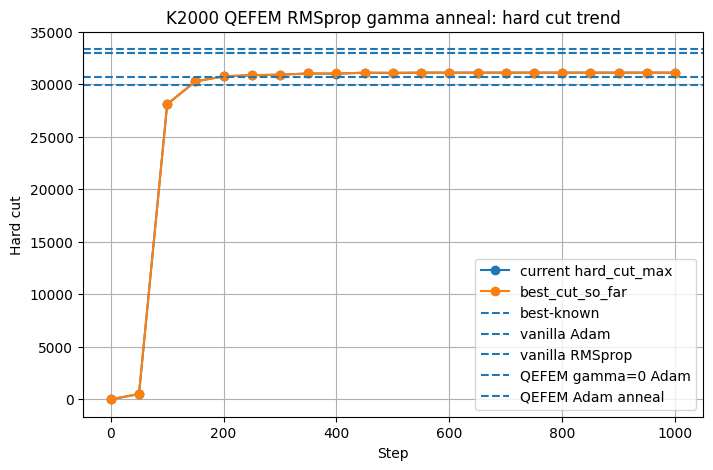

In [85]:
# ----------------------------
# Plot: hard cut trend
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_rms_df["step"],
    history_rms_df["hard_cut_max"],
    marker="o",
    label="current hard_cut_max",
)
plt.plot(
    history_rms_df["step"],
    history_rms_df["best_cut_so_far"],
    marker="o",
    label="best_cut_so_far",
)
plt.axhline(K2000_BEST_KNOWN, linestyle="--", label="best-known")
plt.axhline(VANILLA_ADAM_CUT, linestyle="--", label="vanilla Adam")
plt.axhline(VANILLA_RMSPROP_CUT, linestyle="--", label="vanilla RMSprop")

if "best_cut_zero" in globals():
    plt.axhline(best_cut_zero, linestyle="--", label="QEFEM gamma=0 Adam")

if "best_cut_anneal" in globals():
    plt.axhline(best_cut_anneal, linestyle="--", label="QEFEM Adam anneal")

plt.xlabel("Step")
plt.ylabel("Hard cut")
plt.title("K2000 QEFEM RMSprop gamma anneal: hard cut trend")
plt.legend()
plt.grid(True)
plt.show()




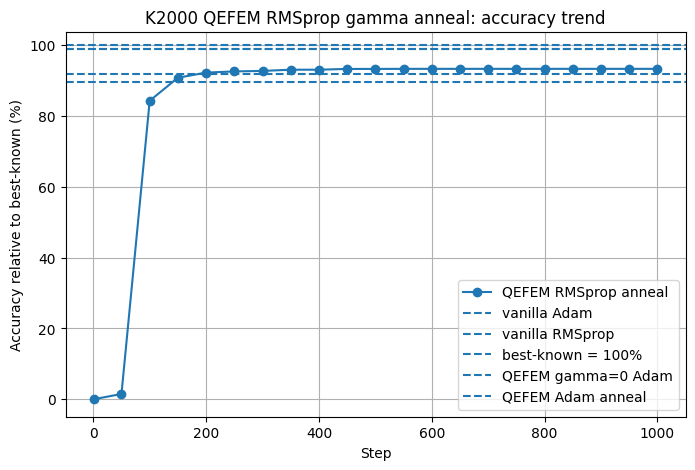

In [86]:
# ----------------------------
# Plot: accuracy trend
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_rms_df["step"],
    history_rms_df["accuracy_so_far_percent"],
    marker="o",
    label="QEFEM RMSprop anneal",
)
plt.axhline(VANILLA_ADAM_ACCURACY, linestyle="--", label="vanilla Adam")
plt.axhline(VANILLA_RMSPROP_ACCURACY, linestyle="--", label="vanilla RMSprop")
plt.axhline(100.0, linestyle="--", label="best-known = 100%")

if "accuracy_zero" in globals():
    plt.axhline(accuracy_zero, linestyle="--", label="QEFEM gamma=0 Adam")

if "accuracy_anneal" in globals():
    plt.axhline(accuracy_anneal, linestyle="--", label="QEFEM Adam anneal")

plt.xlabel("Step")
plt.ylabel("Accuracy relative to best-known (%)")
plt.title("K2000 QEFEM RMSprop gamma anneal: accuracy trend")
plt.legend()
plt.grid(True)
plt.show()




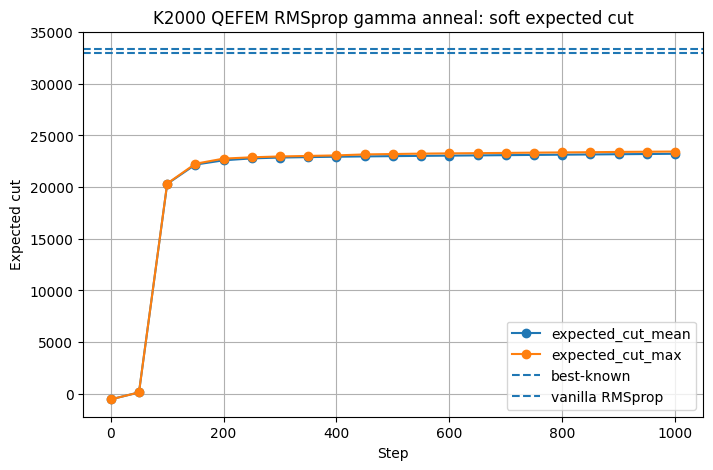

In [87]:
# ----------------------------
# Plot: soft expected cut
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_rms_df["step"],
    history_rms_df["expected_cut_mean"],
    marker="o",
    label="expected_cut_mean",
)
plt.plot(
    history_rms_df["step"],
    history_rms_df["expected_cut_max"],
    marker="o",
    label="expected_cut_max",
)
plt.axhline(K2000_BEST_KNOWN, linestyle="--", label="best-known")
plt.axhline(VANILLA_RMSPROP_CUT, linestyle="--", label="vanilla RMSprop")
plt.xlabel("Step")
plt.ylabel("Expected cut")
plt.title("K2000 QEFEM RMSprop gamma anneal: soft expected cut")
plt.legend()
plt.grid(True)
plt.show()




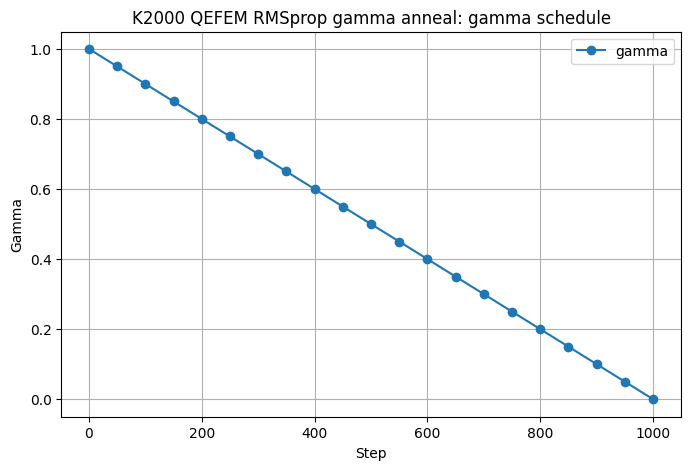

In [88]:
# ----------------------------
# Plot: gamma schedule
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_rms_df["step"],
    history_rms_df["gamma"],
    marker="o",
    label="gamma",
)
plt.xlabel("Step")
plt.ylabel("Gamma")
plt.title("K2000 QEFEM RMSprop gamma anneal: gamma schedule")
plt.legend()
plt.grid(True)
plt.show()




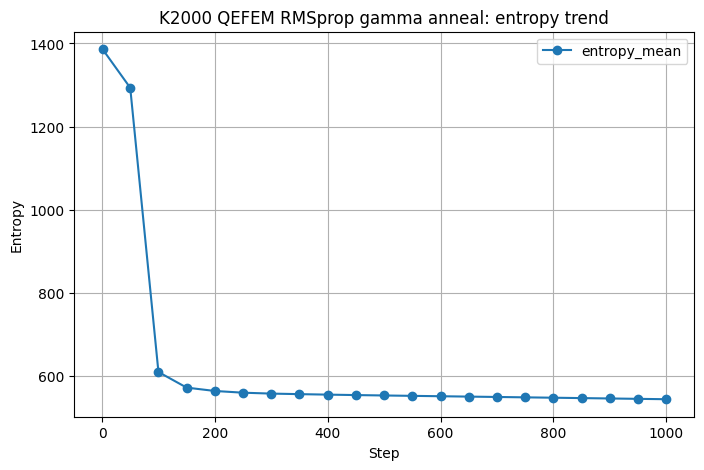

In [89]:
# ----------------------------
# Plot: entropy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_rms_df["step"],
    history_rms_df["entropy_mean"],
    marker="o",
    label="entropy_mean",
)
plt.xlabel("Step")
plt.ylabel("Entropy")
plt.title("K2000 QEFEM RMSprop gamma anneal: entropy trend")
plt.legend()
plt.grid(True)
plt.show()




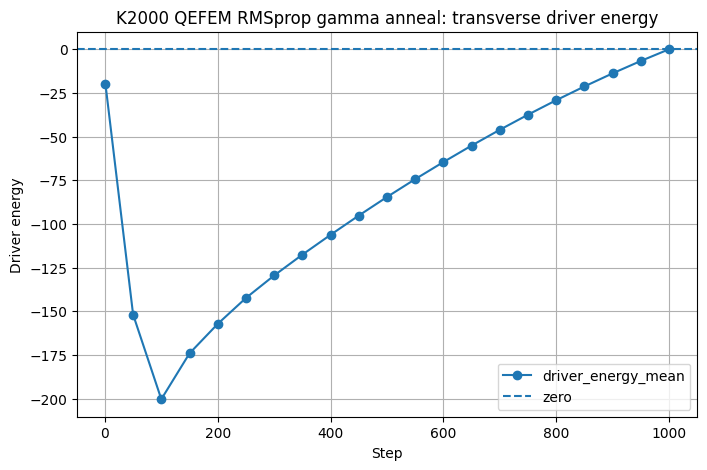

In [90]:
# ----------------------------
# Plot: driver energy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_rms_df["step"],
    history_rms_df["driver_energy_mean"],
    marker="o",
    label="driver_energy_mean",
)
plt.axhline(0.0, linestyle="--", label="zero")
plt.xlabel("Step")
plt.ylabel("Driver energy")
plt.title("K2000 QEFEM RMSprop gamma anneal: transverse driver energy")
plt.legend()
plt.grid(True)
plt.show()




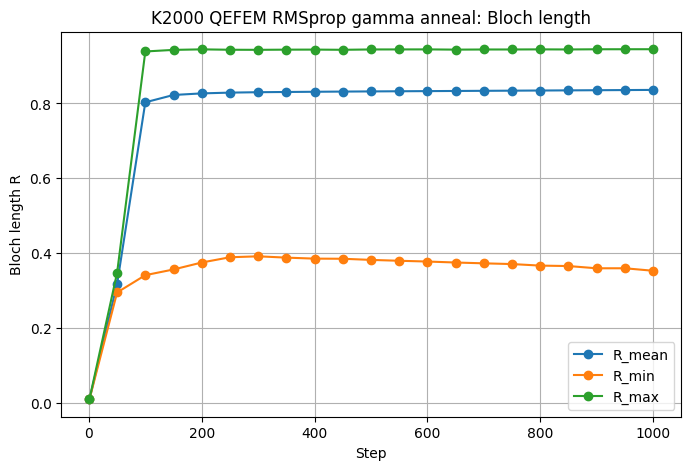

In [91]:
# ----------------------------
# Plot: Bloch length
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_rms_df["step"], history_rms_df["R_mean"], marker="o", label="R_mean")
plt.plot(history_rms_df["step"], history_rms_df["R_min"], marker="o", label="R_min")
plt.plot(history_rms_df["step"], history_rms_df["R_max"], marker="o", label="R_max")
plt.xlabel("Step")
plt.ylabel("Bloch length R")
plt.title("K2000 QEFEM RMSprop gamma anneal: Bloch length")
plt.legend()
plt.grid(True)
plt.show()




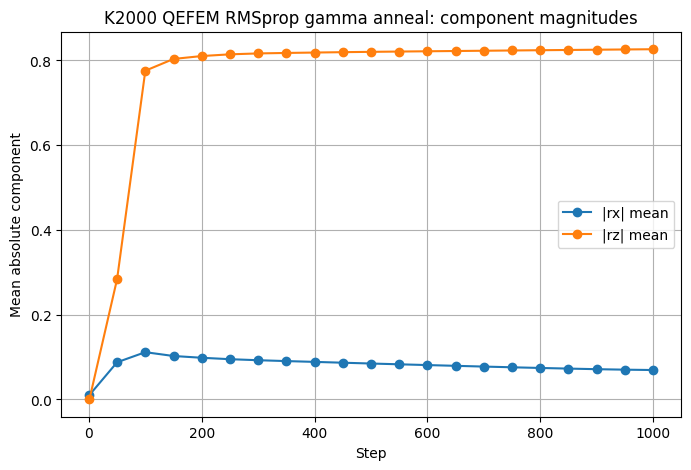

In [92]:
# ----------------------------
# Plot: rx/rz magnitudes
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_rms_df["step"],
    history_rms_df["rx_abs_mean"],
    marker="o",
    label="|rx| mean",
)
plt.plot(
    history_rms_df["step"],
    history_rms_df["rz_abs_mean"],
    marker="o",
    label="|rz| mean",
)
plt.xlabel("Step")
plt.ylabel("Mean absolute component")
plt.title("K2000 QEFEM RMSprop gamma anneal: component magnitudes")
plt.legend()
plt.grid(True)
plt.show()




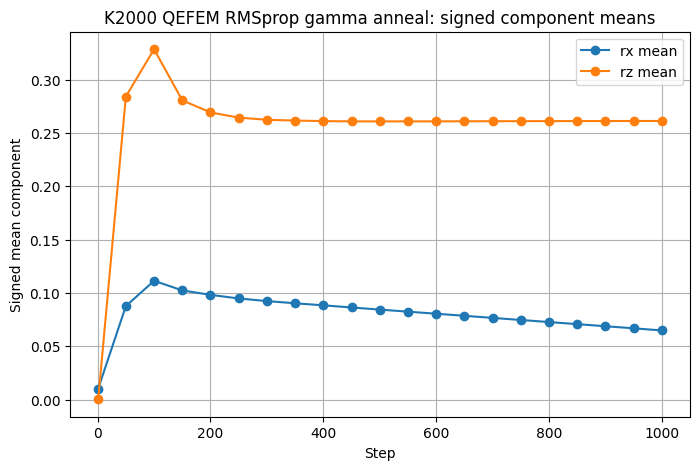

In [93]:
# ----------------------------
# Plot: signed rx/rz means
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_rms_df["step"],
    history_rms_df["rx_mean"],
    marker="o",
    label="rx mean",
)
plt.plot(
    history_rms_df["step"],
    history_rms_df["rz_mean"],
    marker="o",
    label="rz mean",
)
plt.xlabel("Step")
plt.ylabel("Signed mean component")
plt.title("K2000 QEFEM RMSprop gamma anneal: signed component means")
plt.legend()
plt.grid(True)
plt.show()




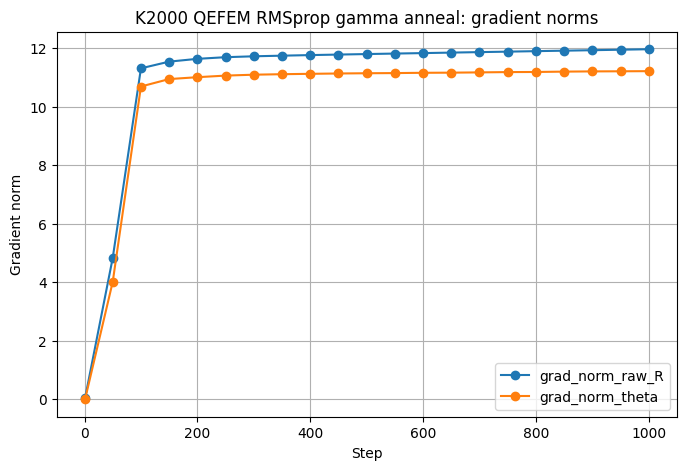

In [94]:
# ----------------------------
# Plot: gradient norms
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    history_rms_df["step"],
    history_rms_df["grad_norm_raw_R"],
    marker="o",
    label="grad_norm_raw_R",
)
plt.plot(
    history_rms_df["step"],
    history_rms_df["grad_norm_theta"],
    marker="o",
    label="grad_norm_theta",
)
plt.xlabel("Step")
plt.ylabel("Gradient norm")
plt.title("K2000 QEFEM RMSprop gamma anneal: gradient norms")
plt.legend()
plt.grid(True)
plt.show()




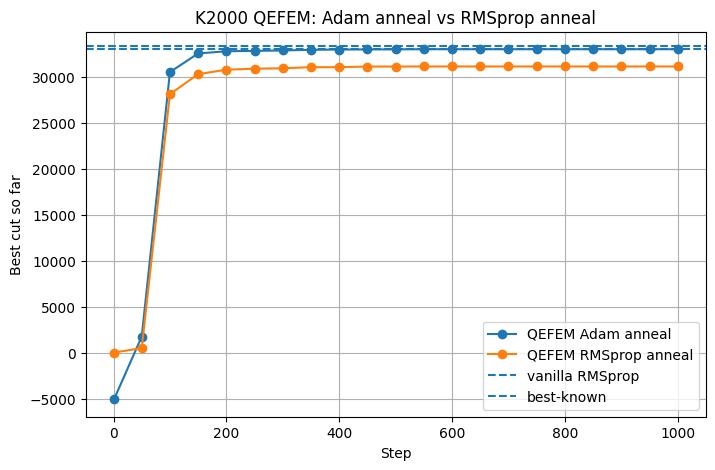

In [95]:
# ----------------------------
# Direct comparison: Adam anneal vs RMSprop anneal
# ----------------------------
if "history_anneal_df" in globals():
    plt.figure(figsize=(8, 5))
    plt.plot(
        history_anneal_df["step"],
        history_anneal_df["best_cut_so_far"],
        marker="o",
        label="QEFEM Adam anneal",
    )
    plt.plot(
        history_rms_df["step"],
        history_rms_df["best_cut_so_far"],
        marker="o",
        label="QEFEM RMSprop anneal",
    )
    plt.axhline(VANILLA_RMSPROP_CUT, linestyle="--", label="vanilla RMSprop")
    plt.axhline(K2000_BEST_KNOWN, linestyle="--", label="best-known")
    plt.xlabel("Step")
    plt.ylabel("Best cut so far")
    plt.title("K2000 QEFEM: Adam anneal vs RMSprop anneal")
    plt.legend()
    plt.grid(True)
    plt.show()




In [96]:
# ----------------------------
# Final interpretation
# ----------------------------
print("\n" + "=" * 80)
print("K2000 RMSprop GAMMA-ANNEAL VERDICT")
print("=" * 80)

print(f"QEFEM RMSprop anneal cut : {best_cut_rms:.0f}")
if "best_cut_anneal" in globals():
    print(f"QEFEM Adam anneal cut    : {best_cut_anneal:.0f}")
if "best_cut_zero" in globals():
    print(f"QEFEM gamma=0 cut        : {best_cut_zero:.0f}")

print(f"Vanilla Adam cut         : {VANILLA_ADAM_CUT:.0f}")
print(f"Vanilla RMSprop cut      : {VANILLA_RMSPROP_CUT:.0f}")
print(f"Best-known cut           : {K2000_BEST_KNOWN}")

print()
print(f"Delta vs vanilla Adam    : {best_cut_rms - VANILLA_ADAM_CUT:.0f}")
print(f"Delta vs vanilla RMSprop : {best_cut_rms - VANILLA_RMSPROP_CUT:.0f}")

if "best_cut_anneal" in globals():
    print(f"Delta vs Adam anneal     : {best_cut_rms - best_cut_anneal:.0f}")

if "best_cut_zero" in globals():
    print(f"Delta vs gamma=0 Adam    : {best_cut_rms - best_cut_zero:.0f}")

print()
print(f"QEFEM RMSprop accuracy   : {accuracy_rms:.4f}%")
print(f"Vanilla Adam accuracy    : {VANILLA_ADAM_ACCURACY:.4f}%")
print(f"Vanilla RMS accuracy     : {VANILLA_RMSPROP_ACCURACY:.4f}%")




K2000 RMSprop GAMMA-ANNEAL VERDICT
QEFEM RMSprop anneal cut : 31106
QEFEM Adam anneal cut    : 32981
QEFEM gamma=0 cut        : 30657
Vanilla Adam cut         : 29906
Vanilla RMSprop cut      : 32954
Best-known cut           : 33337

Delta vs vanilla Adam    : 1200
Delta vs vanilla RMSprop : -1848
Delta vs Adam anneal     : -1875
Delta vs gamma=0 Adam    : 449

QEFEM RMSprop accuracy   : 93.3077%
Vanilla Adam accuracy    : 89.7081%
Vanilla RMS accuracy     : 98.8511%


In [97]:
if "accuracy_anneal" in globals():
    print(f"QEFEM Adam accuracy      : {accuracy_anneal:.4f}%")

if "accuracy_zero" in globals():
    print(f"QEFEM gamma=0 accuracy   : {accuracy_zero:.4f}%")

print()

if best_cut_rms >= VANILLA_RMSPROP_CUT:
    print("Verdict: QEFEM RMSprop anneal beats or matches vanilla RMSprop. Strong-baseline pass.")
else:
    print("Verdict: QEFEM RMSprop anneal is below vanilla RMSprop. Strong baseline not beaten yet.")

if "best_cut_anneal" in globals():
    if best_cut_rms >= best_cut_anneal:
        print("Optimizer check: RMSprop improves over QEFEM Adam anneal.")
    else:
        print("Optimizer check: RMSprop underperforms QEFEM Adam anneal. Annoying, but useful.")

if "best_cut_zero" in globals():
    if best_cut_rms >= best_cut_zero:
        print("Driver/optimizer check: RMSprop anneal improves over gamma=0 Adam.")
    else:
        print("Driver/optimizer check: RMSprop anneal does not improve over gamma=0 Adam. Suspicious.")

print("=" * 80)

QEFEM Adam accuracy      : 98.9321%
QEFEM gamma=0 accuracy   : 91.9609%

Verdict: QEFEM RMSprop anneal is below vanilla RMSprop. Strong baseline not beaten yet.
Optimizer check: RMSprop underperforms QEFEM Adam anneal. Annoying, but useful.
Driver/optimizer check: RMSprop anneal improves over gamma=0 Adam.


### Final comparative diagnostics

In [98]:
master_rows = []

master_rows.append(
    {
        "rank_source": "baseline",
        "method": "vanilla_Adam",
        "optimizer": "Adam",
        "gamma_schedule": "none",
        "cut": VANILLA_ADAM_CUT,
        "best_known": K2000_BEST_KNOWN,
        "gap": VANILLA_ADAM_GAP,
        "accuracy_percent": VANILLA_ADAM_ACCURACY,
        "runtime_sec": VANILLA_ADAM_RUNTIME,
        "best_step": None,
        "best_replica": None,
        "replicas": REPLICAS,
        "n_steps": N_STEPS,
    }
)

master_rows.append(
    {
        "rank_source": "baseline",
        "method": "vanilla_RMSprop",
        "optimizer": "RMSprop",
        "gamma_schedule": "none",
        "cut": VANILLA_RMSPROP_CUT,
        "best_known": K2000_BEST_KNOWN,
        "gap": VANILLA_RMSPROP_GAP,
        "accuracy_percent": VANILLA_RMSPROP_ACCURACY,
        "runtime_sec": VANILLA_RMSPROP_RUNTIME,
        "best_step": None,
        "best_replica": None,
        "replicas": REPLICAS,
        "n_steps": N_STEPS,
    }
)

if "best_cut_zero" in globals():
    master_rows.append(
        {
            "rank_source": "qefem",
            "method": "QEFEM_gamma0_Adam",
            "optimizer": "Adam",
            "gamma_schedule": "0 fixed",
            "cut": best_cut_zero,
            "best_known": K2000_BEST_KNOWN,
            "gap": gap_zero,
            "accuracy_percent": accuracy_zero,
            "runtime_sec": runtime_zero,
            "best_step": best_step_zero,
            "best_replica": best_replica_zero,
            "replicas": REPLICAS,
            "n_steps": N_STEPS,
        }
    )

if "best_cut_anneal" in globals():
    master_rows.append(
        {
            "rank_source": "qefem",
            "method": "QEFEM_Adam_gamma_anneal",
            "optimizer": "Adam",
            "gamma_schedule": f"{GAMMA_MAX} -> {GAMMA_MIN}",
            "cut": best_cut_anneal,
            "best_known": K2000_BEST_KNOWN,
            "gap": gap_anneal,
            "accuracy_percent": accuracy_anneal,
            "runtime_sec": runtime_anneal,
            "best_step": best_step_anneal,
            "best_replica": best_replica_anneal,
            "replicas": REPLICAS,
            "n_steps": N_STEPS,
        }
    )

if "best_cut_rms" in globals():
    master_rows.append(
        {
            "rank_source": "qefem",
            "method": "QEFEM_RMSprop_gamma_anneal",
            "optimizer": "RMSprop",
            "gamma_schedule": f"{GAMMA_MAX} -> {GAMMA_MIN}",
            "cut": best_cut_rms,
            "best_known": K2000_BEST_KNOWN,
            "gap": gap_rms,
            "accuracy_percent": accuracy_rms,
            "runtime_sec": runtime_rms,
            "best_step": best_step_rms,
            "best_replica": best_replica_rms,
            "replicas": REPLICAS,
            "n_steps": N_STEPS,
        }
    )


# ----------------------------
# Make dataframe
# ----------------------------
k2000_master_comparison_df = pd.DataFrame(master_rows)

k2000_master_comparison_df["delta_cut_vs_vanilla_adam"] = (
    k2000_master_comparison_df["cut"] - VANILLA_ADAM_CUT
)

k2000_master_comparison_df["delta_accuracy_vs_vanilla_adam"] = (
    k2000_master_comparison_df["accuracy_percent"] - VANILLA_ADAM_ACCURACY
)

k2000_master_comparison_df["delta_cut_vs_vanilla_rmsprop"] = (
    k2000_master_comparison_df["cut"] - VANILLA_RMSPROP_CUT
)

k2000_master_comparison_df["delta_accuracy_vs_vanilla_rmsprop"] = (
    k2000_master_comparison_df["accuracy_percent"] - VANILLA_RMSPROP_ACCURACY
)

k2000_master_comparison_df = k2000_master_comparison_df.sort_values(
    by="cut",
    ascending=False,
).reset_index(drop=True)

k2000_master_comparison_df.insert(
    0,
    "rank",
    np.arange(1, len(k2000_master_comparison_df) + 1),
)


# ----------------------------
# Save master comparison
# ----------------------------
master_comparison_path = OUTPUT_DIR / "K2000_qefem_v1_master_comparison.csv"
k2000_master_comparison_df.to_csv(master_comparison_path, index=False)


# ----------------------------
# Display table
# ----------------------------
print("=" * 80)
print("K2000 QEFEM v1 MASTER COMPARISON")
print("=" * 80)

display(k2000_master_comparison_df)

print("\nSaved master comparison to:")
print(master_comparison_path.resolve())




K2000 QEFEM v1 MASTER COMPARISON


,rank,rank_source,method,optimizer,gamma_schedule,cut,best_known,gap,accuracy_percent,runtime_sec,best_step,best_replica,replicas,n_steps,delta_cut_vs_vanilla_adam,delta_accuracy_vs_vanilla_adam,delta_cut_vs_vanilla_rmsprop,delta_accuracy_vs_vanilla_rmsprop
0,1,qefem,QEFEM_Adam_gamma_anneal,Adam,1.0 -> 0.0,32981.0,33337,356.0,98.932117,21.430938,600.0,47.0,128,1000,3075.0,9.223985,27.0,0.080991
1,2,baseline,vanilla_RMSprop,RMSprop,none,32954.0,33337,383.0,98.851126,4.064090,NaN,NaN,128,1000,3048.0,9.142994,0.0,0.000000
2,3,qefem,QEFEM_RMSprop_gamma_anneal,RMSprop,1.0 -> 0.0,31106.0,33337,2231.0,93.307736,8.185935,550.0,52.0,128,1000,1200.0,3.599604,-1848.0,-5.543390
3,4,qefem,QEFEM_gamma0_Adam,Adam,0 fixed,30657.0,33337,2680.0,91.960884,14.497133,1000.0,108.0,128,1000,751.0,2.252752,-2297.0,-6.890242
4,5,baseline,vanilla_Adam,Adam,none,29906.0,33337,3431.0,89.708132,4.196436,NaN,NaN,128,1000,0.0,0.000000,-3048.0,-9.142994



Saved master comparison to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_qefem_v1_master_comparison.csv


In [99]:
# ----------------------------
# Best method summary
# ----------------------------
best_row = k2000_master_comparison_df.iloc[0]

print("\n" + "=" * 80)
print("BEST METHOD")
print("=" * 80)

print("Method:", best_row["method"])
print("Cut:", float(best_row["cut"]))
print("Best-known:", int(best_row["best_known"]))
print("Gap:", float(best_row["gap"]))
print("Accuracy %:", float(best_row["accuracy_percent"]))
print("Runtime sec:", float(best_row["runtime_sec"]))

print("\nDelta vs vanilla Adam:")
print("Cut delta:", float(best_row["delta_cut_vs_vanilla_adam"]))
print("Accuracy delta:", float(best_row["delta_accuracy_vs_vanilla_adam"]))

print("\nDelta vs vanilla RMSprop:")
print("Cut delta:", float(best_row["delta_cut_vs_vanilla_rmsprop"]))
print("Accuracy delta:", float(best_row["delta_accuracy_vs_vanilla_rmsprop"]))





BEST METHOD
Method: QEFEM_Adam_gamma_anneal
Cut: 32981.0
Best-known: 33337
Gap: 356.0
Accuracy %: 98.93211746707863
Runtime sec: 21.430938243865967

Delta vs vanilla Adam:
Cut delta: 3075.0
Accuracy delta: 9.223985361610232

Delta vs vanilla RMSprop:
Cut delta: 27.0
Accuracy delta: 0.08099109097999246


In [100]:
# ----------------------------
# Verdict flags
# ----------------------------
best_qefem_df = k2000_master_comparison_df[
    k2000_master_comparison_df["rank_source"] == "qefem"
].copy()

if len(best_qefem_df) > 0:
    best_qefem_row = best_qefem_df.iloc[0]

    print("\n" + "=" * 80)
    print("BEST QEFEM METHOD")
    print("=" * 80)

    print("Method:", best_qefem_row["method"])
    print("Cut:", float(best_qefem_row["cut"]))
    print("Gap:", float(best_qefem_row["gap"]))
    print("Accuracy %:", float(best_qefem_row["accuracy_percent"]))

    qefem_beats_vanilla_adam = bool(best_qefem_row["cut"] >= VANILLA_ADAM_CUT)
    qefem_beats_vanilla_rmsprop = bool(best_qefem_row["cut"] >= VANILLA_RMSPROP_CUT)

    print("\nQEFEM beats vanilla Adam?", qefem_beats_vanilla_adam)
    print("QEFEM beats vanilla RMSprop?", qefem_beats_vanilla_rmsprop)

    if qefem_beats_vanilla_rmsprop:
        print("\nVerdict: strong-baseline pass. QEFEM beat or matched vanilla RMSprop.")
    elif qefem_beats_vanilla_adam:
        print("\nVerdict: partial pass. QEFEM beat vanilla Adam but not vanilla RMSprop.")
    else:
        print("\nVerdict: not yet. QEFEM did not beat either vanilla baseline in this run.")
else:
    print("\nNo QEFEM runs found in globals. Run Cells 12, 15, or 18 first.")





BEST QEFEM METHOD
Method: QEFEM_Adam_gamma_anneal
Cut: 32981.0
Gap: 356.0
Accuracy %: 98.93211746707863

QEFEM beats vanilla Adam? True
QEFEM beats vanilla RMSprop? True

Verdict: strong-baseline pass. QEFEM beat or matched vanilla RMSprop.


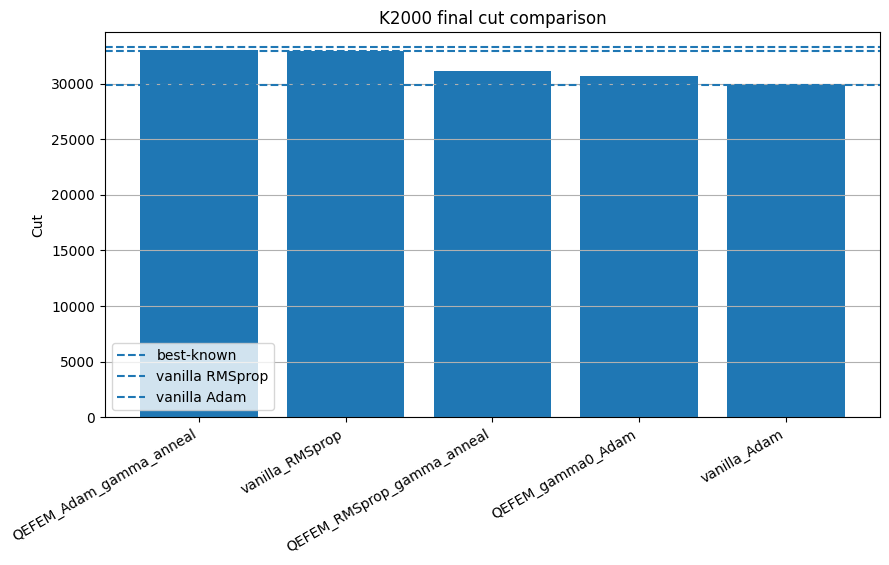

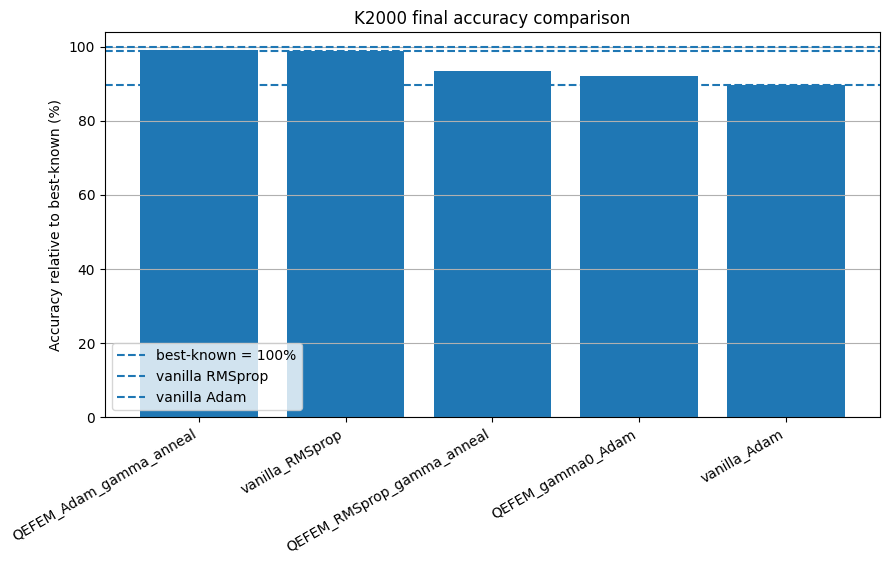

In [101]:
# ----------------------------
# Plot: final cuts
# ----------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    k2000_master_comparison_df["method"],
    k2000_master_comparison_df["cut"],
)
plt.axhline(K2000_BEST_KNOWN, linestyle="--", label="best-known")
plt.axhline(VANILLA_RMSPROP_CUT, linestyle="--", label="vanilla RMSprop")
plt.axhline(VANILLA_ADAM_CUT, linestyle="--", label="vanilla Adam")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Cut")
plt.title("K2000 final cut comparison")
plt.legend()
plt.grid(True, axis="y")
plt.show()


# ----------------------------
# Plot: final accuracy
# ----------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    k2000_master_comparison_df["method"],
    k2000_master_comparison_df["accuracy_percent"],
)
plt.axhline(100.0, linestyle="--", label="best-known = 100%")
plt.axhline(VANILLA_RMSPROP_ACCURACY, linestyle="--", label="vanilla RMSprop")
plt.axhline(VANILLA_ADAM_ACCURACY, linestyle="--", label="vanilla Adam")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy relative to best-known (%)")
plt.title("K2000 final accuracy comparison")
plt.legend()
plt.grid(True, axis="y")
plt.show()


# ----------------------------
# Assertions
# ----------------------------
assert len(k2000_master_comparison_df) >= 2, (
    "Master comparison should include at least the two vanilla baselines."
)

assert k2000_master_comparison_df["cut"].isna().sum() == 0, (
    "Cut column contains NaNs. Humanity has disappointed us again."
)

assert k2000_master_comparison_df["accuracy_percent"].isna().sum() == 0, (
    "Accuracy column contains NaNs."
)

In [102]:
assert "k2000_master_comparison_df" in globals(), (
    "Run Cell 20 first. k2000_master_comparison_df does not exist."
)

assert len(k2000_master_comparison_df) > 0, (
    "Master comparison table is empty."
)


# ----------------------------
# Best overall and best QEFEM rows
# ----------------------------
best_overall_row = k2000_master_comparison_df.iloc[0]

qefem_only_df = k2000_master_comparison_df[
    k2000_master_comparison_df["rank_source"] == "qefem"
].copy()

if len(qefem_only_df) > 0:
    best_qefem_row = qefem_only_df.iloc[0]
else:
    best_qefem_row = None


# ----------------------------
# Build report lines
# ----------------------------
report_lines = []

report_lines.append("=" * 80)
report_lines.append("K2000 QEFEM v1 FINAL REPORT")
report_lines.append("=" * 80)
report_lines.append("")

report_lines.append("INSTANCE")
report_lines.append("-" * 80)
report_lines.append(f"Instance                 : {K2000_INSTANCE}")
report_lines.append(f"N                        : {N}")
report_lines.append(f"M                        : {M}")
report_lines.append(f"Best-known cut           : {K2000_BEST_KNOWN}")
report_lines.append(f"W_sum                    : {W_sum}")
report_lines.append(f"Positive edges           : {positive_edges}")
report_lines.append(f"Negative edges           : {negative_edges}")
report_lines.append("")

report_lines.append("SCHEDULES AND SETTINGS")
report_lines.append("-" * 80)
report_lines.append(f"Replicas                 : {REPLICAS}")
report_lines.append(f"Steps                    : {N_STEPS}")
report_lines.append(f"Seed                     : {SEED}")
report_lines.append(f"Tmax                     : {K2000_TMAX}")
report_lines.append(f"Tmin                     : {K2000_TMIN}")
report_lines.append(f"Beta min                 : {float(beta_schedule[0].detach().cpu())}")
report_lines.append(f"Beta max                 : {float(beta_schedule[-1].detach().cpu())}")
report_lines.append(f"Gamma anneal             : {GAMMA_MAX} -> {GAMMA_MIN}")
report_lines.append(f"R init                   : {R_INIT}")
report_lines.append(f"Theta center             : {THETA_CENTER}")
report_lines.append(f"Theta noise              : {THETA_NOISE}")
report_lines.append("")

report_lines.append("OBJECTIVE")
report_lines.append("-" * 80)
report_lines.append("QEFEM minimizes:")
report_lines.append("F = -E[C] - gamma * sum_i rx_i - S_Q / beta")
report_lines.append("")
report_lines.append("Expected MaxCut:")
report_lines.append("E[C] = 1/4 * (W.sum() - rz^T W rz)")
report_lines.append("")
report_lines.append("Hard readout:")
report_lines.append("s_i = sign(rz_i)")
report_lines.append("C(s) = 1/4 * (W.sum() - s^T W s)")
report_lines.append("")
report_lines.append("Quantum entropy:")
report_lines.append("lambda_plus  = (1 + R_i) / 2")
report_lines.append("lambda_minus = (1 - R_i) / 2")
report_lines.append("S_Q = -sum_i [lambda_plus log(lambda_plus) + lambda_minus log(lambda_minus)]")
report_lines.append("")

report_lines.append("VANILLA BASELINES")
report_lines.append("-" * 80)
report_lines.append(f"Vanilla Adam cut         : {VANILLA_ADAM_CUT:.0f}")
report_lines.append(f"Vanilla Adam gap         : {VANILLA_ADAM_GAP:.0f}")
report_lines.append(f"Vanilla Adam accuracy    : {VANILLA_ADAM_ACCURACY:.6f}%")
report_lines.append(f"Vanilla Adam runtime     : {VANILLA_ADAM_RUNTIME:.6f} sec")
report_lines.append("")
report_lines.append(f"Vanilla RMSprop cut      : {VANILLA_RMSPROP_CUT:.0f}")
report_lines.append(f"Vanilla RMSprop gap      : {VANILLA_RMSPROP_GAP:.0f}")
report_lines.append(f"Vanilla RMSprop accuracy : {VANILLA_RMSPROP_ACCURACY:.6f}%")
report_lines.append(f"Vanilla RMSprop runtime  : {VANILLA_RMSPROP_RUNTIME:.6f} sec")
report_lines.append("")

report_lines.append("ALL RESULTS, SORTED BY CUT")
report_lines.append("-" * 80)

for _, row in k2000_master_comparison_df.iterrows():
    report_lines.append(
        f"Rank {int(row['rank'])}: "
        f"{row['method']} | "
        f"cut={row['cut']:.0f} | "
        f"gap={row['gap']:.0f} | "
        f"accuracy={row['accuracy_percent']:.6f}% | "
        f"runtime={row['runtime_sec']:.6f}s | "
        f"delta_vs_vanilla_RMSprop={row['delta_cut_vs_vanilla_rmsprop']:.0f}"
    )

report_lines.append("")

report_lines.append("BEST OVERALL METHOD")
report_lines.append("-" * 80)
report_lines.append(f"Method                   : {best_overall_row['method']}")
report_lines.append(f"Cut                      : {best_overall_row['cut']:.0f}")
report_lines.append(f"Gap                      : {best_overall_row['gap']:.0f}")
report_lines.append(f"Accuracy                 : {best_overall_row['accuracy_percent']:.6f}%")
report_lines.append(f"Runtime                  : {best_overall_row['runtime_sec']:.6f} sec")
report_lines.append(f"Delta vs vanilla Adam    : {best_overall_row['delta_cut_vs_vanilla_adam']:.0f}")
report_lines.append(f"Delta vs vanilla RMSprop : {best_overall_row['delta_cut_vs_vanilla_rmsprop']:.0f}")
report_lines.append("")

if best_qefem_row is not None:
    report_lines.append("BEST QEFEM METHOD")
    report_lines.append("-" * 80)
    report_lines.append(f"Method                   : {best_qefem_row['method']}")
    report_lines.append(f"Optimizer                : {best_qefem_row['optimizer']}")
    report_lines.append(f"Gamma schedule           : {best_qefem_row['gamma_schedule']}")
    report_lines.append(f"Cut                      : {best_qefem_row['cut']:.0f}")
    report_lines.append(f"Gap                      : {best_qefem_row['gap']:.0f}")
    report_lines.append(f"Accuracy                 : {best_qefem_row['accuracy_percent']:.6f}%")
    report_lines.append(f"Runtime                  : {best_qefem_row['runtime_sec']:.6f} sec")
    report_lines.append(f"Best step                : {best_qefem_row['best_step']}")
    report_lines.append(f"Best replica             : {best_qefem_row['best_replica']}")
    report_lines.append(f"Delta vs vanilla Adam    : {best_qefem_row['delta_cut_vs_vanilla_adam']:.0f}")
    report_lines.append(f"Delta vs vanilla RMSprop : {best_qefem_row['delta_cut_vs_vanilla_rmsprop']:.0f}")
    report_lines.append("")

    qefem_beats_adam = best_qefem_row["cut"] >= VANILLA_ADAM_CUT
    qefem_beats_rmsprop = best_qefem_row["cut"] >= VANILLA_RMSPROP_CUT

    report_lines.append("VERDICT")
    report_lines.append("-" * 80)
    report_lines.append(f"QEFEM beats vanilla Adam?    : {qefem_beats_adam}")
    report_lines.append(f"QEFEM beats vanilla RMSprop? : {qefem_beats_rmsprop}")

    if qefem_beats_rmsprop:
        report_lines.append("Verdict: Strong-baseline pass. QEFEM beat or matched vanilla RMSprop.")
    elif qefem_beats_adam:
        report_lines.append("Verdict: Partial pass. QEFEM beat vanilla Adam but not vanilla RMSprop.")
    else:
        report_lines.append("Verdict: Not yet. QEFEM did not beat the stored vanilla baselines in this run.")

    report_lines.append("")
else:
    report_lines.append("No QEFEM runs were found in the master table.")
    report_lines.append("")

report_lines.append("FILES WRITTEN")
report_lines.append("-" * 80)
report_lines.append(f"Master comparison CSV    : {master_comparison_path.resolve()}")

if "history_zero_path" in globals():
    report_lines.append(f"Gamma=0 history CSV      : {history_zero_path.resolve()}")

if "history_anneal_path" in globals():
    report_lines.append(f"Adam anneal history CSV  : {history_anneal_path.resolve()}")

if "history_rms_path" in globals():
    report_lines.append(f"RMS anneal history CSV   : {history_rms_path.resolve()}")

report_lines.append("")
report_lines.append("=" * 80)
report_lines.append("END OF REPORT")
report_lines.append("=" * 80)


# ----------------------------
# Write report
# ----------------------------
final_report_text = "\n".join(report_lines)

final_report_path = OUTPUT_DIR / "K2000_qefem_v1_final_report.txt"

with open(final_report_path, "w") as f:
    f.write(final_report_text)


# ----------------------------
# Print report
# ----------------------------
print(final_report_text)

print("\nSaved final report to:")
print(final_report_path.resolve())

print("\nCell 22 complete: final TXT report written.")

K2000 QEFEM v1 FINAL REPORT

INSTANCE
--------------------------------------------------------------------------------
Instance                 : K2000
N                        : 2000
M                        : 1999000
Best-known cut           : 33337
W_sum                    : -2080.0
Positive edges           : 998980
Negative edges           : 1000020

SCHEDULES AND SETTINGS
--------------------------------------------------------------------------------
Replicas                 : 128
Steps                    : 1000
Seed                     : 4
Tmax                     : 1.16
Tmin                     : 6e-05
Beta min                 : 0.8620690107345581
Beta max                 : 16666.66796875
Gamma anneal             : 1.0 -> 0.0
R init                   : 0.01
Theta center             : 1.5707963267948966
Theta noise              : 0.001

OBJECTIVE
--------------------------------------------------------------------------------
QEFEM minimizes:
F = -E[C] - gamma * sum_i rx_i - S_Q

# Paper scale

In [103]:
# ============================================================
# Cell 23: Paper-scale K2000 QEFEM Adam gamma anneal
# ============================================================

# Paper-scale comparison:
#
#     replicas = 1000
#     steps    = 1000
#
# This follows the scale of Sir's K2000 FEM benchmark.
#
# QEFEM settings:
#     optimizer = Adam
#     lr = ADAM_LR
#     beta schedule = same K2000 temperature-linear schedule
#     gamma = 1.0 -> 0.0
#
# This is the fairer "can QEFEM approach the paper-scale FEM result?" test.


# ----------------------------
# Paper-scale settings
# ----------------------------
PAPER_REPLICAS = 1000
PAPER_N_STEPS = 1000
PAPER_LOG_EVERY = 50
PAPER_SEED = SEED

print("=" * 80)
print("PAPER-SCALE K2000 QEFEM ADAM GAMMA ANNEAL")
print("=" * 80)
print("PAPER_REPLICAS:", PAPER_REPLICAS)
print("PAPER_N_STEPS :", PAPER_N_STEPS)
print("Adam lr       :", ADAM_LR)
print("Gamma         :", GAMMA_MAX, "->", GAMMA_MIN)
print("Best-known    :", K2000_BEST_KNOWN)
print("Vanilla RMS   :", VANILLA_RMSPROP_CUT)

if "best_cut_anneal" in globals():
    print("Previous QEFEM R=128 Adam anneal:", best_cut_anneal)

print("=" * 80)


# ----------------------------
# Rebuild paper-scale schedules
# ----------------------------
paper_T_schedule = torch.linspace(
    K2000_TMAX,
    K2000_TMIN,
    PAPER_N_STEPS,
    device=W.device,
    dtype=W.dtype,
)

paper_beta_schedule = 1.0 / paper_T_schedule

paper_gamma_schedule = torch.linspace(
    GAMMA_MAX,
    GAMMA_MIN,
    PAPER_N_STEPS,
    device=W.device,
    dtype=W.dtype,
)


# ----------------------------
# Fresh initialization
# ----------------------------
torch.manual_seed(PAPER_SEED)

paper_raw_R_init_value = raw_R_from_init_value(
    R_INIT,
    device=W.device,
    dtype=W.dtype,
)

paper_raw_R = paper_raw_R_init_value + 1e-3 * torch.randn(
    PAPER_REPLICAS,
    N,
    device=W.device,
    dtype=W.dtype,
)

paper_theta = THETA_CENTER + THETA_NOISE * torch.randn(
    PAPER_REPLICAS,
    N,
    device=W.device,
    dtype=W.dtype,
)

paper_raw_R.requires_grad_(True)
paper_theta.requires_grad_(True)


# ----------------------------
# Optimizer
# ----------------------------
paper_optimizer = torch.optim.Adam(
    [paper_raw_R, paper_theta],
    lr=ADAM_LR,
)


# ----------------------------
# Initial diagnostics
# ----------------------------
with torch.no_grad():
    paper_R_init, paper_rx_init, paper_rz_init = bloch_from_raw(
        paper_raw_R,
        paper_theta,
    )

    paper_initial_spins = torch.where(
        paper_rz_init >= 0,
        torch.ones_like(paper_rz_init),
        -torch.ones_like(paper_rz_init),
    )

    paper_initial_hard_cuts = discrete_cut(
        W,
        paper_initial_spins,
    )

print("\nInitial diagnostics:")
print("R mean:", float(paper_R_init.mean().detach().cpu()))
print("|rx| mean:", float(paper_rx_init.abs().mean().detach().cpu()))
print("|rz| mean:", float(paper_rz_init.abs().mean().detach().cpu()))
print("initial hard cut max:", float(paper_initial_hard_cuts.max().detach().cpu()))
print("initial hard cut mean:", float(paper_initial_hard_cuts.mean().detach().cpu()))


# ----------------------------
# Main run containers
# ----------------------------
history_paper_adam = []

best_cut_paper_adam = -float("inf")
best_step_paper_adam = None
best_replica_paper_adam = None
best_spins_paper_adam = None

start_time_paper_adam = time.time()

if W.device.type == "mps":
    torch.mps.synchronize()


# ============================================================
# Optimization loop
# ============================================================

for step in range(PAPER_N_STEPS):
    beta_t = paper_beta_schedule[step]
    gamma_t = paper_gamma_schedule[step]

    paper_optimizer.zero_grad()

    F_paper, aux_paper = qefem_free_energy_maxcut(
        W=W,
        raw_R=paper_raw_R,
        theta=paper_theta,
        beta=beta_t,
        gamma=gamma_t,
    )

    if not torch.isfinite(F_paper).all():
        raise FloatingPointError(
            f"Non-finite F_paper at step {step}. "
            "Paper-scale run has angered the gods."
        )

    loss_paper = F_paper.mean()

    if not torch.isfinite(loss_paper):
        raise FloatingPointError(
            f"Non-finite loss_paper at step {step}."
        )

    loss_paper.backward()

    if paper_raw_R.grad is None:
        raise RuntimeError(f"paper_raw_R.grad is None at step {step}")

    if paper_theta.grad is None:
        raise RuntimeError(f"paper_theta.grad is None at step {step}")

    if not torch.isfinite(paper_raw_R.grad).all():
        raise FloatingPointError(f"Non-finite paper_raw_R.grad at step {step}")

    if not torch.isfinite(paper_theta.grad).all():
        raise FloatingPointError(f"Non-finite paper_theta.grad at step {step}")

    grad_norm_raw_R = paper_raw_R.grad.detach().norm().item()
    grad_norm_theta = paper_theta.grad.detach().norm().item()

    paper_optimizer.step()

    if not torch.isfinite(paper_raw_R).all():
        raise FloatingPointError(f"Non-finite paper_raw_R after step {step}")

    if not torch.isfinite(paper_theta).all():
        raise FloatingPointError(f"Non-finite paper_theta after step {step}")


    # ----------------------------
    # Logging + hard readout
    # ----------------------------
    should_log = (
        step == 0
        or step == PAPER_N_STEPS - 1
        or (step + 1) % PAPER_LOG_EVERY == 0
    )

    if should_log:
        if W.device.type == "mps":
            torch.mps.synchronize()

        elapsed = time.time() - start_time_paper_adam

        with torch.no_grad():
            R_now, rx_now, rz_now = bloch_from_raw(
                paper_raw_R,
                paper_theta,
            )

            spins_now = torch.where(
                rz_now >= 0,
                torch.ones_like(rz_now),
                -torch.ones_like(rz_now),
            )

            hard_cuts_now = discrete_cut(
                W,
                spins_now,
            )

            step_best_cut_tensor, step_best_replica_tensor = torch.max(
                hard_cuts_now,
                dim=0,
            )

            step_best_cut = float(step_best_cut_tensor.detach().cpu())
            step_best_replica = int(step_best_replica_tensor.detach().cpu())

            if step_best_cut > best_cut_paper_adam:
                best_cut_paper_adam = step_best_cut
                best_step_paper_adam = step + 1
                best_replica_paper_adam = step_best_replica
                best_spins_paper_adam = spins_now[step_best_replica].detach().cpu().clone()

            row = {
                "step": step + 1,
                "beta": float(beta_t.detach().cpu()),
                "gamma": float(gamma_t.detach().cpu()),

                "loss_mean": float(loss_paper.detach().cpu()),
                "free_energy_mean": float(F_paper.mean().detach().cpu()),
                "free_energy_min": float(F_paper.min().detach().cpu()),

                "expected_cut_mean": float(aux_paper["expected_cut"].mean().detach().cpu()),
                "expected_cut_max": float(aux_paper["expected_cut"].max().detach().cpu()),

                "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                "hard_cut_max": step_best_cut,
                "best_cut_so_far": best_cut_paper_adam,
                "gap_so_far": float(K2000_BEST_KNOWN - best_cut_paper_adam),
                "accuracy_so_far_percent": float(100.0 * best_cut_paper_adam / K2000_BEST_KNOWN),

                "entropy_mean": float(aux_paper["entropy"].mean().detach().cpu()),
                "driver_energy_mean": float(aux_paper["driver_energy"].mean().detach().cpu()),

                "R_mean": float(R_now.mean().detach().cpu()),
                "R_min": float(R_now.min().detach().cpu()),
                "R_max": float(R_now.max().detach().cpu()),

                "rx_mean": float(rx_now.mean().detach().cpu()),
                "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),

                "rz_mean": float(rz_now.mean().detach().cpu()),
                "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),

                "grad_norm_raw_R": grad_norm_raw_R,
                "grad_norm_theta": grad_norm_theta,

                "best_replica_current": step_best_replica,
                "best_replica_so_far": best_replica_paper_adam,

                "elapsed_sec": elapsed,
            }

            history_paper_adam.append(row)

            print(
                f"step {step + 1:5d}/{PAPER_N_STEPS} | "
                f"beta={row['beta']:10.4f} | "
                f"gamma={row['gamma']:7.4f} | "
                f"F={row['free_energy_mean']:12.4f} | "
                f"Ecut_max={row['expected_cut_max']:10.1f} | "
                f"Hcut_max={row['hard_cut_max']:10.1f} | "
                f"best={row['best_cut_so_far']:10.1f} | "
                f"acc={row['accuracy_so_far_percent']:8.4f}% | "
                f"S={row['entropy_mean']:9.2f} | "
                f"|rx|={row['rx_abs_mean']:.4f} | "
                f"|rz|={row['rz_abs_mean']:.4f} | "
                f"time={elapsed:8.2f}s"
            )


if W.device.type == "mps":
    torch.mps.synchronize()

runtime_paper_adam = time.time() - start_time_paper_adam

history_paper_adam_df = pd.DataFrame(history_paper_adam)

gap_paper_adam = K2000_BEST_KNOWN - best_cut_paper_adam
accuracy_paper_adam = 100.0 * best_cut_paper_adam / K2000_BEST_KNOWN


# ----------------------------
# Save outputs
# ----------------------------
history_paper_adam_path = OUTPUT_DIR / "K2000_qefem_paper_scale_adam_gamma_anneal_history.csv"
history_paper_adam_df.to_csv(history_paper_adam_path, index=False)

paper_adam_summary_df = pd.DataFrame(
    [
        {
            "instance": K2000_INSTANCE,
            "mode": "qefem_paper_scale_adam_gamma_anneal",
            "replicas": PAPER_REPLICAS,
            "n_steps": PAPER_N_STEPS,
            "seed": PAPER_SEED,
            "optimizer": "Adam",
            "lr": ADAM_LR,
            "gamma_max": GAMMA_MAX,
            "gamma_min": GAMMA_MIN,
            "best_cut": best_cut_paper_adam,
            "best_known": K2000_BEST_KNOWN,
            "gap": gap_paper_adam,
            "accuracy_percent": accuracy_paper_adam,
            "best_step": best_step_paper_adam,
            "best_replica": best_replica_paper_adam,
            "runtime_sec": runtime_paper_adam,
            "delta_cut_vs_vanilla_adam": best_cut_paper_adam - VANILLA_ADAM_CUT,
            "delta_cut_vs_vanilla_rmsprop": best_cut_paper_adam - VANILLA_RMSPROP_CUT,
            "delta_cut_vs_previous_qefem_r128_adam": (
                best_cut_paper_adam - best_cut_anneal
                if "best_cut_anneal" in globals()
                else None
            ),
            "delta_cut_vs_best_known": best_cut_paper_adam - K2000_BEST_KNOWN,
        }
    ]
)

paper_adam_summary_path = OUTPUT_DIR / "K2000_qefem_paper_scale_adam_gamma_anneal_summary.csv"
paper_adam_summary_df.to_csv(paper_adam_summary_path, index=False)

PAPER-SCALE K2000 QEFEM ADAM GAMMA ANNEAL
PAPER_REPLICAS: 1000
PAPER_N_STEPS : 1000
Adam lr       : 0.01
Gamma         : 1.0 -> 0.0
Best-known    : 33337
Vanilla RMS   : 32954.0
Previous QEFEM R=128 Adam anneal: 32981.0

Initial diagnostics:
R mean: 0.009999998845160007
|rx| mean: 0.009999994188547134
|rz| mean: 7.981861926964484e-06
initial hard cut max: 1681.0
initial hard cut mean: -576.4099731445312
step     1/1000 | beta=    0.8621 | gamma= 1.0000 | F=  -1107.9852 | Ecut_max=    -520.0 | Hcut_max=   -4417.0 | best=   -4417.0 | acc=-13.2495% | S=  1386.19 | |rx|=0.0101 | |rz|=0.0000 | time=    0.25s
step    50/1000 | beta=    0.9065 | gamma= 0.9510 | F=  -1040.5071 | Ecut_max=    -520.0 | Hcut_max=    5064.0 | best=    5064.0 | acc= 15.1903% | S=  1386.02 | |rx|=0.0168 | |rz|=0.0000 | time=    2.54s
step   100/1000 | beta=    0.9569 | gamma= 0.9009 | F=   -983.0379 | Ecut_max=    -519.7 | Hcut_max=   30756.0 | best=   30756.0 | acc= 92.2579% | S=  1385.36 | |rx|=0.0309 | |rz|=0.002

In [104]:
# ----------------------------
# Final print
# ----------------------------
print("\n" + "=" * 80)
print("PAPER-SCALE K2000 QEFEM ADAM GAMMA ANNEAL COMPLETE")
print("=" * 80)
print("Best cut:", best_cut_paper_adam)
print("Best-known:", K2000_BEST_KNOWN)
print("Gap:", gap_paper_adam)
print("Accuracy %:", accuracy_paper_adam)
print("Best step:", best_step_paper_adam)
print("Best replica:", best_replica_paper_adam)
print("Runtime seconds:", runtime_paper_adam)

print("\nBaselines:")
print("Vanilla Adam cut:", VANILLA_ADAM_CUT)
print("Vanilla RMSprop cut:", VANILLA_RMSPROP_CUT)

if "best_cut_anneal" in globals():
    print("Previous QEFEM R=128 Adam anneal cut:", best_cut_anneal)

print("\nDeltas:")
print("vs vanilla Adam:", best_cut_paper_adam - VANILLA_ADAM_CUT)
print("vs vanilla RMSprop:", best_cut_paper_adam - VANILLA_RMSPROP_CUT)

if "best_cut_anneal" in globals():
    print("vs previous QEFEM R=128 Adam:", best_cut_paper_adam - best_cut_anneal)

print("vs best-known:", best_cut_paper_adam - K2000_BEST_KNOWN)

print("\nSaved history to:")
print(history_paper_adam_path.resolve())

print("\nSaved summary to:")
print(paper_adam_summary_path.resolve())


PAPER-SCALE K2000 QEFEM ADAM GAMMA ANNEAL COMPLETE
Best cut: 33049.0
Best-known: 33337
Gap: 288.0
Accuracy %: 99.13609502954675
Best step: 750
Best replica: 338
Runtime seconds: 48.230639934539795

Baselines:
Vanilla Adam cut: 29906.0
Vanilla RMSprop cut: 32954.0
Previous QEFEM R=128 Adam anneal cut: 32981.0

Deltas:
vs vanilla Adam: 3143.0
vs vanilla RMSprop: 95.0
vs previous QEFEM R=128 Adam: 68.0
vs best-known: -288.0

Saved history to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_qefem_paper_scale_adam_gamma_anneal_history.csv

Saved summary to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/qefem_v1_k2000_outputs/K2000_qefem_paper_scale_adam_gamma_anneal_summary.csv


In [105]:
display(paper_adam_summary_df)

,instance,mode,replicas,n_steps,seed,optimizer,lr,gamma_max,gamma_min,best_cut,best_known,gap,accuracy_percent,best_step,best_replica,runtime_sec,delta_cut_vs_vanilla_adam,delta_cut_vs_vanilla_rmsprop,delta_cut_vs_previous_qefem_r128_adam,delta_cut_vs_best_known
0,K2000,qefem_paper_scale_adam_gamma_anneal,1000,1000,4,Adam,0.01,1.0,0.0,33049.0,33337,288.0,99.136095,750,338,48.23064,3143.0,95.0,68.0,-288.0
